In [ ]:
!pip install kaggle --quiet

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"petal2025","key":"c88a6e1381bcb3683557de000aaecce3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lainguyn123/student-performance-factors
!kaggle datasets download -d eldarsarajlic/college-enrollment-in-the-us-20032021
!kaggle datasets download -d raymondtoo/the-world-university-rankings-2016-2024
!kaggle datasets download -d thedevastator/higher-education-predictors-of-student-retention
!kaggle datasets download -d jeromeblanchet/drivendatas-boxplots-for-education-dataset

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
License(s): CC0-1.0
student-performance-factors.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/eldarsarajlic/college-enrollment-in-the-us-20032021
License(s): unknown
college-enrollment-in-the-us-20032021.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/raymondtoo/the-world-university-rankings-2016-2024
License(s): MIT
the-world-university-rankings-2016-2024.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
License(s): CC0-1.0
higher-education-predictors-of-student-retention.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com

In [ ]:
!unzip -q student-performance-factors.zip -d student_performance
!unzip -q college-enrollment-in-the-us-20032021.zip -d college_enrollment
!unzip -q the-world-university-rankings-2016-2024.zip -d university_rankings
!unzip -q higher-education-predictors-of-student-retention.zip -d retention
!unzip -q drivendatas-boxplots-for-education-dataset.zip -d education

In [ ]:
"""
GENERIC ACCURACY CALCULATOR
===========================
A universal function that calculates all accuracy metrics for all models
on any dataset with a target variable.

Features:
- Auto-detects task type (Regression vs Classification)
- Handles preprocessing automatically
- Works with any dataset structure
- Calculates all accuracy types
- Supports all 4 models: LogisticRegression, RandomForest, XGBoost, LightGBM
"""

import pandas as pd
import numpy as np
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error, classification_report
)
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')


def detect_task_type(y):
    """
    Automatically detect if the task is regression or classification.

    Args:
        y: Target variable (pandas Series or numpy array)

    Returns:
        str: 'Regression' or 'Classification'
    """
    # Check if target is string/object type - definitely classification
    if isinstance(y, pd.Series):
        if y.dtype == 'object' or y.dtype.name == 'category':
            return 'Classification'
        # Check if values are strings
        if y.astype(str).str.contains('[a-zA-Z]', regex=True).any():
            return 'Classification'

    # Convert to numeric if possible
    try:
        y_numeric = pd.to_numeric(y, errors='coerce')
        unique_values = y_numeric.dropna().nunique()
        total_values = len(y_numeric.dropna())

        # If most values couldn't be converted to numeric -> Classification
        if total_values < len(y) * 0.5:
            return 'Classification'

        # If mostly numeric and many unique values -> Regression
        if unique_values > 10 and (unique_values / total_values) > 0.1:
            return 'Regression'
        # If few unique values -> Classification
        elif unique_values <= 10:
            return 'Classification'
        else:
            # Check data type
            if y.dtype in ['int64', 'float64']:
                return 'Regression'
            else:
                return 'Classification'
    except:
        return 'Classification'


def detect_and_transform_wide_format(df, id_columns=None):
    """
    Detect and transform wide-format datasets (e.g., years as columns) to long format.
    Has special handling for enrollment-like datasets (Type column + year columns).

    Args:
        df: Input dataframe
        id_columns: List of columns to use as ID variables (if None, auto-detect)

    Returns:
        Transformed dataframe, or original if not wide format
        bool: Whether transformation was applied
    """
    # SPECIAL CASE: Enrollment-like dataset (Type column + year columns as digits)
    # Check if dataset matches enrollment structure: has 'Type' column and year columns
    has_type_col = 'Type' in df.columns
    year_cols = [col for col in df.columns if str(col).isdigit()]  # Any numeric string columns

    if has_type_col and len(year_cols) >= 3:
        # This is enrollment-like dataset - follow exact user code pattern
        print(f"  🔄 Detected enrollment-like dataset (Type column + year columns)")
        print(f"     Found 'Type' column and {len(year_cols)} year columns")

        # Follow exact user code: melt with Type as id_vars
        df_long = df.melt(
            id_vars=['Type'],
            value_vars=year_cols,
            var_name='Year',
            value_name='Enrollment'
        )

        # Drop missing values (exact user code)
        df_long = df_long.dropna(subset=['Enrollment'])
        df_long['Year'] = df_long['Year'].astype(int)
        df_long['Enrollment'] = pd.to_numeric(df_long['Enrollment'], errors='coerce')
        df_long = df_long.dropna(subset=['Enrollment'])

        print(f"     ✅ Transformed (enrollment pattern): {df.shape[0]} rows × {df.shape[1]} cols → "
              f"{df_long.shape[0]} rows × {df_long.shape[1]} cols")
        print(f"     ✅ Created columns: Type, Year, Enrollment")

        return df_long, True

    # GENERAL CASE: Other wide-format datasets
    # Detect year columns (numeric column names that look like years)
    year_cols_detected = [col for col in df.columns if str(col).isdigit() and 1900 <= int(col) <= 2100]

    # Also check for other numeric column names that might be time periods
    numeric_cols = [col for col in df.columns if str(col).replace('.', '').isdigit()]

    # If we have many numeric column names, likely wide format
    if len(year_cols_detected) >= 3 or (len(numeric_cols) >= 5 and len(numeric_cols) / len(df.columns) > 0.5):
        print(f"  🔄 Detected wide-format dataset (time periods as columns)")
        print(f"     Found {len(year_cols_detected)} year columns or {len(numeric_cols)} numeric columns")

        # Determine ID columns (non-numeric columns)
        if id_columns is None:
            # Auto-detect: use non-numeric columns as ID
            id_cols = [col for col in df.columns
                      if col not in year_cols_detected and col not in numeric_cols
                      and not str(col).replace('.', '').isdigit()]

            # If no ID columns found, use first column
            if not id_cols:
                id_cols = [df.columns[0]]
        else:
            id_cols = [col for col in id_columns if col in df.columns]

        # Use year columns if available, otherwise numeric columns
        value_cols = year_cols_detected if year_cols_detected else numeric_cols

        if value_cols:
            print(f"     Using ID columns: {id_cols}")
            print(f"     Melting {len(value_cols)} time period columns")

            # Melt the dataframe
            df_long = df.melt(
                id_vars=id_cols,
                value_vars=value_cols,
                var_name='Time_Period',
                value_name='Value'
            )

            # Convert time period to numeric
            df_long['Time_Period'] = pd.to_numeric(df_long['Time_Period'], errors='coerce')

            # Drop rows with missing values
            df_long = df_long.dropna(subset=['Value'])
            df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
            df_long = df_long.dropna(subset=['Value'])

            print(f"     ✅ Transformed: {df.shape[0]} rows × {df.shape[1]} cols → "
                  f"{df_long.shape[0]} rows × {df_long.shape[1]} cols")

            return df_long, True

    return df, False


def detect_text_columns(X, min_unique_ratio=0.5, min_avg_length=10):
    """
    Detect text columns that should use TF-IDF vectorization.

    Args:
        X: Feature dataframe
        min_unique_ratio: Minimum ratio of unique values to consider as text
        min_avg_length: Minimum average string length to consider as text

    Returns:
        list: Column names that should be treated as text
    """
    text_cols = []
    for col in X.select_dtypes(include=['object']).columns:
        # Check if column contains text-like data
        sample_values = X[col].dropna().astype(str).head(100)
        if len(sample_values) > 0:
            avg_length = sample_values.str.len().mean()
            unique_ratio = sample_values.nunique() / len(sample_values)

            # If high uniqueness and reasonable length, treat as text
            if avg_length >= min_avg_length and unique_ratio >= min_unique_ratio:
                text_cols.append(col)

    return text_cols


def preprocess_data(X, y, task_type='auto', use_tfidf=True, max_tfidf_features=10000):
    """
    Automatically preprocess features and target with support for:
    - Text features (TF-IDF vectorization)
    - Multi-target scenarios
    - Mixed feature types

    Args:
        X: Feature dataframe
        y: Target series or dataframe (for multi-target)
        task_type: 'auto', 'Regression', 'Classification', or 'Multi-label'
        use_tfidf: Whether to use TF-IDF for text columns
        max_tfidf_features: Maximum features for TF-IDF

    Returns:
        Preprocessed X_train, X_test, y_train, y_test, feature_names, processors
    """
    # Handle multi-target scenario
    is_multi_target = isinstance(y, pd.DataFrame) and y.shape[1] > 1

    # Detect task type if auto
    if task_type == 'auto':
        if is_multi_target:
            task_type = 'Multi-label'
        else:
            task_type = detect_task_type(y.iloc[:, 0] if is_multi_target else y)

    # Check if targets are strings/categorical - override task_type if needed
    if is_multi_target:
        # Check first target column
        first_target = y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y
        if isinstance(first_target, pd.Series):
            is_string_target = (first_target.dtype == 'object' or
                              first_target.dtype.name == 'category' or
                              first_target.astype(str).str.contains('[a-zA-Z]', regex=True).any())
            if is_string_target and task_type == 'Regression':
                print(f"  ⚠️ Warning: Targets are categorical strings but task_type='Regression'. Switching to 'Multi-label'")
                task_type = 'Multi-label'
    else:
        if isinstance(y, pd.Series):
            is_string_target = (y.dtype == 'object' or
                              y.dtype.name == 'category' or
                              y.astype(str).str.contains('[a-zA-Z]', regex=True).any())
            if is_string_target and task_type == 'Regression':
                print(f"  ⚠️ Warning: Targets are categorical strings but task_type='Regression'. Switching to 'Classification'")
                task_type = 'Classification'

    # Handle missing values in target
    if is_multi_target:
        mask = ~y.isna().any(axis=1)
    else:
        mask = ~y.isna()

    X = X[mask].copy()
    y = y[mask].copy()

    # Special handling for enrollment-like datasets (Type + Year columns)
    # Don't treat Type as text - it should be label encoded
    is_enrollment_like = 'Type' in X.columns and 'Year' in X.columns

    # Separate text and non-text columns
    text_cols = []
    if use_tfidf:
        text_cols = detect_text_columns(X)
        # Exclude Type column from TF-IDF if it's enrollment-like dataset
        if is_enrollment_like and 'Type' in text_cols:
            text_cols.remove('Type')
            print(f"  📝 Enrollment-like dataset detected: 'Type' will be label-encoded, not TF-IDF")
        if text_cols:
            print(f"  📝 Detected {len(text_cols)} text columns for TF-IDF: {text_cols[:5]}...")

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [col for col in X.select_dtypes(include=['object', 'category']).columns
                        if col not in text_cols]

    # For enrollment-like datasets, ensure Type is in categorical_cols
    if is_enrollment_like and 'Type' in X.columns and 'Type' not in categorical_cols:
        categorical_cols.append('Type')

    # Process text columns with TF-IDF
    tfidf_vectorizer = None
    X_text_sparse = None

    if text_cols and use_tfidf:
        # Combine text columns
        X_text = X[text_cols].fillna('').agg(' '.join, axis=1)

        # TF-IDF vectorization
        tfidf_vectorizer = TfidfVectorizer(
            max_features=max_tfidf_features,
            ngram_range=(1, 2),
            stop_words='english',
            min_df=2
        )
        X_text_sparse = tfidf_vectorizer.fit_transform(X_text)
        print(f"  ✅ TF-IDF: {X_text_sparse.shape[1]} features from {len(text_cols)} text columns")

    # Process numeric columns
    X_numeric = X[numeric_cols].copy() if numeric_cols else pd.DataFrame()

    # Process categorical columns (non-text)
    label_encoders = {}
    if categorical_cols:
        for col in categorical_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
        X_categorical = X[categorical_cols].copy()
    else:
        X_categorical = pd.DataFrame()

    # Combine all non-text features
    X_non_text = pd.concat([X_numeric, X_categorical], axis=1)

    # Impute missing values in non-text features
    imputer = None
    if not X_non_text.empty:
        imputer = SimpleImputer(strategy='mean')
        X_non_text_imputed = imputer.fit_transform(X_non_text)

        # Scale non-text features
        scaler = StandardScaler()
        X_non_text_scaled = scaler.fit_transform(X_non_text_imputed)
    else:
        X_non_text_scaled = np.array([]).reshape(len(X), 0)
        scaler = None

    # Combine TF-IDF and non-text features
    if X_text_sparse is not None and X_non_text_scaled.size > 0:
        # Convert to sparse if needed
        if not isinstance(X_non_text_scaled, csr_matrix):
            X_non_text_scaled = csr_matrix(X_non_text_scaled)
        X_combined = hstack([X_text_sparse, X_non_text_scaled])
    elif X_text_sparse is not None:
        X_combined = X_text_sparse
    elif X_non_text_scaled.size > 0:
        X_combined = X_non_text_scaled
    else:
        raise ValueError("No features available after preprocessing")

    # Encode target(s) - always encode if they are strings/categorical
    target_encoders = {}
    if is_multi_target:
        # Multi-label: encode each target column
        y_encoded = pd.DataFrame(index=y.index)
        for col in y.columns:
            target_col = y[col]
            # Check if target needs encoding (string/categorical or classification task)
            needs_encoding = (task_type == 'Multi-label' or task_type == 'Classification' or
                            target_col.dtype == 'object' or target_col.dtype.name == 'category' or
                            target_col.astype(str).str.contains('[a-zA-Z]', regex=True).any())

            if needs_encoding:
                le = LabelEncoder()
                y_encoded[col] = le.fit_transform(target_col.astype(str))
                target_encoders[col] = le
            else:
                y_encoded[col] = target_col
        y = y_encoded
    else:
        # Single target
        # Check if target needs encoding
        needs_encoding = (task_type == 'Classification' or task_type == 'Multi-label' or
                         (isinstance(y, pd.Series) and (y.dtype == 'object' or y.dtype.name == 'category')) or
                         (isinstance(y, pd.Series) and y.astype(str).str.contains('[a-zA-Z]', regex=True).any()))

        if needs_encoding:
            target_encoder = LabelEncoder()
            y_encoded = target_encoder.fit_transform(y.astype(str))
            y = pd.Series(y_encoded, index=y.index)
            target_encoders['target'] = target_encoder

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y, test_size=0.2, random_state=42, shuffle=True
    )

    # Feature names
    feature_names = []
    if tfidf_vectorizer:
        # Get actual feature names from TF-IDF vectorizer (terms/words)
        try:
            # sklearn >= 1.0
            tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
        except AttributeError:
            # sklearn < 1.0
            tfidf_feature_names = tfidf_vectorizer.get_feature_names()
        feature_names.extend(tfidf_feature_names.tolist())
    if not X_non_text.empty:
        feature_names.extend(X_non_text.columns.tolist())

    processors = {
        'tfidf_vectorizer': tfidf_vectorizer,
        'imputer': imputer,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'target_encoders': target_encoders
    }

    return (X_train, X_test, y_train, y_test, feature_names,
            processors, task_type)


def calculate_all_metrics(y_true, y_pred, task_type):
    """
    Calculate all relevant metrics based on task type.

    Args:
        y_true: True target values
        y_pred: Predicted values
        task_type: 'Regression' or 'Classification'

    Returns:
        dict: Dictionary of all calculated metrics
    """
    metrics = {}

    if task_type == 'Regression':
        # Regression metrics
        metrics['R2'] = float(r2_score(y_true, y_pred))
        metrics['MAE'] = float(mean_absolute_error(y_true, y_pred))
        metrics['RMSE'] = float(np.sqrt(mean_squared_error(y_true, y_pred)))

        # MAPE (handle division by zero)
        with np.errstate(divide='ignore', invalid='ignore'):
            mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100
        metrics['MAPE'] = float(mape) if not np.isnan(mape) else np.nan

        # Regression accuracy (inverse normalized MAE)
        mean_y = np.mean(y_true)
        reg_accuracy = 1.0 - (metrics['MAE'] / mean_y) if mean_y != 0 else 0.0
        metrics['Regression_Accuracy'] = float(np.clip(reg_accuracy, 0.0, 1.0))

        # R² normalized to 0-5 scale
        metrics['R2_Normalized_0_5'] = float(np.clip(metrics['R2'] * 5.0, 0.0, 5.0))

        # Classification metrics (convert to binary classification)
        median_y = np.median(y_true)
        y_true_class = (y_true > median_y).astype(int)
        y_pred_class = (y_pred > median_y).astype(int)
        metrics['Classification_Accuracy'] = float(accuracy_score(y_true_class, y_pred_class))
        metrics['F1_Score'] = float(f1_score(y_true_class, y_pred_class, average='weighted'))

    else:  # Classification
        # Classification metrics
        metrics['Classification_Accuracy'] = float(accuracy_score(y_true, y_pred))
        metrics['F1_Score'] = float(f1_score(y_true, y_pred, average='weighted'))

        # Regression-style metrics (treating classes as numeric)
        metrics['R2'] = float(r2_score(y_true, y_pred))
        metrics['MAE'] = float(mean_absolute_error(y_true, y_pred))
        metrics['RMSE'] = float(np.sqrt(mean_squared_error(y_true, y_pred)))

        # MAPE
        with np.errstate(divide='ignore', invalid='ignore'):
            mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100
        metrics['MAPE'] = float(mape) if not np.isnan(mape) else np.nan

        # Regression accuracy
        mean_y = np.mean(y_true)
        reg_accuracy = 1.0 - (metrics['MAE'] / mean_y) if mean_y != 0 else 0.0
        metrics['Regression_Accuracy'] = float(np.clip(reg_accuracy, 0.0, 1.0))

        # R² normalized
        metrics['R2_Normalized_0_5'] = float(np.clip(metrics['R2'] * 5.0, 0.0, 5.0))

    return metrics


def train_and_evaluate_models(X_train, X_test, y_train, y_test, task_type, target_name='target'):
    """
    Train all 4 models and evaluate them. Supports multi-target scenarios.

    Args:
        X_train, X_test: Training and test features (can be sparse)
        y_train, y_test: Training and test targets (can be DataFrame for multi-target)
        task_type: 'Regression', 'Classification', or 'Multi-label'
        target_name: Name of target column (for multi-target, this is the column name)

    Returns:
        list: List of dictionaries with results for each model
    """
    results = []
    is_multi_target = isinstance(y_train, pd.DataFrame)

    # Convert sparse matrices to dense if needed for certain models
    def to_dense_if_needed(X, model_name):
        """Convert sparse to dense for models that don't support sparse input"""
        if hasattr(X, 'toarray'):
            # XGBoost and LightGBM can handle sparse, but LogisticRegression sometimes needs dense
            if model_name == 'LogisticRegression' and X.shape[1] < 50000:
                return X.toarray()
        return X

    # Define models based on task type
    if task_type == 'Regression':
        models = {
            'LogisticRegression': LogisticRegression(max_iter=1000),
            'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
            'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                       random_state=42, verbosity=0),
            'LightGBM': lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                         random_state=42, verbose=-1)
        }
    else:  # Classification or Multi-label
        models = {
            'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs'),
            'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
            'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                        use_label_encoder=False, eval_metric='logloss',
                                        random_state=42, verbosity=0),
            'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                          random_state=42, verbose=-1)
        }

    # Train and evaluate each model
    for model_name, model in models.items():
        try:
            print(f"  🔹 Training {model_name}...")

            # Handle sparse matrices
            X_train_model = to_dense_if_needed(X_train, model_name)
            X_test_model = to_dense_if_needed(X_test, model_name)

            # Special handling for LogisticRegression on regression tasks
            if task_type == 'Regression' and model_name == 'LogisticRegression':
                # Convert to binary classification for LogisticRegression
                if is_multi_target:
                    median_y = np.median(y_train.values)
                    y_train_class = (y_train.values > median_y).astype(int)
                    y_test_class = (y_test.values > median_y).astype(int)
                else:
                    median_y = np.median(y_train)
                    y_train_class = (y_train > median_y).astype(int)
                    y_test_class = (y_test > median_y).astype(int)

                model.fit(X_train_model, y_train_class)
                y_pred_class = model.predict(X_test_model)
                # Convert back to regression predictions (approximate)
                if is_multi_target:
                    median_test = np.median(y_test.values)
                    y_pred = np.where(y_pred_class == 1, median_test * 1.1, median_test * 0.9)
                else:
                    median_test = np.median(y_test)
                    y_pred = np.where(y_pred_class == 1, median_test * 1.1, median_test * 0.9)
            else:
                # Standard training
                if is_multi_target:
                    # For multi-target, train on each column separately or use first column
                    # For simplicity, we'll use the first target column
                    y_train_single = y_train.iloc[:, 0] if isinstance(y_train, pd.DataFrame) else y_train
                    y_test_single = y_test.iloc[:, 0] if isinstance(y_test, pd.DataFrame) else y_test
                    model.fit(X_train_model, y_train_single)
                    y_pred = model.predict(X_test_model)
                else:
                    model.fit(X_train_model, y_train)
                    y_pred = model.predict(X_test_model)

            # Calculate all metrics
            if is_multi_target:
                # For multi-target, evaluate on first column or average
                y_test_eval = y_test.iloc[:, 0] if isinstance(y_test, pd.DataFrame) else y_test
            else:
                y_test_eval = y_test

            metrics = calculate_all_metrics(y_test_eval, y_pred, task_type)

            # Store results
            result = {
                'Model': model_name,
                'Task_Type': task_type,
                'Target': target_name
            }
            result.update(metrics)
            results.append(result)

            print(f"    ✅ {model_name}: ", end="")
            if task_type == 'Regression':
                print(f"R²={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, "
                      f"Reg_Acc={metrics['Regression_Accuracy']:.4f}")
            else:
                print(f"Acc={metrics['Classification_Accuracy']:.4f}, "
                      f"F1={metrics['F1_Score']:.4f}")

        except Exception as e:
            print(f"    ❌ Error training {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    return results


def calculate_accuracies_for_dataset(dataset_path, target_column, task_type='auto',
                                     feature_columns=None, use_tfidf=True,
                                     max_tfidf_features=10000, **kwargs):
    """
    Main function: Calculate all accuracy metrics for all models on any dataset.
    Supports single-target and multi-target scenarios with TF-IDF for text features.

    Args:
        dataset_path: Path to CSV file or pandas DataFrame
        target_column: Name of target variable column(s). Can be:
            - Single string: 'target_column'
            - List of strings: ['target1', 'target2', ...] for multi-target
        task_type: 'auto' (detect automatically), 'Regression', 'Classification', or 'Multi-label'
        feature_columns: List of feature columns to use (None = use all except target)
        use_tfidf: Whether to use TF-IDF for text columns (default: True)
        max_tfidf_features: Maximum features for TF-IDF (default: 10000)
        **kwargs: Additional arguments for pd.read_csv (e.g., nrows, encoding)

    Returns:
        pd.DataFrame: Comprehensive results with all metrics for all models

    Example:
        # Single target
        >>> results = calculate_accuracies_for_dataset(
        ...     'data.csv',
        ...     'target_column',
        ...     task_type='auto'
        ... )

        # Multi-target (like budget prediction)
        >>> results = calculate_accuracies_for_dataset(
        ...     'budget_data.csv',
        ...     ['Function', 'Object_Type', 'Operating_Status'],
        ...     task_type='Multi-label',
        ...     use_tfidf=True
        ... )
    """
    print("="*80)
    print("GENERIC ACCURACY CALCULATOR")
    print("="*80)

    # Load dataset
    print(f"\n📂 Loading dataset: {dataset_path}")
    if isinstance(dataset_path, str):
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset not found: {dataset_path}")
        df = pd.read_csv(dataset_path, **kwargs)
    elif isinstance(dataset_path, pd.DataFrame):
        df = dataset_path.copy()
    else:
        raise ValueError("dataset_path must be a file path (str) or pandas DataFrame")

    print(f"  ✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

    # Detect and transform wide-format datasets (years as columns)
    df, was_transformed = detect_and_transform_wide_format(df)
    if was_transformed:
        print(f"  ✅ Dataset transformed from wide to long format")
        # After transformation, auto-detect the value column
        if isinstance(target_column, str):
            if target_column == 'auto' or target_column not in df.columns:
                # Check for common value column names after melting
                # Prioritize 'Enrollment' if it exists (for enrollment datasets)
                possible_value_cols = ['Enrollment', 'Value', 'Count', 'Amount', 'Quantity', 'Measure']
                found_value_col = None
                for col in possible_value_cols:
                    if col in df.columns:
                        # Check if it's numeric (likely the value column)
                        if pd.api.types.is_numeric_dtype(df[col]):
                            found_value_col = col
                            break

                # If no common name found, find the numeric column that's not Time_Period or ID columns
                if not found_value_col:
                    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
                    # Exclude Time_Period and ID-like columns
                    exclude_cols = ['Time_Period', 'Year', 'Period', 'Index']
                    value_cols = [col for col in numeric_cols if col not in exclude_cols]
                    if value_cols:
                        found_value_col = value_cols[0]  # Use first numeric column

                if found_value_col:
                    print(f"  💡 Auto-detected: Using '{found_value_col}' as target column")
                    target_column = found_value_col
                elif 'Value' in df.columns:
                    print(f"  💡 Using 'Value' as target column")
                    target_column = 'Value'

    # Handle target column(s) - support both single and multi-target
    if isinstance(target_column, str):
        target_columns = [target_column]
        is_multi_target = False
    elif isinstance(target_column, list):
        target_columns = target_column
        is_multi_target = True
    else:
        raise ValueError("target_column must be a string or list of strings")

    # Validate target columns exist
    missing_cols = [col for col in target_columns if col not in df.columns]
    if missing_cols:
        # Provide helpful error message
        available_cols = ', '.join(df.columns.tolist()[:10])
        raise ValueError(f"Target column(s) not found: {missing_cols}\n"
                        f"Available columns: {available_cols}...")

    # Extract target(s) and features
    if is_multi_target:
        y = df[target_columns].copy()
        print(f"  ✅ Multi-target: {len(target_columns)} target columns")
        # Check if targets are categorical strings
        first_target = y.iloc[:, 0]
        if isinstance(first_target, pd.Series):
            is_categorical = (first_target.dtype == 'object' or
                            first_target.dtype.name == 'category' or
                            first_target.astype(str).str.contains('[a-zA-Z]', regex=True).any())
            if is_categorical and task_type == 'Regression':
                print(f"  ⚠️ Detected categorical string targets. Changing task_type from 'Regression' to 'Multi-label'")
                task_type = 'Multi-label'
    else:
        y = df[target_columns[0]].copy()
        print(f"  ✅ Single target: {target_columns[0]}")
        # Check if target is categorical string
        if isinstance(y, pd.Series):
            is_categorical = (y.dtype == 'object' or
                            y.dtype.name == 'category' or
                            y.astype(str).str.contains('[a-zA-Z]', regex=True).any())
            if is_categorical and task_type == 'Regression':
                print(f"  ⚠️ Detected categorical string target. Changing task_type from 'Regression' to 'Classification'")
                task_type = 'Classification'

    # Extract features
    if feature_columns is None:
        X = df.drop(columns=target_columns)
    else:
        missing_cols = [col for col in feature_columns if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Feature columns not found: {missing_cols}")
        X = df[feature_columns].copy()

    print(f"  ✅ Features: {X.shape[1]} columns")

    # For multi-target, process each target separately
    all_results = []
    detected_task_type = None

    if is_multi_target:
        print(f"\n🔄 Processing {len(target_columns)} target columns...")
        for target_col in target_columns:
            print(f"\n  📊 Processing target: {target_col}")
            y_single = df[target_col].copy()

            # Preprocess data
            print(f"  🔧 Preprocessing data...")
            X_train, X_test, y_train, y_test, feature_names, processors, detected_task_type = \
                preprocess_data(X, y_single, task_type, use_tfidf, max_tfidf_features)

            print(f"    ✅ Task type: {detected_task_type}")
            print(f"    ✅ Training set: {X_train.shape[0]} samples")
            print(f"    ✅ Test set: {X_test.shape[0]} samples")

            # Train and evaluate models
            print(f"  🤖 Training and evaluating models...")
            results = train_and_evaluate_models(X_train, X_test, y_train, y_test,
                                                detected_task_type, target_name=target_col)

            all_results.extend(results)
    else:
        # Single target
        print(f"\n🔧 Preprocessing data...")
        X_train, X_test, y_train, y_test, feature_names, processors, detected_task_type = \
            preprocess_data(X, y, task_type, use_tfidf, max_tfidf_features)

        print(f"  ✅ Task type: {detected_task_type}")
        print(f"  ✅ Training set: {X_train.shape[0]} samples")
        print(f"  ✅ Test set: {X_test.shape[0]} samples")
        print(f"  ✅ Total features: {X_train.shape[1]} (including TF-IDF if used)")

        # Train and evaluate models
        print(f"\n🤖 Training and evaluating models...")
        results = train_and_evaluate_models(X_train, X_test, y_train, y_test,
                                            detected_task_type, target_name=target_columns[0])
        all_results.extend(results)

    # Create results DataFrame
    results_df = pd.DataFrame(all_results)

    # Add dataset information
    results_df['Dataset'] = os.path.basename(dataset_path) if isinstance(dataset_path, str) else 'DataFrame'
    if is_multi_target:
        results_df['Target_Column'] = results_df['Target']
    else:
        results_df['Target_Column'] = target_columns[0]
    results_df['Num_Features'] = X.shape[1]
    results_df['Num_Samples'] = len(df)
    text_cols = detect_text_columns(X) if use_tfidf else []
    results_df['Used_TFIDF'] = len(text_cols) > 0

    # Reorder columns
    col_order = ['Dataset', 'Target_Column', 'Task_Type', 'Model', 'Num_Features', 'Num_Samples',
                 'R2', 'MAE', 'RMSE', 'MAPE', 'Regression_Accuracy', 'Classification_Accuracy',
                 'F1_Score', 'R2_Normalized_0_5', 'Used_TFIDF']
    results_df = results_df[[col for col in col_order if col in results_df.columns]]

    # Print summary
    print("\n" + "="*80)
    print("RESULTS SUMMARY")
    print("="*80)
    print(f"\nTask Type: {detected_task_type}")
    print(f"Dataset: {os.path.basename(dataset_path) if isinstance(dataset_path, str) else 'DataFrame'}")
    if is_multi_target:
        print(f"Targets: {', '.join(target_columns)}")
    else:
        print(f"Target: {target_columns[0]}")
    print(f"\nModel Performance:")
    display_cols = ['Model', 'Target'] if is_multi_target else ['Model']
    display_cols.extend(['R2', 'Classification_Accuracy', 'Regression_Accuracy', 'F1_Score'])
    print(results_df[[col for col in display_cols if col in results_df.columns]].to_string(index=False))

    # Best model
    if detected_task_type == 'Regression':
        best_idx = results_df['R2'].idxmax()
        best_model = results_df.loc[best_idx, 'Model']
        best_score = results_df.loc[best_idx, 'R2']
        print(f"\n🏆 Best Model (by R²): {best_model} (R² = {best_score:.4f})")
    else:
        best_idx = results_df['Classification_Accuracy'].idxmax()
        best_model = results_df.loc[best_idx, 'Model']
        best_score = results_df.loc[best_idx, 'Classification_Accuracy']
        print(f"\n🏆 Best Model (by Accuracy): {best_model} (Accuracy = {best_score:.4f})")

    return results_df


def calculate_accuracies_for_multiple_datasets(datasets_config):
    """
    Calculate accuracies for multiple datasets at once.

    Args:
        datasets_config: List of dictionaries, each containing:
            - 'dataset_path': Path to dataset
            - 'target_column': Target column name
            - 'task_type': (optional) Task type
            - 'name': (optional) Dataset name

    Returns:
        pd.DataFrame: Combined results from all datasets

    Example:
        >>> configs = [
        ...     {'dataset_path': 'data1.csv', 'target_column': 'target', 'name': 'Dataset1'},
        ...     {'dataset_path': 'data2.csv', 'target_column': 'y', 'name': 'Dataset2'}
        ... ]
        >>> results = calculate_accuracies_for_multiple_datasets(configs)
    """
    all_results = []

    for i, config in enumerate(datasets_config):
        dataset_path = config['dataset_path']
        target_column = config['target_column']
        task_type = config.get('task_type', 'auto')
        dataset_name = config.get('name', f'Dataset_{i+1}')

        print(f"\n{'='*80}")
        print(f"PROCESSING DATASET {i+1}/{len(datasets_config)}: {dataset_name}")
        print(f"{'='*80}")

        try:
            results = calculate_accuracies_for_dataset(
                dataset_path=dataset_path,
                target_column=target_column,
                task_type=task_type
            )
            results['Dataset_Name'] = dataset_name
            all_results.append(results)
        except Exception as e:
            print(f"❌ Error processing {dataset_name}: {e}")
            continue

    if all_results:
        combined_results = pd.concat(all_results, ignore_index=True)

        # Summary across all datasets
        print("\n" + "="*80)
        print("COMBINED RESULTS SUMMARY")
        print("="*80)

        # Average performance by model
        print("\nAverage Performance by Model (across all datasets):")
        model_summary = combined_results.groupby('Model').agg({
            'R2': 'mean',
            'Classification_Accuracy': 'mean',
            'Regression_Accuracy': 'mean',
            'F1_Score': 'mean'
        }).round(4).sort_values('Classification_Accuracy', ascending=False)
        print(model_summary)

        return combined_results
    else:
        print("\n❌ No results generated.")
        return pd.DataFrame()


if __name__ == "__main__":
    # Example usage
    print("""
    ============================================================================
    GENERIC ACCURACY CALCULATOR - USAGE EXAMPLES
    ============================================================================

    Example 1: Single dataset
    -------------------------
    from generic_accuracy_calculator import calculate_accuracies_for_dataset

    results = calculate_accuracies_for_dataset(
        dataset_path='your_data.csv',
        target_column='target_variable',
        task_type='auto'  # or 'Regression' or 'Classification'
    )

    results.to_csv('results.csv', index=False)

    Example 2: Multiple datasets
    ----------------------------
    from generic_accuracy_calculator import calculate_accuracies_for_multiple_datasets

    configs = [
        {'dataset_path': 'data1.csv', 'target_column': 'target', 'name': 'Dataset1'},
        {'dataset_path': 'data2.csv', 'target_column': 'y', 'name': 'Dataset2'}
    ]

    results = calculate_accuracies_for_multiple_datasets(configs)
    results.to_csv('all_results.csv', index=False)

    Example 3: Using pandas DataFrame
    ----------------------------------
    import pandas as pd
    from generic_accuracy_calculator import calculate_accuracies_for_dataset

    df = pd.read_csv('your_data.csv')
    results = calculate_accuracies_for_dataset(
        dataset_path=df,
        target_column='target_variable'
    )
    """)

    # Uncomment below to test with your dataset
    # results = calculate_accuracies_for_dataset(
    #     dataset_path='your_dataset.csv',
    #     target_column='your_target_column',
    #     task_type='auto'
    # )


    GENERIC ACCURACY CALCULATOR - USAGE EXAMPLES

    Example 1: Single dataset
    -------------------------
    from generic_accuracy_calculator import calculate_accuracies_for_dataset

    results = calculate_accuracies_for_dataset(
        dataset_path='your_data.csv',
        target_column='target_variable',
        task_type='auto'  # or 'Regression' or 'Classification'
    )

    results.to_csv('results.csv', index=False)

    Example 2: Multiple datasets
    ----------------------------
    from generic_accuracy_calculator import calculate_accuracies_for_multiple_datasets

    configs = [
        {'dataset_path': 'data1.csv', 'target_column': 'target', 'name': 'Dataset1'},
        {'dataset_path': 'data2.csv', 'target_column': 'y', 'name': 'Dataset2'}
    ]

    results = calculate_accuracies_for_multiple_datasets(configs)
    results.to_csv('all_results.csv', index=False)

    Example 3: Using pandas DataFrame
    ----------------------------------
    import pandas as pd
   

In [ ]:
"""
COMPREHENSIVE ML PIPELINE
=========================
Complete pipeline that extends generic_accuracy_calculator.py to include:
- Accuracy metrics calculation
- SHAP analysis with feature importance plots
- Demographic disparity and fairness analysis
- Educational AI Readiness Index calculation

This is a single function that does everything!
"""

import pandas as pd
import numpy as np
import os
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from scipy.sparse import hstack, csr_matrix
from scipy.stats import entropy
import xgboost as xgb
import lightgbm as lgb

# Try to import psutil for memory tracking (optional)
try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False
    print("⚠️ Warning: psutil not available. Memory tracking will be limited.")

warnings.filterwarnings('ignore')

# Import functions from generic_accuracy_calculator

def calculate_interpretability(model_name, shap_success, feature_importance_available):
    """
    Calculate Interpretability Score (0-5) based on:
    1. Model type (linear models are more interpretable)
    2. SHAP availability and success
    3. Feature importance availability

    Returns: float (0-5)
    """
    # Base score by model type
    model_scores = {
        'LogisticRegression': 4.0,
        'RandomForest': 3.5,
        'XGBoost': 3.0,
        'LightGBM': 3.0
    }

    base_score = model_scores.get(model_name, 2.5)

    # SHAP bonus
    shap_bonus = 0.5 if shap_success else 0.0

    # Feature importance bonus
    feature_imp_bonus = 0.5 if feature_importance_available else 0.0

    total_score = min(5.0, base_score + shap_bonus + feature_imp_bonus)
    return round(total_score, 2)


def calculate_fairness_from_disparity(disparity, max_disparity=None):
    """
    Calculate Fairness Score (0-5) from disparity metrics.
    Lower disparity = Higher fairness score.

    Returns: float (0-5)
    """
    if pd.isna(disparity) or disparity is None:
        return 2.5  # Default

    if max_disparity is None or max_disparity == 0:
        max_disparity = disparity * 2 if disparity > 0 else 1.0

    # Normalize: lower disparity = higher score
    normalized_score = 5.0 * (1.0 - min(disparity / max_disparity, 1.0))
    return round(max(0.0, min(5.0, normalized_score)), 2)


def calculate_scalability(model_name, dataset_size=None, training_success=True):
    """
    Calculate Scalability Score (0-5) based on model type and dataset size.

    Returns: float (0-5)
    """
    model_scores = {
        'LightGBM': 5.0,
        'XGBoost': 4.5,
        'RandomForest': 4.0,
        'LogisticRegression': 3.5
    }

    base_score = model_scores.get(model_name, 3.0)

    # Dataset size adjustment
    size_adjustment = 0.0
    if dataset_size is not None:
        if dataset_size > 100000:
            size_adjustment = 0.5
        elif dataset_size < 10000:
            size_adjustment = -0.5

    # Performance-based adjustment
    perf_adjustment = 0.2 if training_success else 0.0

    total_score = min(5.0, base_score + size_adjustment + perf_adjustment)
    return round(max(0.0, total_score), 2)


def calculate_data_quality_from_dataset(df):
    """
    Calculate Data Quality Score (0-5) from dataset characteristics.

    Returns: float (0-5)
    """
    try:
        # Sample for efficiency
        df_sample = df.head(10000) if len(df) > 10000 else df

        # Missing values analysis
        total_cells = df_sample.shape[0] * df_sample.shape[1]
        missing_cells = df_sample.isnull().sum().sum()
        missing_percentage = (missing_cells / total_cells) * 100 if total_cells > 0 else 0

        missing_score = 5.0 * (1.0 - min(missing_percentage / 50.0, 1.0))

        # Data completeness
        complete_rows = df_sample.dropna().shape[0]
        completeness_ratio = complete_rows / df_sample.shape[0] if df_sample.shape[0] > 0 else 0
        completeness_score = 5.0 * completeness_ratio

        # Feature diversity
        diversity_scores = []
        for col in df_sample.select_dtypes(include=[np.number]).columns:
            unique_ratio = df_sample[col].nunique() / len(df_sample) if len(df_sample) > 0 else 0
            if 0.3 <= unique_ratio <= 0.7:
                diversity_scores.append(5.0)
            elif unique_ratio < 0.1 or unique_ratio > 0.9:
                diversity_scores.append(2.0)
            else:
                diversity_scores.append(3.5)

        diversity_score = np.mean(diversity_scores) if diversity_scores else 3.0

        # Final score
        final_score = (missing_score + completeness_score + diversity_score) / 3.0
        return round(max(0.0, min(5.0, final_score)), 2)

    except Exception as e:
        print(f"  ⚠️ Error calculating data quality: {e}")
        return 3.0


def perform_shap_analysis(model, X_train, X_test, model_name, task_type,
                         feature_names, shap_sample_size=500):
    """
    Perform SHAP analysis and display plots inline.

    Returns:
        bool: Whether SHAP succeeded
        dict: Feature importance dictionary
        pd.DataFrame: Feature importance dataframe
    """
    shap_success = False
    feature_importance_dict = {}
    importance_df = None

    try:
        print(f"    🧠 Computing SHAP values for {model_name}...")

        # Sample data for SHAP (to speed up computation)
        # Properly handle sparse matrices
        if hasattr(X_test, 'toarray'):
            # Sparse matrix - convert to dense numpy array
            X_test_sample = np.array(X_test[:shap_sample_size].toarray())
            X_train_sample = np.array(X_train[:min(100, shap_sample_size)].toarray())
        else:
            # Already dense - ensure it's a numpy array
            X_test_sample = np.array(X_test[:shap_sample_size])
            X_train_sample = np.array(X_train[:min(100, shap_sample_size)])

        # Ensure 2D arrays
        if X_test_sample.ndim == 1:
            X_test_sample = X_test_sample.reshape(1, -1)
        if X_train_sample.ndim == 1:
            X_train_sample = X_train_sample.reshape(1, -1)

        # Choose appropriate SHAP explainer
        X_test_shap_used = None  # Store the sample used for SHAP
        if model_name in ["RandomForest", "XGBoost", "LightGBM"]:
            # Tree explainers can work with sparse matrices, but convert to dense for consistency
            explainer = shap.TreeExplainer(model)
            # Use a smaller sample for tree explainers to avoid memory issues
            sample_size = min(shap_sample_size, 100)
            if hasattr(X_test, 'toarray'):
                # Convert sparse to dense for SHAP
                X_test_shap_used = np.array(X_test[:sample_size].toarray())
            else:
                X_test_shap_used = X_test_sample[:sample_size]
            shap_values = explainer.shap_values(X_test_shap_used)
        else:  # LogisticRegression
            if task_type == 'Regression':
                background = X_train_sample[:50]
                explainer = shap.KernelExplainer(model.predict, background)
                X_test_shap_used = X_test_sample[:50]
                shap_values = explainer.shap_values(X_test_shap_used, nsamples=100)
            else:
                # For LogisticRegression with sparse data, use KernelExplainer
                # LinearExplainer has issues with sparse matrices
                try:
                    # Try LinearExplainer first (faster if it works)
                    background = X_train_sample[:50]
                    explainer = shap.LinearExplainer(model, background)
                    X_test_shap_used = X_test_sample[:min(50, len(X_test_sample))]
                    shap_values = explainer.shap_values(X_test_shap_used)
                except Exception as e:
                    # Fallback to KernelExplainer
                    background = X_train_sample[:50]
                    explainer = shap.KernelExplainer(model.predict_proba, background)
                    X_test_shap_used = X_test_sample[:min(50, len(X_test_sample))]
                    shap_values = explainer.shap_values(X_test_shap_used, nsamples=100)

        # Handle multi-class SHAP outputs
        # Convert to numpy array if needed (handle sparse outputs)
        if isinstance(shap_values, list):
            shap_values = np.array(shap_values)
        elif hasattr(shap_values, 'toarray'):
            shap_values = shap_values.toarray()
        else:
            shap_values = np.array(shap_values)

        # Calculate mean absolute SHAP values
        if shap_values.ndim == 3:
            # Multi-class: (n_classes, n_samples, n_features)
            mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 1))
        elif shap_values.ndim == 2:
            # Binary or regression: (n_samples, n_features)
            mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
        else:
            # 1D array
            mean_abs_shap = np.abs(shap_values)

        # Ensure we have the right number of features
        if len(mean_abs_shap) > len(feature_names):
            mean_abs_shap = mean_abs_shap[:len(feature_names)]
        elif len(mean_abs_shap) < len(feature_names):
            mean_abs_shap = np.pad(mean_abs_shap, (0, len(feature_names) - len(mean_abs_shap)))

        # Create feature importance dictionary and dataframe
        feature_importance_dict = dict(zip(feature_names, mean_abs_shap))
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'mean_abs_shap': mean_abs_shap
        }).sort_values('mean_abs_shap', ascending=False)

        # Display feature importance table
        print(f"\n    📊 SHAP Feature Importance for {model_name}:")
        print(importance_df.head(20).to_string(index=False))

        # Bar plot - Top 20 features (display inline)
        plt.figure(figsize=(10, 6))
        top_df = importance_df.head(20)
        plt.barh(range(len(top_df)), top_df['mean_abs_shap'].values[::-1],
                color='steelblue', alpha=0.8)
        plt.yticks(range(len(top_df)), top_df['feature'].values[::-1])
        plt.xlabel('Mean |SHAP Value|')
        plt.title(f'Top 20 SHAP Features - {model_name}')
        plt.tight_layout()
        plt.show()

        # SHAP summary plot (display inline)
        try:
            if X_test_shap_used is not None:
                plt.figure(figsize=(10, 6))
                # Handle different shap_values formats
                if shap_values.ndim == 3:
                    # Multi-class: use first class or average
                    shap_values_plot = shap_values[0] if shap_values.shape[0] > 0 else np.mean(shap_values, axis=0)
                else:
                    shap_values_plot = shap_values

                # Ensure features match shap_values dimensions
                n_features_plot = shap_values_plot.shape[1] if shap_values_plot.ndim > 1 else len(shap_values_plot)
                n_samples_plot = min(len(X_test_shap_used), shap_values_plot.shape[0])
                features_plot = X_test_shap_used[:n_samples_plot]
                shap_values_plot = shap_values_plot[:n_samples_plot]
                feature_names_plot = feature_names[:n_features_plot] if n_features_plot <= len(feature_names) else feature_names

                shap.summary_plot(
                    shap_values_plot,
                    features=features_plot,
                    feature_names=feature_names_plot[:n_features_plot],
                    show=False,
                    max_display=20
                )
                plt.title(f'SHAP Summary Plot - {model_name}')
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"      ⚠️ Summary plot failed: {e}")

        shap_success = True
        print(f"    ✅ SHAP analysis completed for {model_name}\n")

    except Exception as e:
        print(f"    ⚠️ SHAP failed for {model_name}: {e}")
        # Fallback to model feature importances
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
            if len(importances) <= len(feature_names):
                feature_importance_dict = dict(zip(feature_names[:len(importances)], importances))
                importance_df = pd.DataFrame({
                    'feature': feature_names[:len(importances)],
                    'mean_abs_shap': importances
                }).sort_values('mean_abs_shap', ascending=False)
                shap_success = True
                print(f"    ✅ Using model feature importances as fallback\n")
        elif hasattr(model, "coef_"):
            coef_vals = np.abs(model.coef_).ravel()
            if len(coef_vals) <= len(feature_names):
                feature_importance_dict = dict(zip(feature_names[:len(coef_vals)], coef_vals))
                importance_df = pd.DataFrame({
                    'feature': feature_names[:len(coef_vals)],
                    'mean_abs_shap': coef_vals
                }).sort_values('mean_abs_shap', ascending=False)
                shap_success = True
                print(f"    ✅ Using model coefficients as fallback\n")

    return shap_success, feature_importance_dict, importance_df


def perform_fairness_analysis(models_dict, X_test, y_test, predictions_dict,
                              demographic_groups, task_type):
    """
    Perform fairness analysis across demographic groups and display results.

    Returns:
        pd.DataFrame: Fairness metrics for each model
    """
    fairness_results = {}

    print(f"\n  ⚖️ Running Fairness Analysis...")

    for model_name, y_pred in predictions_dict.items():
        try:
            if task_type == 'Regression':
                # For regression: use RMSE for each group
                group_metrics = {}
                disparities = []

                for group_name, group_mask in demographic_groups.items():
                    if np.sum(group_mask) > 0:
                        group_rmse = np.sqrt(mean_squared_error(
                            y_test[group_mask],
                            y_pred[group_mask]
                        ))
                        group_metrics[f'{group_name}_RMSE'] = round(group_rmse, 4)
                        disparities.append(group_rmse)

                # Calculate disparity (difference between groups)
                if len(disparities) >= 2:
                    disparity = abs(disparities[0] - disparities[1])
                else:
                    disparity = 0.0

                group_metrics['Disparity'] = round(disparity, 4)
                fairness_results[model_name] = group_metrics

            else:  # Classification
                # For classification: use accuracy for each group
                group_metrics = {}
                accuracies = []

                for group_name, group_mask in demographic_groups.items():
                    if np.sum(group_mask) > 0:
                        group_acc = accuracy_score(
                            y_test[group_mask],
                            y_pred[group_mask]
                        )
                        group_metrics[f'{group_name}_Accuracy'] = round(group_acc, 4)
                        accuracies.append(group_acc)

                # Calculate disparity
                if len(accuracies) >= 2:
                    disparity = abs(accuracies[0] - accuracies[1])
                else:
                    disparity = 0.0

                group_metrics['Disparity'] = round(disparity, 4)
                fairness_results[model_name] = group_metrics

        except Exception as e:
            print(f"    ⚠️ Fairness analysis failed for {model_name}: {e}")
            fairness_results[model_name] = {'Disparity': np.nan}

    fairness_df = pd.DataFrame(fairness_results).T
    fairness_df.index.name = 'Model'
    fairness_df = fairness_df.reset_index()

    # Display fairness results
    print(f"\n    📊 Fairness Analysis Results:")
    print(fairness_df.to_string(index=False))

    return fairness_df


def calculate_readiness_index(model_name, interpretability, fairness_score,
                             scalability, accuracy_score, data_quality):
    """
    Calculate Educational AI Readiness Index.

    Returns: dict with all readiness dimensions
    """
    total_score = interpretability + fairness_score + scalability + accuracy_score + data_quality

    return {
        'Model': model_name,
        'Interpretability': interpretability,
        'Fairness': fairness_score,
        'Scalability': scalability,
        'Accuracy': accuracy_score,
        'Data_Quality': data_quality,
        'Total_Score': round(total_score, 2)
    }


# ============================================================================
# DATASET READINESS SCORE ALGORITHM
# ============================================================================

def compute_data_quality(df, target_columns, feature_columns=None, sub_weights=None):
    """
    Computes dataset-level data quality score (0-5) based on:
    1. Missing value ratio
    2. Class imbalance (for classification)
    3. Feature redundancy (correlation)
    4. Noise sensitivity (performance drop after noise injection)

    Args:
        df: DataFrame
        target_columns: List of target column names
        feature_columns: List of feature column names (if None, auto-detect)
        sub_weights: Dict with weights for sub-factors. If None, uses equal weights (25% each).
                    Example: {'missing': 0.3, 'imbalance': 0.25, 'redundancy': 0.25, 'noise': 0.2}
                    Weights will be normalized to sum to 1.0

    Returns:
        dict: {
            'score': float (0-5),
            'missing_value_ratio': float,
            'class_imbalance_score': float,
            'feature_redundancy_score': float,
            'noise_sensitivity_score': float,
            'details': dict,
            'sub_weights_used': dict
        }
    """
    if feature_columns is None:
        feature_columns = [col for col in df.columns if col not in target_columns]

    # 1. Missing Value Ratio (0-5 scale)
    total_cells = df[feature_columns].shape[0] * df[feature_columns].shape[1]
    missing_cells = df[feature_columns].isnull().sum().sum()
    missing_ratio = missing_cells / total_cells if total_cells > 0 else 0

    # Score: 5 if no missing, 0 if >50% missing
    missing_score = max(0, 5 * (1 - 2 * missing_ratio))

    # 2. Class Imbalance (for classification targets)
    class_imbalance_scores = []
    for target_col in target_columns:
        if target_col in df.columns:
            target_series = df[target_col].dropna()
            if target_series.dtype == 'object' or len(target_series.unique()) < 20:
                # Classification task
                value_counts = target_series.value_counts()
                if len(value_counts) > 1:
                    # Calculate entropy (higher = more balanced)
                    probs = value_counts / len(target_series)
                    ent = entropy(probs)
                    max_ent = np.log(len(value_counts))
                    balance_ratio = ent / max_ent if max_ent > 0 else 0
                    # Score: 5 if perfectly balanced, 0 if highly imbalanced
                    class_imbalance_score = 5 * balance_ratio
                else:
                    class_imbalance_score = 0  # Only one class
            else:
                # Regression task - check value distribution
                if len(target_series) > 0:
                    cv = target_series.std() / target_series.mean() if target_series.mean() != 0 else 0
                    # Higher CV = more spread = better for regression
                    class_imbalance_score = min(5, 2.5 + 2.5 * min(1, cv))
                else:
                    class_imbalance_score = 2.5
            class_imbalance_scores.append(class_imbalance_score)

    avg_class_imbalance_score = np.mean(class_imbalance_scores) if class_imbalance_scores else 2.5

    # 3. Feature Redundancy (correlation)
    numeric_features = df[feature_columns].select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_features) > 1:
        corr_matrix = df[numeric_features].corr().abs()
        # Remove diagonal
        np.fill_diagonal(corr_matrix.values, 0)
        # Average correlation (higher = more redundant)
        avg_corr = corr_matrix.values[corr_matrix.values > 0].mean() if (corr_matrix.values > 0).any() else 0
        # Score: 5 if no redundancy, 0 if highly redundant
        redundancy_score = max(0, 5 * (1 - avg_corr))
    else:
        redundancy_score = 2.5  # Neutral if can't compute

    # 4. Noise Sensitivity
    # Add small random noise and measure performance drop
    try:
        # Simple heuristic: if dataset is too small or has too many missing, skip
        if len(df) < 50 or missing_ratio > 0.5:
            noise_sensitivity_score = 2.5
        else:
            # Use a simple model to test noise sensitivity
            test_target = target_columns[0]
            if test_target in df.columns:
                # Prepare data
                X = df[feature_columns].select_dtypes(include=[np.number]).fillna(0)
                y = df[test_target].dropna()

                if len(X) > 0 and len(y) > 0 and len(X) == len(y):
                    # Align indices
                    common_idx = X.index.intersection(y.index)
                    X = X.loc[common_idx]
                    y = y.loc[common_idx]

                    if len(common_idx) >= 20:
                        # Determine task type
                        is_classification = (y.dtype == 'object' or len(y.unique()) < 20)

                        # Baseline model
                        X_train, X_test, y_train, y_test = train_test_split(
                            X, y, test_size=0.3, random_state=42
                        )

                        if len(X_train) > 0 and len(X_test) > 0:
                            if is_classification:
                                le = LabelEncoder()
                                y_train_enc = le.fit_transform(y_train)
                                y_test_enc = le.transform(y_test)
                                model = RandomForestClassifier(n_estimators=50, random_state=42)
                                model.fit(X_train, y_train_enc)
                                baseline_pred = model.predict(X_test)
                                baseline_score = accuracy_score(y_test_enc, baseline_pred)
                            else:
                                model = RandomForestRegressor(n_estimators=50, random_state=42)
                                model.fit(X_train, y_train)
                                baseline_pred = model.predict(X_test)
                                baseline_score = r2_score(y_test, baseline_pred)

                            # Add noise (5% of std)
                            X_test_noisy = X_test.copy()
                            for col in X_test_noisy.columns:
                                std_val = X_test_noisy[col].std()
                                if std_val > 0:
                                    noise = np.random.normal(0, 0.05 * std_val, size=len(X_test_noisy))
                                    X_test_noisy[col] = X_test_noisy[col] + noise

                            # Test with noise
                            if is_classification:
                                noisy_pred = model.predict(X_test_noisy)
                                noisy_score = accuracy_score(y_test_enc, noisy_pred)
                            else:
                                noisy_pred = model.predict(X_test_noisy)
                                noisy_score = r2_score(y_test, noisy_pred)

                            # Performance drop
                            if baseline_score > 0:
                                performance_drop = abs(baseline_score - noisy_score) / baseline_score
                                # Score: 5 if no drop, 0 if >50% drop
                                noise_sensitivity_score = max(0, 5 * (1 - 2 * performance_drop))
                            else:
                                noise_sensitivity_score = 2.5
                        else:
                            noise_sensitivity_score = 2.5
                    else:
                        noise_sensitivity_score = 2.5
                else:
                    noise_sensitivity_score = 2.5
            else:
                noise_sensitivity_score = 2.5
    except Exception as e:
        noise_sensitivity_score = 2.5  # Default if computation fails

    # Determine sub-weights (default: equal weights = 25% each)
    if sub_weights is None:
        sub_weights = {
            'missing': 0.25,
            'imbalance': 0.25,
            'redundancy': 0.25,
            'noise': 0.25
        }
    else:
        # Normalize weights to sum to 1.0
        total_weight = sum(sub_weights.values())
        if total_weight > 0:
            sub_weights = {k: v / total_weight for k, v in sub_weights.items()}
        else:
            # Fallback to equal weights
            sub_weights = {'missing': 0.25, 'imbalance': 0.25, 'redundancy': 0.25, 'noise': 0.25}

    # Weighted average
    data_quality_score = (
        sub_weights['missing'] * missing_score +
        sub_weights['imbalance'] * avg_class_imbalance_score +
        sub_weights['redundancy'] * redundancy_score +
        sub_weights['noise'] * noise_sensitivity_score
    )

    return {
        'score': round(data_quality_score, 2),
        'missing_value_ratio': round(missing_ratio, 4),
        'class_imbalance_score': round(avg_class_imbalance_score, 2),
        'feature_redundancy_score': round(redundancy_score, 2),
        'noise_sensitivity_score': round(noise_sensitivity_score, 2),
        'details': {
            'missing_score': round(missing_score, 2),
            'total_cells': total_cells,
            'missing_cells': missing_cells,
            'avg_correlation': round(avg_corr, 4) if len(numeric_features) > 1 else None
        },
        'sub_weights_used': sub_weights
    }


def compute_accuracy_for_readiness(metrics_dict, task_type='auto'):
    """
    Computes accuracy-related metrics and returns a single score (0-5).

    Args:
        metrics_dict: Dict with model names as keys and metrics dicts as values
        task_type: 'Regression', 'Classification', or 'auto'

    Returns:
        dict: {
            'score': float (0-5),
            'best_model': str,
            'best_metric': float,
            'details': dict
        }
    """
    if not metrics_dict:
        return {'score': 0, 'best_model': None, 'best_metric': None, 'details': {}}

    # Determine task type from metrics
    if task_type == 'auto':
        first_metrics = list(metrics_dict.values())[0]
        if 'R2' in first_metrics:
            task_type = 'Regression'
        elif 'Classification_Accuracy' in first_metrics:
            task_type = 'Classification'
        else:
            task_type = 'Regression'  # Default

    # Collect all accuracy metrics
    accuracy_scores = {}
    for model_name, metrics in metrics_dict.items():
        if task_type == 'Regression':
            # Use R² as primary metric (scale 0-1 to 0-5)
            r2 = metrics.get('R2', 0)
            # Normalize R² to 0-5 scale
            r2_score_scaled = max(0, 5 * r2) if r2 >= 0 else 0
            accuracy_scores[model_name] = {
                'score': round(r2_score_scaled, 2),
                'R2': r2,
                'MAE': metrics.get('MAE', 0),
                'RMSE': metrics.get('RMSE', 0)
            }
        else:
            # Classification: Use accuracy and F1
            acc = metrics.get('Classification_Accuracy', 0)
            f1 = metrics.get('F1_Score', 0)
            # Weighted average: 60% accuracy, 40% F1
            combined_score = 0.6 * acc + 0.4 * f1
            accuracy_scores[model_name] = {
                'score': round(5 * combined_score, 2),  # Scale to 0-5
                'Accuracy': acc,
                'F1': f1
            }

    # Find best model
    best_model = max(accuracy_scores.keys(), key=lambda k: accuracy_scores[k]['score'])
    best_score = accuracy_scores[best_model]['score']

    # Average across all models
    avg_score = np.mean([acc['score'] for acc in accuracy_scores.values()])

    return {
        'score': round(avg_score, 2),
        'best_model': best_model,
        'best_metric': round(best_score, 2),
        'details': accuracy_scores
    }


def compute_interpretability_for_readiness(shap_results_dict, feature_names, sub_weights=None):
    """
    Computes interpretability using SHAP concentration + stability.
    Average SHAP output by all 4 models on each dataset and then compare.

    Args:
        shap_results_dict: Dict with model names as keys and SHAP results as values
        feature_names: List of feature names
        sub_weights: Dict with weights for sub-factors. If None, uses equal weights (33.33% each).
                    Example: {'concentration': 0.4, 'stability': 0.4, 'coverage': 0.2}
                    Weights will be normalized to sum to 1.0

    Returns:
        dict: {
            'score': float (0-5),
            'shap_concentration': float,
            'shap_stability': float,
            'models_with_shap': int,
            'details': dict,
            'sub_weights_used': dict
        }
    """
    if not shap_results_dict:
        return {
            'score': 0,
            'shap_concentration': 0,
            'shap_stability': 0,
            'models_with_shap': 0,
            'details': {}
        }

    # Collect SHAP importance from all successful models
    shap_importances = []
    successful_models = []

    for model_name, shap_result in shap_results_dict.items():
        if shap_result.get('success', False) and shap_result.get('importance') is not None:
            shap_importances.append(shap_result['importance'])
            successful_models.append(model_name)

    if not shap_importances:
        return {
            'score': 0,
            'shap_concentration': 0,
            'shap_stability': 0,
            'models_with_shap': 0,
            'details': {}
        }

    # 1. SHAP Concentration
    # Measure how concentrated feature importance is (fewer important features = more interpretable)
    concentration_scores = []
    for shap_imp in shap_importances:
        if isinstance(shap_imp, dict):
            importances = list(shap_imp.values())
        elif isinstance(shap_imp, (list, np.ndarray)):
            importances = shap_imp
        else:
            continue

        if len(importances) > 0:
            importances = np.array(importances)
            importances = np.abs(importances)
            importances = importances / (importances.sum() + 1e-10)  # Normalize

            # Calculate entropy (lower entropy = more concentrated)
            entropy_val = entropy(importances)
            max_entropy = np.log(len(importances))

            # Concentration: 1 - normalized_entropy (higher = more concentrated)
            concentration = 1 - (entropy_val / max_entropy) if max_entropy > 0 else 0
            concentration_scores.append(concentration)

    avg_concentration = np.mean(concentration_scores) if concentration_scores else 0

    # 2. SHAP Stability
    # Measure consistency of feature importance across models
    if len(shap_importances) > 1:
        # Convert all to same format and align features
        aligned_importances = []
        all_features = set()

        for shap_imp in shap_importances:
            if isinstance(shap_imp, dict):
                all_features.update(shap_imp.keys())
            elif isinstance(shap_imp, (list, np.ndarray)) and len(shap_imp) == len(feature_names):
                all_features.update(feature_names[:len(shap_imp)])

        # Create aligned importance vectors
        for shap_imp in shap_importances:
            aligned_dict = {}
            if isinstance(shap_imp, dict):
                aligned_dict = shap_imp
            elif isinstance(shap_imp, (list, np.ndarray)) and len(shap_imp) == len(feature_names):
                aligned_dict = dict(zip(feature_names[:len(shap_imp)], shap_imp))

            # Normalize
            total = sum(abs(v) for v in aligned_dict.values())
            if total > 0:
                aligned_dict = {k: abs(v) / total for k, v in aligned_dict.items()}
            aligned_importances.append(aligned_dict)

        # Calculate pairwise correlations
        if len(aligned_importances) >= 2:
            stability_scores = []
            for i in range(len(aligned_importances)):
                for j in range(i + 1, len(aligned_importances)):
                    imp1 = aligned_importances[i]
                    imp2 = aligned_importances[j]

                    # Get common features
                    common_features = set(imp1.keys()) & set(imp2.keys())
                    if len(common_features) > 0:
                        vec1 = [imp1.get(f, 0) for f in common_features]
                        vec2 = [imp2.get(f, 0) for f in common_features]

                        # Correlation
                        if np.std(vec1) > 0 and np.std(vec2) > 0:
                            corr = np.corrcoef(vec1, vec2)[0, 1]
                            stability_scores.append(corr)

            avg_stability = np.mean(stability_scores) if stability_scores else 0
        else:
            avg_stability = 0.5  # Neutral if only one model
    else:
        avg_stability = 0.5  # Neutral if only one model

    # Determine sub-weights (default: equal weights = 33.33% each)
    if sub_weights is None:
        sub_weights = {
            'concentration': 1/3,
            'stability': 1/3,
            'coverage': 1/3
        }
    else:
        # Normalize weights to sum to 1.0
        total_weight = sum(sub_weights.values())
        if total_weight > 0:
            sub_weights = {k: v / total_weight for k, v in sub_weights.items()}
        else:
            # Fallback to equal weights
            sub_weights = {'concentration': 1/3, 'stability': 1/3, 'coverage': 1/3}

    # Combined interpretability score
    model_coverage = len(successful_models) / 4.0  # 4 models total
    interpretability_score = (
        sub_weights['concentration'] * avg_concentration * 5 +  # Scale to 0-5
        sub_weights['stability'] * avg_stability * 5 +
        sub_weights['coverage'] * model_coverage * 5
    )

    return {
        'score': round(interpretability_score, 2),
        'shap_concentration': round(avg_concentration, 4),
        'shap_stability': round(avg_stability, 4),
        'models_with_shap': len(successful_models),
        'details': {
            'successful_models': successful_models,
            'concentration_scores': [round(c, 4) for c in concentration_scores]
        },
        'sub_weights_used': sub_weights
    }


def compute_fairness_for_readiness(df, target_columns, demographic_column=None, fairness_results=None, sub_weights=None):
    """
    Computes demographic parity and accuracy gap.
    Considers:
    - Distribution per category in target variable
    - Missingness & Data Quality Disparities
    - Missing values per category of target variable

    Args:
        df: DataFrame
        target_columns: List of target column names
        demographic_column: Name of demographic column (if None, use target categories)
        fairness_results: Optional fairness analysis results from pipeline
        sub_weights: Dict with weights for sub-factors. If None, uses equal weights (33.33% each).
                    Example: {'distribution': 0.4, 'missingness': 0.3, 'accuracy_gap': 0.3}
                    Weights will be normalized to sum to 1.0

    Returns:
        dict: {
            'score': float (0-5),
            'demographic_parity': float,
            'accuracy_gap': float,
            'missingness_disparity': float,
            'details': dict,
            'sub_weights_used': dict
        }
    """
    # Determine sub-weights (default: equal weights = 33.33% each)
    if sub_weights is None:
        sub_weights = {
            'distribution': 1/3,
            'missingness': 1/3,
            'accuracy_gap': 1/3
        }
    else:
        # Normalize weights to sum to 1.0
        total_weight = sum(sub_weights.values())
        if total_weight > 0:
            sub_weights = {k: v / total_weight for k, v in sub_weights.items()}
        else:
            # Fallback to equal weights
            sub_weights = {'distribution': 1/3, 'missingness': 1/3, 'accuracy_gap': 1/3}

    fairness_scores = []

    for target_col in target_columns:
        if target_col not in df.columns:
            continue

        target_series = df[target_col].dropna()

        # 1. Distribution per category in target variable
        if target_series.dtype == 'object' or len(target_series.unique()) < 20:
            # Classification: check class balance
            value_counts = target_series.value_counts()
            if len(value_counts) > 1:
                probs = value_counts / len(target_series)
                ent = entropy(probs)
                max_ent = np.log(len(value_counts))
                balance_ratio = ent / max_ent if max_ent > 0 else 0
                distribution_score = 5 * balance_ratio
            else:
                distribution_score = 0
        else:
            # Regression: check value distribution fairness
            # Higher variance = more diverse = potentially more fair
            cv = target_series.std() / target_series.mean() if target_series.mean() != 0 else 0
            distribution_score = min(5, 2.5 + 2.5 * min(1, cv))

        # 2. Missingness & Data Quality Disparities per category
        if target_series.dtype == 'object' or len(target_series.unique()) < 20:
            # For each category, check missing values in features
            categories = target_series.unique()
            missing_ratios_per_category = []

            feature_cols = [col for col in df.columns if col != target_col]
            for category in categories:
                category_mask = df[target_col] == category
                category_data = df.loc[category_mask, feature_cols]
                if len(category_data) > 0:
                    missing_ratio = category_data.isnull().sum().sum() / (len(category_data) * len(feature_cols))
                    missing_ratios_per_category.append(missing_ratio)

            if len(missing_ratios_per_category) > 1:
                # Disparity = std of missing ratios across categories
                missingness_disparity = np.std(missing_ratios_per_category)
                # Score: 5 if no disparity, 0 if high disparity
                missingness_score = max(0, 5 * (1 - 5 * missingness_disparity))
            else:
                missingness_score = 2.5
        else:
            # For regression, use demographic column if available
            if demographic_column and demographic_column in df.columns:
                demo_values = df[demographic_column].dropna()
                if len(demo_values.unique()) > 1:
                    missing_ratios_per_demo = []
                    feature_cols = [col for col in df.columns if col not in [target_col, demographic_column]]
                    for demo_val in demo_values.unique():
                        demo_mask = df[demographic_column] == demo_val
                        demo_data = df.loc[demo_mask, feature_cols]
                        if len(demo_data) > 0:
                            missing_ratio = demo_data.isnull().sum().sum() / (len(demo_data) * len(feature_cols))
                            missing_ratios_per_demo.append(missing_ratio)

                    if len(missing_ratios_per_demo) > 1:
                        missingness_disparity = np.std(missing_ratios_per_demo)
                        missingness_score = max(0, 5 * (1 - 5 * missingness_disparity))
                    else:
                        missingness_score = 2.5
                else:
                    missingness_score = 2.5
            else:
                missingness_score = 2.5

        # 3. Accuracy Gap (from fairness_results if available)
        if fairness_results is not None:
            # Extract accuracy gap from fairness analysis
            if isinstance(fairness_results, pd.DataFrame):
                if 'Accuracy_Gap' in fairness_results.columns:
                    avg_accuracy_gap = fairness_results['Accuracy_Gap'].abs().mean()
                elif 'Disparity' in fairness_results.columns:
                    avg_accuracy_gap = fairness_results['Disparity'].abs().mean()
                else:
                    avg_accuracy_gap = 0
            else:
                avg_accuracy_gap = 0

            # Score: 5 if no gap, 0 if large gap
            # Normalize gap (assuming max gap of 1.0 for classification, or relative for regression)
            accuracy_gap_score = max(0, 5 * (1 - min(1, avg_accuracy_gap)))
        else:
            accuracy_gap_score = 2.5  # Neutral if no fairness results

        # Combined fairness score for this target
        target_fairness = (
            sub_weights['distribution'] * distribution_score +
            sub_weights['missingness'] * missingness_score +
            sub_weights['accuracy_gap'] * accuracy_gap_score
        )
        fairness_scores.append(target_fairness)

    # Average across all targets
    avg_fairness_score = np.mean(fairness_scores) if fairness_scores else 2.5

    # Get missingness_disparity for return (use last computed value)
    missingness_disparity = 0
    if 'missingness_disparity' in locals():
        pass  # Already computed
    else:
        missingness_disparity = 0

    # Get accuracy_gap for return
    avg_accuracy_gap = 0
    if 'avg_accuracy_gap' in locals():
        pass  # Already computed
    else:
        avg_accuracy_gap = 0

    return {
        'score': round(avg_fairness_score, 2),
        'demographic_parity': round(distribution_score, 2) if 'distribution_score' in locals() else 2.5,
        'accuracy_gap': round(avg_accuracy_gap, 4),
        'missingness_disparity': round(missingness_disparity, 4),
        'details': {
            'fairness_scores_per_target': [round(s, 2) for s in fairness_scores]
        },
        'sub_weights_used': sub_weights
    }


def compute_scalability_for_readiness(df, models_dict, X_train, X_test, y_train, y_test, task_type='auto', sub_weights=None):
    """
    Measures training time, inference time, and memory usage.

    Args:
        df: DataFrame
        models_dict: Dict of trained models
        X_train, X_test: Feature matrices
        y_train, y_test: Target vectors
        task_type: 'Regression' or 'Classification'
        sub_weights: Dict with weights for sub-factors. If None, uses equal weights (25% each).
                    Example: {'training': 0.4, 'inference': 0.3, 'memory': 0.2, 'size_bonus': 0.1}
                    Weights will be normalized to sum to 1.0

    Returns:
        dict: {
            'score': float (0-5),
            'training_time': float (seconds),
            'inference_time': float (seconds),
            'memory_usage_mb': float,
            'details': dict,
            'sub_weights_used': dict
        }
    """
    if not models_dict:
        return {
            'score': 0,
            'training_time': 0,
            'inference_time': 0,
            'memory_usage_mb': 0,
            'details': {}
        }

    # Get process for memory tracking
    if PSUTIL_AVAILABLE:
        process = psutil.Process(os.getpid())
    else:
        process = None

    training_times = []
    inference_times = []
    memory_usages = []

    for model_name, model in models_dict.items():
        try:
            # Memory before
            if process:
                mem_before = process.memory_info().rss / 1024 / 1024  # MB
            else:
                mem_before = 0

            # Training time
            start_time = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_time
            training_times.append(train_time)

            # Memory after training
            if process:
                mem_after = process.memory_info().rss / 1024 / 1024  # MB
                mem_used = mem_after - mem_before
                memory_usages.append(mem_used)
            else:
                memory_usages.append(0)

            # Inference time
            start_time = time.time()
            _ = model.predict(X_test)
            infer_time = time.time() - start_time
            inference_times.append(infer_time)

        except Exception as e:
            continue

    if not training_times:
        return {
            'score': 0,
            'training_time': 0,
            'inference_time': 0,
            'memory_usage_mb': 0,
            'details': {}
        }

    avg_training_time = np.mean(training_times)
    avg_inference_time = np.mean(inference_times)
    avg_memory = np.mean(memory_usages) if memory_usages else 0

    # Dataset size factors
    n_samples = len(df)
    n_features = X_train.shape[1] if hasattr(X_train, 'shape') else len(X_train.columns) if hasattr(X_train, 'columns') else 100

    # Score based on efficiency
    # Training time: 5 if <1s, 0 if >60s
    training_score = max(0, 5 * (1 - min(1, avg_training_time / 60)))

    # Inference time: 5 if <0.1s, 0 if >5s
    inference_score = max(0, 5 * (1 - min(1, avg_inference_time / 5)))

    # Memory: 5 if <100MB, 0 if >2GB
    memory_score = max(0, 5 * (1 - min(1, avg_memory / 2000))) if avg_memory > 0 else 2.5

    # Dataset size bonus: larger datasets get slight bonus if still fast
    size_bonus = 0
    if n_samples > 1000 and avg_training_time < 10:
        size_bonus = 0.5
    elif n_samples > 10000 and avg_training_time < 30:
        size_bonus = 1.0

    # Determine sub-weights (default: equal weights = 25% each)
    if sub_weights is None:
        sub_weights = {
            'training': 0.25,
            'inference': 0.25,
            'memory': 0.25,
            'size_bonus': 0.25
        }
    else:
        # Normalize weights to sum to 1.0
        total_weight = sum(sub_weights.values())
        if total_weight > 0:
            sub_weights = {k: v / total_weight for k, v in sub_weights.items()}
        else:
            # Fallback to equal weights
            sub_weights = {'training': 0.25, 'inference': 0.25, 'memory': 0.25, 'size_bonus': 0.25}

    # Combined scalability score
    scalability_score = (
        sub_weights['training'] * training_score +
        sub_weights['inference'] * inference_score +
        sub_weights['memory'] * memory_score +
        sub_weights['size_bonus'] * min(5, size_bonus * 5)
    )

    return {
        'score': round(scalability_score, 2),
        'training_time': round(avg_training_time, 4),
        'inference_time': round(avg_inference_time, 4),
        'memory_usage_mb': round(avg_memory, 2),
        'details': {
            'n_samples': n_samples,
            'n_features': n_features,
            'training_score': round(training_score, 2),
            'inference_score': round(inference_score, 2),
            'memory_score': round(memory_score, 2)
        },
        'sub_weights_used': sub_weights
    }


def compute_dataset_readiness_score(
    df,
    target_columns,
    metrics_dict=None,
    shap_results_dict=None,
    fairness_results=None,
    models_dict=None,
    X_train=None,
    X_test=None,
    y_train=None,
    y_test=None,
    task_type='auto',
    demographic_column=None,
    feature_names=None,
    weights=None,
    sub_weights=None
):
    """
    Main function to compute comprehensive dataset readiness score.

    Args:
        df: DataFrame
        target_columns: List of target column names
        metrics_dict: Dict of model metrics (from pipeline)
        shap_results_dict: Dict of SHAP results (from pipeline)
        fairness_results: Fairness analysis results (from pipeline)
        models_dict: Dict of trained models (for scalability)
        X_train, X_test: Feature matrices (for scalability)
        y_train, y_test: Target vectors (for scalability)
        task_type: 'Regression', 'Classification', or 'auto'
        demographic_column: Name of demographic column
        feature_names: List of feature names (for interpretability)
        weights: Dict with weights for each dimension. If None, uses equal weights (20% each).
                 Example: {'data_quality': 0.25, 'accuracy': 0.25, 'interpretability': 0.20,
                          'fairness': 0.15, 'scalability': 0.15}
                 Weights will be normalized to sum to 1.0
        sub_weights: Dict of dicts with sub-weights for each dimension's sub-factors.
                    Example: {
                        'data_quality': {'missing': 0.3, 'imbalance': 0.25, 'redundancy': 0.25, 'noise': 0.2},
                        'interpretability': {'concentration': 0.4, 'stability': 0.4, 'coverage': 0.2},
                        'fairness': {'distribution': 0.4, 'missingness': 0.3, 'accuracy_gap': 0.3},
                        'scalability': {'training': 0.4, 'inference': 0.3, 'memory': 0.2, 'size_bonus': 0.1}
                    }
                    If None, all sub-factors use equal weights.

    Returns:
        dict: {
            'readiness_score': float (0-5),
            'data_quality': dict,
            'accuracy': dict,
            'interpretability': dict,
            'fairness': dict,
            'scalability': dict,
            'breakdown': dict,
            'weights_used': dict
        }
    """
    # Extract sub-weights if provided
    data_quality_sub_weights = sub_weights.get('data_quality', None) if sub_weights else None
    interpretability_sub_weights = sub_weights.get('interpretability', None) if sub_weights else None
    fairness_sub_weights = sub_weights.get('fairness', None) if sub_weights else None
    scalability_sub_weights = sub_weights.get('scalability', None) if sub_weights else None

    # 1. Data Quality
    data_quality = compute_data_quality(df, target_columns, sub_weights=data_quality_sub_weights)

    # 2. Accuracy
    if metrics_dict:
        accuracy = compute_accuracy_for_readiness(metrics_dict, task_type)
    else:
        accuracy = {'score': 0, 'best_model': None, 'best_metric': None, 'details': {}}

    # 3. Interpretability
    if shap_results_dict and feature_names:
        interpretability = compute_interpretability_for_readiness(shap_results_dict, feature_names, sub_weights=interpretability_sub_weights)
    else:
        interpretability = {
            'score': 0,
            'shap_concentration': 0,
            'shap_stability': 0,
            'models_with_shap': 0,
            'details': {},
            'sub_weights_used': {}
        }

    # 4. Fairness
    fairness = compute_fairness_for_readiness(df, target_columns, demographic_column, fairness_results, sub_weights=fairness_sub_weights)

    # 5. Scalability
    if models_dict and X_train is not None and X_test is not None:
        scalability = compute_scalability_for_readiness(df, models_dict, X_train, X_test, y_train, y_test, task_type, sub_weights=scalability_sub_weights)
    else:
        scalability = {
            'score': 0,
            'training_time': 0,
            'inference_time': 0,
            'memory_usage_mb': 0,
            'details': {},
            'sub_weights_used': {}
        }

    # Determine weights (default: equal weights = 20% each)
    if weights is None:
        # Equal weights for all 5 dimensions
        weights = {
            'data_quality': 0.20,
            'accuracy': 0.20,
            'interpretability': 0.20,
            'fairness': 0.20,
            'scalability': 0.20
        }
    else:
        # Normalize weights to sum to 1.0
        total_weight = sum(weights.values())
        if total_weight > 0:
            weights = {k: v / total_weight for k, v in weights.items()}
        else:
            # Fallback to equal weights if all zeros
            weights = {
                'data_quality': 0.20,
                'accuracy': 0.20,
                'interpretability': 0.20,
                'fairness': 0.20,
                'scalability': 0.20
            }

    # Final Readiness Score (weighted average)
    readiness_score = (
        weights['data_quality'] * data_quality['score'] +
        weights['accuracy'] * accuracy['score'] +
        weights['interpretability'] * interpretability['score'] +
        weights['fairness'] * fairness['score'] +
        weights['scalability'] * scalability['score']
    )

    return {
        'readiness_score': round(readiness_score, 2),
        'data_quality': data_quality,
        'accuracy': accuracy,
        'interpretability': interpretability,
        'fairness': fairness,
        'scalability': scalability,
        'breakdown': {
            'data_quality': data_quality['score'],
            'accuracy': accuracy['score'],
            'interpretability': interpretability['score'],
            'fairness': fairness['score'],
            'scalability': scalability['score']
        },
        'weights_used': weights
    }


def comprehensive_ml_pipeline(dataset_path, target_column, task_type='auto',
                             feature_columns=None, use_tfidf=True,
                             max_tfidf_features=10000, demographic_column=None,
                             readiness_weights=None, readiness_sub_weights=None, **kwargs):
    """
    COMPREHENSIVE ML PIPELINE - Single function that does everything!

    This function extends generic_accuracy_calculator to include:
    - Accuracy metrics calculation (RMSE, MAPE, R², Accuracy)
    - SHAP analysis with feature importance plots (for all models and targets)
    - Demographic disparity and fairness analysis
    - Educational AI Readiness Index calculation

    All results are displayed inline - nothing is saved to files.

    Args:
        dataset_path: Path to CSV file or pandas DataFrame
        target_column: Target column name(s) - string or list
        task_type: 'auto', 'Regression', 'Classification', or 'Multi-label'
        feature_columns: List of feature columns (None = all except target)
        use_tfidf: Whether to use TF-IDF for text columns
        max_tfidf_features: Maximum TF-IDF features
        demographic_column: Column name for demographic groups (None = synthetic)
        readiness_weights: Dict with weights for dataset readiness score dimensions.
                          If None, uses equal weights (20% each).
                          Example: {'data_quality': 0.25, 'accuracy': 0.25, 'interpretability': 0.20,
                                   'fairness': 0.15, 'scalability': 0.15}
        readiness_sub_weights: Dict of dicts with sub-weights for each dimension's sub-factors.
                              If None, all sub-factors use equal weights.
                              Example: {
                                  'data_quality': {'missing': 0.3, 'imbalance': 0.25, 'redundancy': 0.25, 'noise': 0.2},
                                  'interpretability': {'concentration': 0.4, 'stability': 0.4, 'coverage': 0.2},
                                  'fairness': {'distribution': 0.4, 'missingness': 0.3, 'accuracy_gap': 0.3},
                                  'scalability': {'training': 0.4, 'inference': 0.3, 'memory': 0.2, 'size_bonus': 0.1}
                              }
        **kwargs: Additional arguments for pd.read_csv

    Returns:
        dict: Contains all results (metrics, fairness, readiness, shap)

    Example:
        >>> results = comprehensive_ml_pipeline(
        ...     'data.csv',
        ...     'target',
        ...     task_type='auto'
        ... )
    """
    print("="*80)
    print("COMPREHENSIVE ML PIPELINE")
    print("="*80)
    print("Includes: Accuracy Metrics, SHAP Analysis, Fairness, and Readiness Index")
    print("All results displayed inline")
    print("="*80)

    # Load dataset
    print(f"\n📂 Loading dataset: {dataset_path}")
    if isinstance(dataset_path, str):
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset not found: {dataset_path}")
        df = pd.read_csv(dataset_path, **kwargs)
    elif isinstance(dataset_path, pd.DataFrame):
        df = dataset_path.copy()
    else:
        raise ValueError("dataset_path must be a file path (str) or pandas DataFrame")

    print(f"  ✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

    # Detect and transform wide format
    try:
        df, was_transformed = detect_and_transform_wide_format(df)
    except NameError as e:
        raise NameError(
            f"detect_and_transform_wide_format function not found: {e}\n"
            "Please ensure generic_accuracy_calculator.py is in the same directory and can be imported.\n"
            "You may need to restart your Python kernel or reload the module."
        )
    if was_transformed:
        print(f"  ✅ Dataset transformed from wide to long format")
        if isinstance(target_column, str):
            if target_column == 'auto' or target_column not in df.columns:
                possible_value_cols = ['Enrollment', 'Value', 'Count', 'Amount']
                for col in possible_value_cols:
                    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
                        print(f"  💡 Auto-detected: Using '{col}' as target column")
                        target_column = col
                        break

    # Handle target columns
    if isinstance(target_column, str):
        target_columns = [target_column]
        is_multi_target = False
    elif isinstance(target_column, list):
        target_columns = target_column
        is_multi_target = True
    else:
        raise ValueError("target_column must be a string or list of strings")

    # Check for categorical targets and correct task_type
    if is_multi_target:
        first_target = df[target_columns[0]]
        is_categorical = (first_target.dtype == 'object' or
                         first_target.dtype.name == 'category' or
                         first_target.astype(str).str.contains('[a-zA-Z]', regex=True).any())
        if is_categorical and task_type == 'Regression':
            print(f"  ⚠️ Detected categorical string targets. Changing task_type to 'Multi-label'")
            task_type = 'Multi-label'
    else:
        y = df[target_columns[0]]
        is_categorical = (isinstance(y, pd.Series) and
                         (y.dtype == 'object' or y.dtype.name == 'category' or
                          y.astype(str).str.contains('[a-zA-Z]', regex=True).any()))
        if is_categorical and task_type == 'Regression':
            print(f"  ⚠️ Detected categorical string target. Changing task_type to 'Classification'")
            task_type = 'Classification'

    # Validate target columns
    missing_cols = [col for col in target_columns if col not in df.columns]
    if missing_cols:
        available_cols = ', '.join(df.columns.tolist()[:10])
        raise ValueError(f"Target column(s) not found: {missing_cols}\n"
                        f"Available columns: {available_cols}...")

    # Extract features
    if feature_columns is None:
        X = df.drop(columns=target_columns)
    else:
        missing_cols = [col for col in feature_columns if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Feature columns not found: {missing_cols}")
        X = df[feature_columns].copy()

    print(f"  ✅ Features: {X.shape[1]} columns")

    # Calculate data quality (once for the dataset)
    data_quality_score = calculate_data_quality_from_dataset(df)
    print(f"  ✅ Data Quality Score: {data_quality_score:.2f}/5.0")

    # Get dataset size
    dataset_size = len(df)

    # Process each target (for multi-target scenarios)
    all_results = {
        'metrics': [],
        'fairness': [],
        'readiness': [],
        'shap': {}
    }

    # Store variables for dataset readiness score calculation
    stored_models_dict = None
    stored_X_train = None
    stored_X_test = None
    stored_y_train = None
    stored_y_test = None
    stored_feature_names = None
    stored_task_type = None
    stored_metrics_dict = None
    stored_shap_results_dict = None
    stored_fairness_results = None

    if is_multi_target:
        print(f"\n🔄 Processing {len(target_columns)} target columns...")
        for target_col in target_columns:
            print(f"\n  📊 Processing target: {target_col}")
            y_single = df[target_col].copy()

            # Preprocess
            print(f"  🔧 Preprocessing data...")
            X_train, X_test, y_train, y_test, feature_names, processors, detected_task_type = preprocess_data(X, y_single, task_type, use_tfidf, max_tfidf_features)

            print(f"    ✅ Task type: {detected_task_type}")
            print(f"    ✅ Training: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

            # Train models and get predictions
            print(f"  🤖 Training models...")
            models_dict = {}
            predictions_dict = {}
            metrics_dict = {}
            shap_results_dict = {}

            # Define models
            if detected_task_type == 'Regression':
                models_dict = {
                    'LogisticRegression': LogisticRegression(max_iter=1000),
                    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
                    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                               random_state=42, verbosity=0),
                    'LightGBM': lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                                 random_state=42, verbose=-1)
                }
            else:
                models_dict = {
                    'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs'),
                    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
                    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                                use_label_encoder=False, eval_metric='logloss',
                                                random_state=42, verbosity=0),
                    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                                   random_state=42, verbose=-1)
                }

            # Train and evaluate each model
            for model_name, model in models_dict.items():
                try:
                    print(f"    🔹 Training {model_name}...")

                    # Handle sparse matrices
                    if hasattr(X_train, 'toarray'):
                        X_train_model = X_train.toarray() if model_name == 'LogisticRegression' else X_train
                        X_test_model = X_test.toarray() if model_name == 'LogisticRegression' else X_test
                    else:
                        X_train_model = X_train
                        X_test_model = X_test

                    # Special handling for LogisticRegression on regression
                    if detected_task_type == 'Regression' and model_name == 'LogisticRegression':
                        median_y = np.median(y_train)
                        y_train_class = (y_train > median_y).astype(int)
                        y_test_class = (y_test > median_y).astype(int)
                        model.fit(X_train_model, y_train_class)
                        y_pred_class = model.predict(X_test_model)
                        y_pred = np.where(y_pred_class == 1, median_y * 1.1, median_y * 0.9)
                    else:
                        model.fit(X_train_model, y_train)
                        y_pred = model.predict(X_test_model)

                    predictions_dict[model_name] = y_pred

                    # Calculate metrics
                    metrics = calculate_all_metrics(y_test, y_pred, detected_task_type)
                    metrics['Model'] = model_name
                    metrics['Target'] = target_col
                    metrics['Dataset'] = os.path.basename(dataset_path) if isinstance(dataset_path, str) else 'DataFrame'
                    metrics_dict[model_name] = metrics
                    all_results['metrics'].append(metrics)

                    # SHAP analysis
                    shap_success, shap_importance, shap_df = perform_shap_analysis(
                        model, X_train_model, X_test_model, model_name,
                        detected_task_type, feature_names
                    )
                    shap_results_dict[model_name] = {
                        'success': shap_success,
                        'importance': shap_importance,
                        'dataframe': shap_df
                    }

                    print(f"      ✅ {model_name}: ", end="")
                    if detected_task_type == 'Regression':
                        print(f"R²={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")
                    else:
                        print(f"Acc={metrics['Classification_Accuracy']:.4f}, F1={metrics['F1_Score']:.4f}")

                except Exception as e:
                    print(f"      ❌ Error training {model_name}: {e}")
                    continue

            # Display metrics table for this target
            print(f"\n    📊 Accuracy Metrics for {target_col}:")
            metrics_table = pd.DataFrame([metrics_dict[m] for m in models_dict.keys() if m in metrics_dict])
            metric_cols = ['Model']
            if detected_task_type == 'Regression':
                metric_cols.extend(['R2', 'MAE', 'RMSE', 'MAPE', 'Regression_Accuracy'])
            else:
                metric_cols.extend(['Classification_Accuracy', 'F1_Score'])
            available_cols = [col for col in metric_cols if col in metrics_table.columns]
            print(metrics_table[available_cols].to_string(index=False))

            # Fairness analysis
            # Create demographic groups (synthetic if not provided)
            if demographic_column and demographic_column in df.columns:
                # Use actual demographic column
                demo_values = df[demographic_column].iloc[y_test.index].values
                unique_demos = np.unique(demo_values)
                demographic_groups = {demo: demo_values == demo for demo in unique_demos[:2]}
            else:
                # Synthetic demographic groups
                np.random.seed(42)
                demo_values = np.random.choice(['GroupA', 'GroupB'], size=len(y_test))
                demographic_groups = {
                    'GroupA': demo_values == 'GroupA',
                    'GroupB': demo_values == 'GroupB'
                }

            fairness_df = perform_fairness_analysis(
                models_dict, X_test, y_test, predictions_dict,
                demographic_groups, detected_task_type
            )
            fairness_df['Target'] = target_col
            all_results['fairness'].append(fairness_df)

            # Readiness Index
            print(f"  📈 Calculating Readiness Index for {target_col}...")
            readiness_list = []

            for model_name in models_dict.keys():
                if model_name in metrics_dict:
                    metrics = metrics_dict[model_name]

                    # Interpretability
                    shap_success = shap_results_dict.get(model_name, {}).get('success', False)
                    feature_imp_available = shap_results_dict.get(model_name, {}).get('importance', {}) != {}
                    interpretability = calculate_interpretability(
                        model_name, shap_success, feature_imp_available
                    )

                    # Fairness
                    fairness_row = fairness_df[fairness_df['Model'] == model_name]
                    if not fairness_row.empty and 'Disparity' in fairness_row.columns:
                        disparity = fairness_row['Disparity'].iloc[0]
                        max_disparity = fairness_df['Disparity'].max() if len(fairness_df) > 0 else disparity * 2
                        fairness_score = calculate_fairness_from_disparity(disparity, max_disparity)
                    else:
                        fairness_score = 2.5

                    # Scalability
                    scalability = calculate_scalability(model_name, dataset_size, True)

                    # Accuracy (normalized to 0-5)
                    if detected_task_type == 'Regression':
                        accuracy_score_val = round(metrics['R2'] * 5.0, 2)
                    else:
                        accuracy_score_val = round(metrics['Classification_Accuracy'] * 5.0, 2)
                    accuracy_score_val = max(0.0, min(5.0, accuracy_score_val))

                    # Readiness index
                    readiness = calculate_readiness_index(
                        model_name, interpretability, fairness_score,
                        scalability, accuracy_score_val, data_quality_score
                    )
                    readiness['Target'] = target_col
                    readiness_list.append(readiness)

            readiness_df = pd.DataFrame(readiness_list)
            all_results['readiness'].append(readiness_df)

            # Display readiness index for this target
            print(f"\n    📈 Readiness Index for {target_col}:")
            print(readiness_df[['Model', 'Interpretability', 'Fairness', 'Scalability',
                               'Accuracy', 'Data_Quality', 'Total_Score']].to_string(index=False))

            # Store for dataset readiness score (use last target's data)
            stored_models_dict = models_dict
            stored_X_train = X_train
            stored_X_test = X_test
            stored_y_train = y_train
            stored_y_test = y_test
            stored_feature_names = feature_names
            stored_task_type = detected_task_type
            stored_metrics_dict = metrics_dict
            stored_shap_results_dict = shap_results_dict
            stored_fairness_results = fairness_df

    else:
        # Single target - similar processing but simpler
        print(f"\n📊 Processing single target: {target_columns[0]}")
        y = df[target_columns[0]].copy()

        # Preprocess
        print(f"  🔧 Preprocessing data...")
        X_train, X_test, y_train, y_test, feature_names, processors, detected_task_type = preprocess_data(X, y, task_type, use_tfidf, max_tfidf_features)

        print(f"    ✅ Task type: {detected_task_type}")
        print(f"    ✅ Training: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

        # Train models
        print(f"  🤖 Training models...")
        models_dict = {}
        predictions_dict = {}
        metrics_dict = {}
        shap_results_dict = {}

        # Define models
        if detected_task_type == 'Regression':
            models_dict = {
                'LogisticRegression': LogisticRegression(max_iter=1000),
                'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
                'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                           random_state=42, verbosity=0),
                'LightGBM': lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                             random_state=42, verbose=-1)
            }
        else:
            models_dict = {
                'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs'),
                'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
                'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                            use_label_encoder=False, eval_metric='logloss',
                                            random_state=42, verbosity=0),
                'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                               random_state=42, verbose=-1)
            }

        # Train and evaluate
        for model_name, model in models_dict.items():
            try:
                print(f"    🔹 Training {model_name}...")

                # Handle sparse
                if hasattr(X_train, 'toarray'):
                    X_train_model = X_train.toarray() if model_name == 'LogisticRegression' else X_train
                    X_test_model = X_test.toarray() if model_name == 'LogisticRegression' else X_test
                else:
                    X_train_model = X_train
                    X_test_model = X_test

                # Special handling for LogisticRegression on regression
                if detected_task_type == 'Regression' and model_name == 'LogisticRegression':
                    median_y = np.median(y_train)
                    y_train_class = (y_train > median_y).astype(int)
                    model.fit(X_train_model, y_train_class)
                    y_pred_class = model.predict(X_test_model)
                    y_pred = np.where(y_pred_class == 1, median_y * 1.1, median_y * 0.9)
                else:
                    model.fit(X_train_model, y_train)
                    y_pred = model.predict(X_test_model)

                predictions_dict[model_name] = y_pred

                # Metrics
                metrics = calculate_all_metrics(y_test, y_pred, detected_task_type)
                metrics['Model'] = model_name
                metrics['Target'] = target_columns[0]
                metrics['Dataset'] = os.path.basename(dataset_path) if isinstance(dataset_path, str) else 'DataFrame'
                metrics_dict[model_name] = metrics
                all_results['metrics'].append(metrics)

                # SHAP
                shap_success, shap_importance, shap_df = perform_shap_analysis(
                    model, X_train_model, X_test_model, model_name,
                    detected_task_type, feature_names
                )
                shap_results_dict[model_name] = {
                    'success': shap_success,
                    'importance': shap_importance,
                    'dataframe': shap_df
                }

                print(f"      ✅ {model_name}: ", end="")
                if detected_task_type == 'Regression':
                    print(f"R²={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")
                else:
                    print(f"Acc={metrics['Classification_Accuracy']:.4f}, F1={metrics['F1_Score']:.4f}")

            except Exception as e:
                print(f"      ❌ Error training {model_name}: {e}")
                continue

        # Display metrics table
        print(f"\n    📊 Accuracy Metrics:")
        metrics_table = pd.DataFrame([metrics_dict[m] for m in models_dict.keys() if m in metrics_dict])
        metric_cols = ['Model']
        if detected_task_type == 'Regression':
            metric_cols.extend(['R2', 'MAE', 'RMSE', 'MAPE', 'Regression_Accuracy'])
        else:
            metric_cols.extend(['Classification_Accuracy', 'F1_Score'])
        available_cols = [col for col in metric_cols if col in metrics_table.columns]
        print(metrics_table[available_cols].to_string(index=False))

        # Fairness
        if demographic_column and demographic_column in df.columns:
            demo_values = df[demographic_column].iloc[y_test.index].values
            unique_demos = np.unique(demo_values)
            demographic_groups = {demo: demo_values == demo for demo in unique_demos[:2]}
        else:
            np.random.seed(42)
            demo_values = np.random.choice(['GroupA', 'GroupB'], size=len(y_test))
            demographic_groups = {
                'GroupA': demo_values == 'GroupA',
                'GroupB': demo_values == 'GroupB'
            }

        fairness_df = perform_fairness_analysis(
            models_dict, X_test, y_test, predictions_dict,
            demographic_groups, detected_task_type
        )
        all_results['fairness'].append(fairness_df)

        # Readiness Index
        print(f"  📈 Calculating Readiness Index...")
        readiness_list = []

        for model_name in models_dict.keys():
            if model_name in metrics_dict:
                metrics = metrics_dict[model_name]

                # Interpretability
                shap_success = shap_results_dict.get(model_name, {}).get('success', False)
                feature_imp_available = shap_results_dict.get(model_name, {}).get('importance', {}) != {}
                interpretability = calculate_interpretability(
                    model_name, shap_success, feature_imp_available
                )

                # Fairness
                fairness_row = fairness_df[fairness_df['Model'] == model_name]
                if not fairness_row.empty and 'Disparity' in fairness_row.columns:
                    disparity = fairness_row['Disparity'].iloc[0]
                    max_disparity = fairness_df['Disparity'].max() if len(fairness_df) > 0 else disparity * 2
                    fairness_score = calculate_fairness_from_disparity(disparity, max_disparity)
                else:
                    fairness_score = 2.5

                # Scalability
                scalability = calculate_scalability(model_name, dataset_size, True)

                # Accuracy
                if detected_task_type == 'Regression':
                    accuracy_score_val = round(metrics['R2'] * 5.0, 2)
                else:
                    accuracy_score_val = round(metrics['Classification_Accuracy'] * 5.0, 2)
                accuracy_score_val = max(0.0, min(5.0, accuracy_score_val))

                # Readiness
                readiness = calculate_readiness_index(
                    model_name, interpretability, fairness_score,
                    scalability, accuracy_score_val, data_quality_score
                )
                readiness['Target'] = target_columns[0]  # Add target column for consistency
                readiness_list.append(readiness)

        readiness_df = pd.DataFrame(readiness_list)
        all_results['readiness'].append(readiness_df)

        # Display readiness index
        print(f"\n    📈 Readiness Index:")
        print(readiness_df[['Model', 'Interpretability', 'Fairness', 'Scalability',
                           'Accuracy', 'Data_Quality', 'Total_Score']].to_string(index=False))

        # Store for dataset readiness score
        stored_models_dict = models_dict
        stored_X_train = X_train
        stored_X_test = X_test
        stored_y_train = y_train
        stored_y_test = y_test
        stored_feature_names = feature_names
        stored_task_type = detected_task_type
        stored_metrics_dict = metrics_dict
        stored_shap_results_dict = shap_results_dict
        stored_fairness_results = fairness_df

    # Compute Dataset Readiness Score
    print("\n" + "="*80)
    print("📊 COMPUTING DATASET READINESS SCORE")
    print("="*80)
    print("Calculating comprehensive readiness based on:")
    print("  - Data Quality (missing values, class imbalance, redundancy, noise sensitivity)")
    print("  - Accuracy (model performance across all models)")
    print("  - Interpretability (SHAP concentration and stability)")
    print("  - Fairness (demographic parity, accuracy gaps, missingness disparities)")
    print("  - Scalability (training time, inference time, memory usage)")
    print("="*80)

    dataset_readiness = compute_dataset_readiness_score(
        df=df,
        target_columns=target_columns,
        metrics_dict=stored_metrics_dict,
        shap_results_dict=stored_shap_results_dict,
        fairness_results=stored_fairness_results,
        models_dict=stored_models_dict,
        X_train=stored_X_train,
        X_test=stored_X_test,
        y_train=stored_y_train,
        y_test=stored_y_test,
        task_type=stored_task_type,
        demographic_column=demographic_column,
        feature_names=stored_feature_names,
        weights=readiness_weights,
        sub_weights=readiness_sub_weights
    )

    # Display Dataset Readiness Score
    print(f"\n🎯 DATASET READINESS SCORE: {dataset_readiness['readiness_score']:.2f}/5.0")
    print("="*80)

    # Display weights used
    weights_used = dataset_readiness.get('weights_used', {})
    if weights_used:
        print("\n⚖️ Weights Used (sum = 1.0):")
        print("-" * 80)
        for dim, weight in weights_used.items():
            print(f"  {dim.replace('_', ' ').title()}: {weight:.1%}")
        print("-" * 80)

    print("\n📊 Breakdown by Dimension:")
    print("-" * 80)

    # Data Quality
    print(f"  Data Quality:      {dataset_readiness['breakdown']['data_quality']:.2f}/5.0")
    dq_sub_weights = dataset_readiness['data_quality'].get('sub_weights_used', {})
    if dq_sub_weights:
        print(f"    Sub-weights: Missing={dq_sub_weights.get('missing', 0):.1%}, "
              f"Imbalance={dq_sub_weights.get('imbalance', 0):.1%}, "
              f"Redundancy={dq_sub_weights.get('redundancy', 0):.1%}, "
              f"Noise={dq_sub_weights.get('noise', 0):.1%}")
    print(f"    - Missing Value Ratio: {dataset_readiness['data_quality']['missing_value_ratio']:.4f}")
    print(f"    - Class Imbalance:      {dataset_readiness['data_quality']['class_imbalance_score']:.2f}/5.0")
    print(f"    - Feature Redundancy:   {dataset_readiness['data_quality']['feature_redundancy_score']:.2f}/5.0")
    print(f"    - Noise Sensitivity:   {dataset_readiness['data_quality']['noise_sensitivity_score']:.2f}/5.0")

    # Accuracy
    print(f"\n  Accuracy:          {dataset_readiness['breakdown']['accuracy']:.2f}/5.0")
    if dataset_readiness['accuracy']['best_model']:
        print(f"    - Best Model: {dataset_readiness['accuracy']['best_model']}")
        print(f"    - Best Score: {dataset_readiness['accuracy']['best_metric']:.2f}/5.0")

    # Interpretability
    print(f"\n  Interpretability:   {dataset_readiness['breakdown']['interpretability']:.2f}/5.0")
    int_sub_weights = dataset_readiness['interpretability'].get('sub_weights_used', {})
    if int_sub_weights:
        print(f"    Sub-weights: Concentration={int_sub_weights.get('concentration', 0):.1%}, "
              f"Stability={int_sub_weights.get('stability', 0):.1%}, "
              f"Coverage={int_sub_weights.get('coverage', 0):.1%}")
    print(f"    - SHAP Concentration: {dataset_readiness['interpretability']['shap_concentration']:.4f}")
    print(f"    - SHAP Stability:      {dataset_readiness['interpretability']['shap_stability']:.4f}")
    print(f"    - Models with SHAP:    {dataset_readiness['interpretability']['models_with_shap']}/4")

    # Fairness
    print(f"\n  Fairness:          {dataset_readiness['breakdown']['fairness']:.2f}/5.0")
    fair_sub_weights = dataset_readiness['fairness'].get('sub_weights_used', {})
    if fair_sub_weights:
        print(f"    Sub-weights: Distribution={fair_sub_weights.get('distribution', 0):.1%}, "
              f"Missingness={fair_sub_weights.get('missingness', 0):.1%}, "
              f"Accuracy Gap={fair_sub_weights.get('accuracy_gap', 0):.1%}")
    print(f"    - Demographic Parity:  {dataset_readiness['fairness']['demographic_parity']:.2f}/5.0")
    print(f"    - Accuracy Gap:        {dataset_readiness['fairness']['accuracy_gap']:.4f}")
    print(f"    - Missingness Disparity: {dataset_readiness['fairness']['missingness_disparity']:.4f}")

    # Scalability
    print(f"\n  Scalability:       {dataset_readiness['breakdown']['scalability']:.2f}/5.0")
    scale_sub_weights = dataset_readiness['scalability'].get('sub_weights_used', {})
    if scale_sub_weights:
        print(f"    Sub-weights: Training={scale_sub_weights.get('training', 0):.1%}, "
              f"Inference={scale_sub_weights.get('inference', 0):.1%}, "
              f"Memory={scale_sub_weights.get('memory', 0):.1%}, "
              f"Size Bonus={scale_sub_weights.get('size_bonus', 0):.1%}")
    print(f"    - Training Time:       {dataset_readiness['scalability']['training_time']:.4f} seconds")
    print(f"    - Inference Time:      {dataset_readiness['scalability']['inference_time']:.4f} seconds")
    print(f"    - Memory Usage:        {dataset_readiness['scalability']['memory_usage_mb']:.2f} MB")
    print("="*80)

    # Display all results inline
    print("\n" + "="*80)
    print("FINAL SUMMARY - ALL RESULTS")
    print("="*80)

    # Display all accuracy metrics
    if all_results['metrics']:
        metrics_df = pd.DataFrame(all_results['metrics'])
        print("\n📊 ACCURACY METRICS (All Models & Targets):")
        print("="*80)

        # Display all metrics columns
        metric_cols = ['Model', 'Target']
        if 'R2' in metrics_df.columns:
            metric_cols.extend(['R2', 'MAE', 'RMSE', 'MAPE', 'Regression_Accuracy'])
        if 'Classification_Accuracy' in metrics_df.columns:
            metric_cols.extend(['Classification_Accuracy', 'F1_Score'])

        available_cols = [col for col in metric_cols if col in metrics_df.columns]
        print(metrics_df[available_cols].to_string(index=False))

    # Display fairness analysis
    if all_results['fairness']:
        fairness_df = pd.concat(all_results['fairness'], ignore_index=True)
        print("\n⚖️ FAIRNESS ANALYSIS (All Models & Targets):")
        print("="*80)
        print(fairness_df.to_string(index=False))

    # Display readiness index
    if all_results['readiness']:
        readiness_df = pd.concat(all_results['readiness'], ignore_index=True)
        print("\n📈 READINESS INDEX (All Models & Targets):")
        print("="*80)
        # Include 'Target' column only if it exists
        cols = ['Model', 'Interpretability', 'Fairness', 'Scalability',
                'Accuracy', 'Data_Quality', 'Total_Score']
        if 'Target' in readiness_df.columns:
            cols.insert(1, 'Target')  # Insert 'Target' after 'Model'
        print(readiness_df[cols].to_string(index=False))

    print("\n" + "="*80)
    print("✅ ALL RESULTS DISPLAYED ABOVE")
    print("="*80)
    print("Note: SHAP plots and feature importance tables were displayed during processing.")

    return {
        'metrics': pd.DataFrame(all_results['metrics']) if all_results['metrics'] else pd.DataFrame(),
        'fairness': pd.concat(all_results['fairness'], ignore_index=True) if all_results['fairness'] else pd.DataFrame(),
        'readiness': pd.concat(all_results['readiness'], ignore_index=True) if all_results['readiness'] else pd.DataFrame(),
        'shap': shap_results_dict,
        'dataset_readiness': dataset_readiness
    }


if __name__ == "__main__":
    # Example usage
    print("""
    ============================================================================
    COMPREHENSIVE ML PIPELINE - USAGE EXAMPLES
    ============================================================================

    Example 1: Student Performance
    ------------------------------
    from comprehensive_ml_pipeline import comprehensive_ml_pipeline

    results = comprehensive_ml_pipeline(
        dataset_path='student_performance/StudentPerformanceFactors.csv',
        target_column='Exam_Score',
        task_type='auto'
    )
    # All results (metrics, SHAP plots, fairness, readiness) displayed inline

    Example 2: Budget Prediction (Multi-target)
    -------------------------------------------
    results = comprehensive_ml_pipeline(
        dataset_path='education/TrainingData.csv',
        target_column=['Function', 'Object_Type', 'Operating_Status'],
        task_type='auto',
        use_tfidf=True
    )
    # SHAP plots and metrics displayed for each target variable

    Example 3: Enrollment Forecasting
    ----------------------------------
    results = comprehensive_ml_pipeline(
        dataset_path='college_enrollment/enrollment.csv',
        target_column='Enrollment',
        task_type='auto'
    )
    # All results displayed inline - nothing saved to files
    """)


    COMPREHENSIVE ML PIPELINE - USAGE EXAMPLES

    Example 1: Student Performance
    ------------------------------
    from comprehensive_ml_pipeline import comprehensive_ml_pipeline

    results = comprehensive_ml_pipeline(
        dataset_path='student_performance/StudentPerformanceFactors.csv',
        target_column='Exam_Score',
        task_type='auto'
    )
    # All results (metrics, SHAP plots, fairness, readiness) displayed inline

    Example 2: Budget Prediction (Multi-target)
    -------------------------------------------
    results = comprehensive_ml_pipeline(
        dataset_path='education/TrainingData.csv',
        target_column=['Function', 'Object_Type', 'Operating_Status'],
        task_type='auto',
        use_tfidf=True
    )
    # SHAP plots and metrics displayed for each target variable

    Example 3: Enrollment Forecasting
    ----------------------------------
    results = comprehensive_ml_pipeline(
        dataset_path='college_enrollment/enrollment.cs

COMPREHENSIVE ML PIPELINE
Includes: Accuracy Metrics, SHAP Analysis, Fairness, and Readiness Index
All results displayed inline

📂 Loading dataset: /content/university_rankings/THE World University Rankings 2016-2026.csv
  ✅ Dataset loaded: 16713 rows, 14 columns
  ✅ Features: 13 columns
  ✅ Data Quality Score: 4.01/5.0

📊 Processing single target: Rank
  🔧 Preprocessing data...
    ✅ Task type: Regression
    ✅ Training: 13370 samples, Test: 3343 samples
  🤖 Training models...
    🔹 Training LogisticRegression...
    🧠 Computing SHAP values for LogisticRegression...


  0%|          | 0/50 [00:00<?, ?it/s]


    📊 SHAP Feature Importance for LogisticRegression:
                feature  mean_abs_shap
                   Year       0.146970
       Research Quality       0.145183
          Overall Score       0.120931
               Teaching       0.065783
   Research Environment       0.061443
  International Outlook       0.020515
        Industry Impact       0.018171
   Female to Male Ratio       0.010103
                   Name       0.007016
                Country       0.007001
 International Students       0.006807
Students to Staff Ratio       0.005565
     Student Population       0.005251


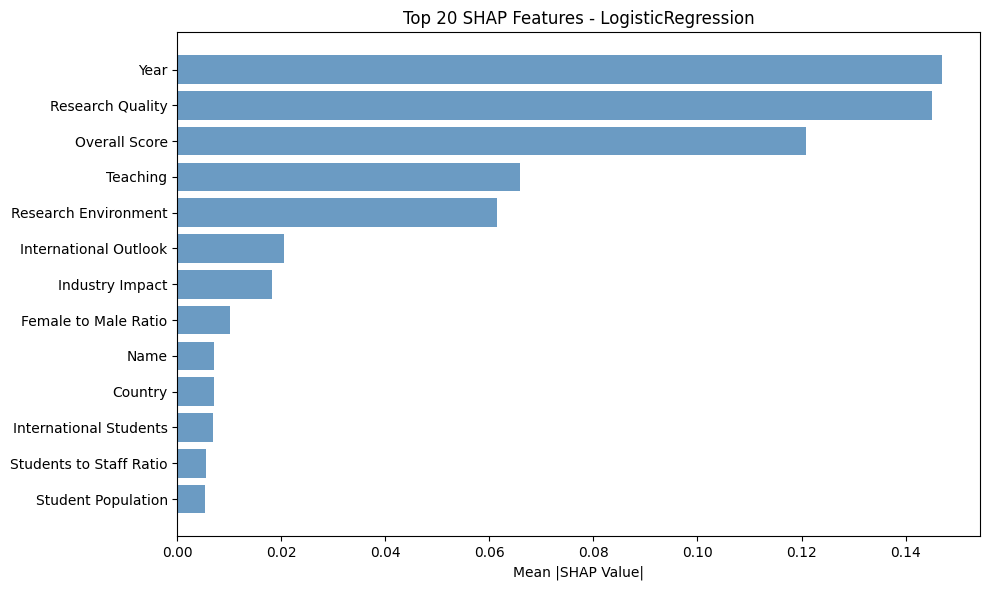

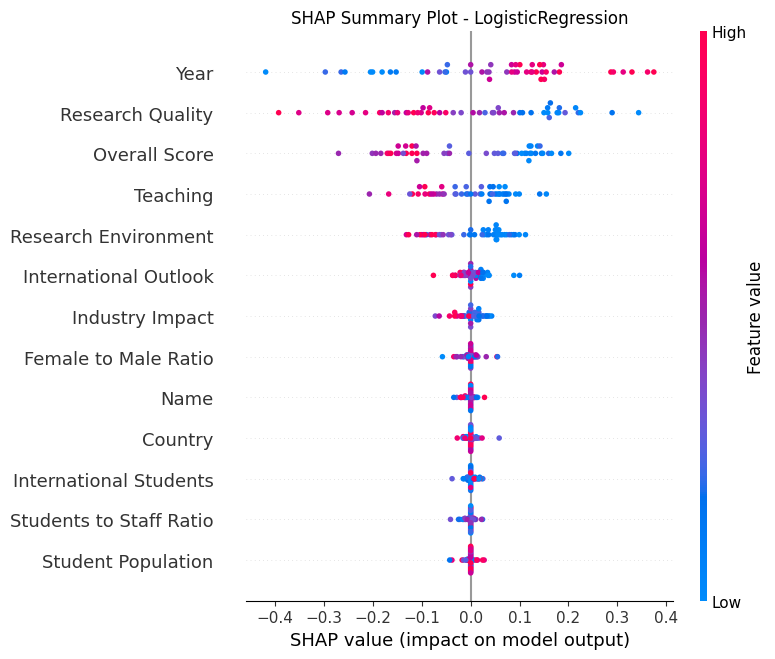

    ✅ SHAP analysis completed for LogisticRegression

      ✅ LogisticRegression: R²=0.1928, MAE=377.0121, RMSE=479.2923
    🔹 Training RandomForest...
    🧠 Computing SHAP values for RandomForest...

    📊 SHAP Feature Importance for RandomForest:
                feature  mean_abs_shap
          Overall Score     437.719097
                   Year     205.826120
     Student Population       0.039978
        Industry Impact       0.036154
Students to Staff Ratio       0.035519
   Research Environment       0.032804
       Research Quality       0.031555
   Female to Male Ratio       0.029167
                   Name       0.028417
 International Students       0.028347
  International Outlook       0.027846
               Teaching       0.027819
                Country       0.026326


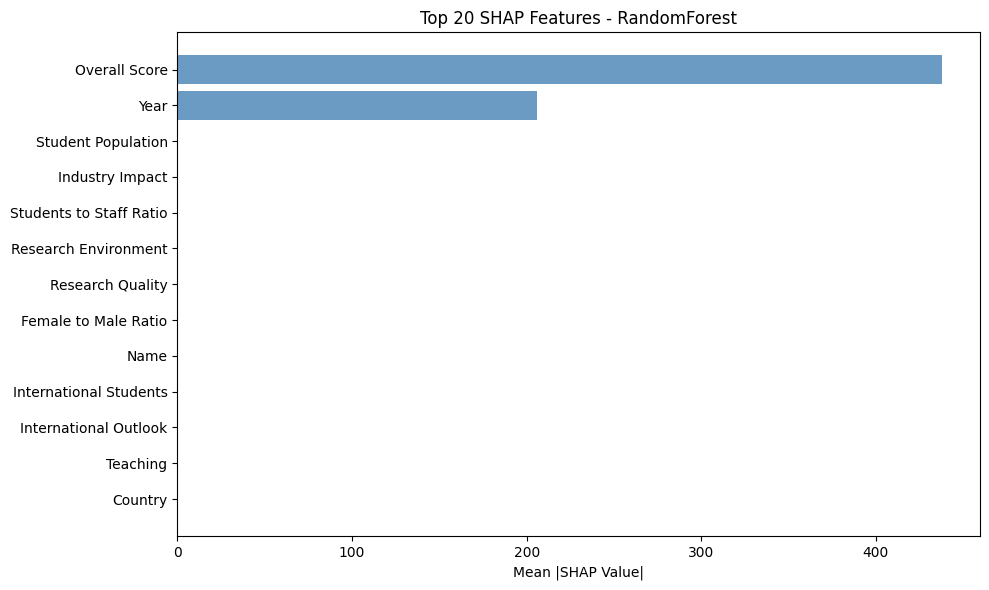

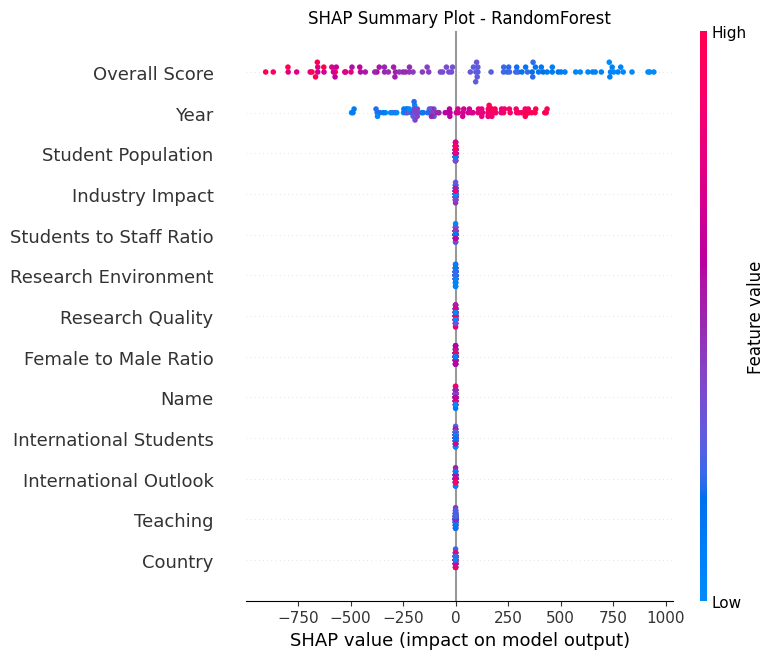

    ✅ SHAP analysis completed for RandomForest

      ✅ RandomForest: R²=1.0000, MAE=1.3101, RMSE=1.6508
    🔹 Training XGBoost...
    🧠 Computing SHAP values for XGBoost...

    📊 SHAP Feature Importance for XGBoost:
                feature  mean_abs_shap
          Overall Score     435.699127
                   Year     208.785080
   Research Environment       0.511539
       Research Quality       0.417092
        Industry Impact       0.261621
  International Outlook       0.168659
               Teaching       0.135411
     Student Population       0.109700
Students to Staff Ratio       0.095600
   Female to Male Ratio       0.078656
                   Name       0.069018
                Country       0.065832
 International Students       0.059695


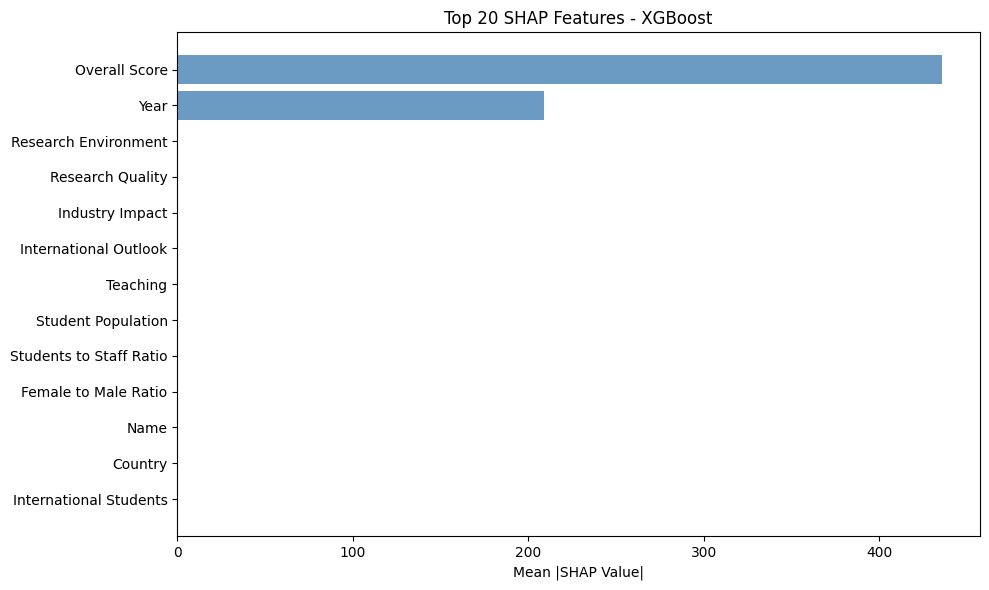

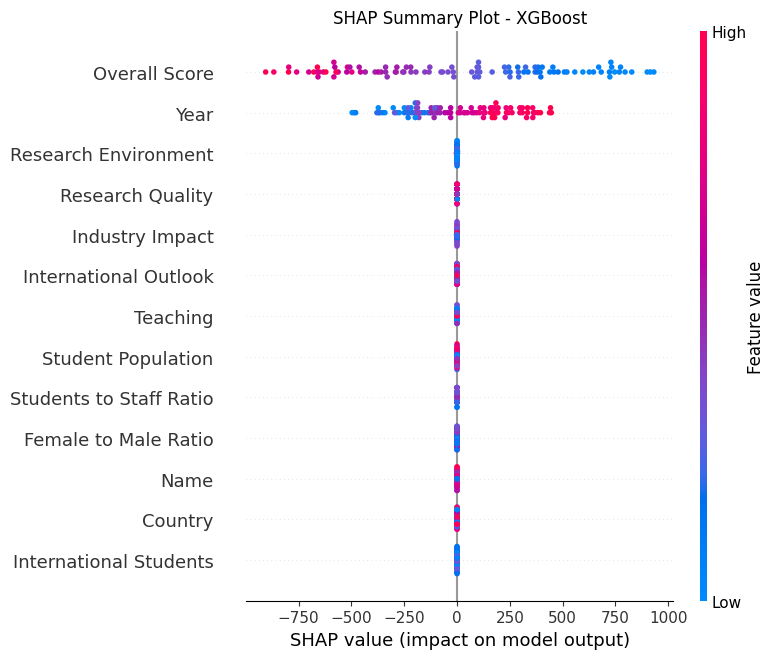

    ✅ SHAP analysis completed for XGBoost

      ✅ XGBoost: R²=0.9997, MAE=6.4239, RMSE=8.4790
    🔹 Training LightGBM...
    🧠 Computing SHAP values for LightGBM...

    📊 SHAP Feature Importance for LightGBM:
                feature  mean_abs_shap
          Overall Score     435.409334
                   Year     208.410543
   Research Environment       0.563663
        Industry Impact       0.287844
       Research Quality       0.284807
               Teaching       0.249768
  International Outlook       0.217793
   Female to Male Ratio       0.141137
 International Students       0.120822
Students to Staff Ratio       0.114827
     Student Population       0.108931
                   Name       0.094448
                Country       0.078098


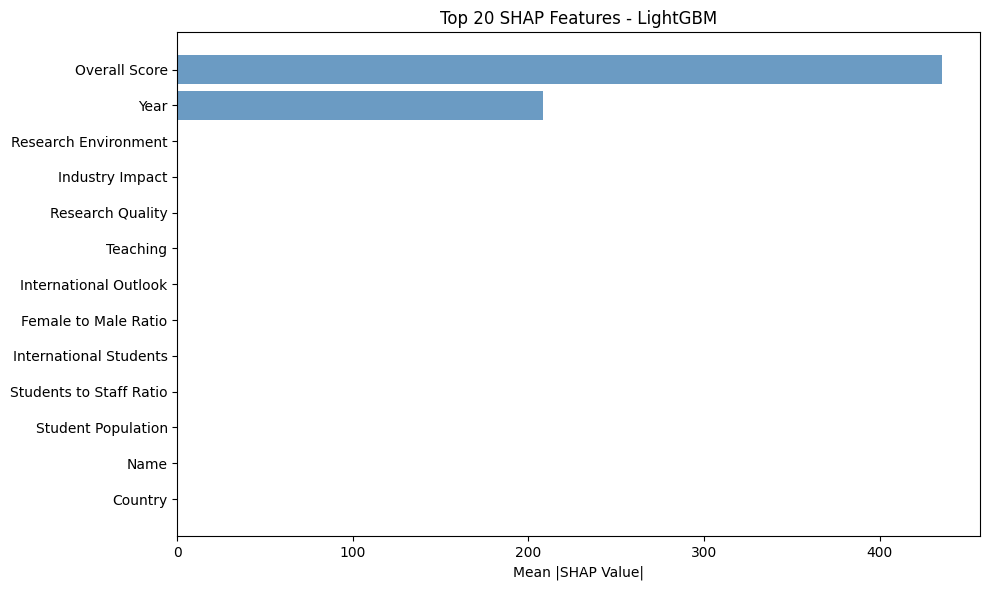

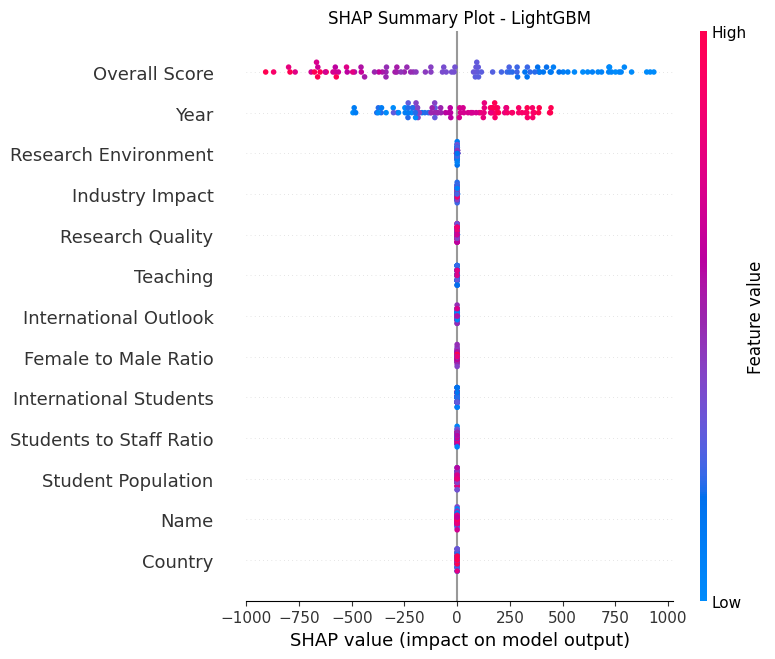

    ✅ SHAP analysis completed for LightGBM

      ✅ LightGBM: R²=0.9997, MAE=7.0992, RMSE=9.3546

    📊 Accuracy Metrics:
             Model       R2        MAE       RMSE       MAPE  Regression_Accuracy
LogisticRegression 0.192765 377.012115 479.292288 311.649340             0.550220
      RandomForest 0.999990   1.310063   1.650764   0.831005             0.998437
           XGBoost 0.999747   6.423885   8.478979   1.794647             0.992336
          LightGBM 0.999692   7.099173   9.354610   2.024157             0.991531

  ⚖️ Running Fairness Analysis...

    📊 Fairness Analysis Results:
             Model  GroupA_RMSE  GroupB_RMSE  Disparity
LogisticRegression     478.4022     480.1877     1.7855
      RandomForest       1.6571       1.6443     0.0128
           XGBoost       8.4215       8.5365     0.1150
          LightGBM       9.2383       9.4704     0.2321
  📈 Calculating Readiness Index...

    📈 Readiness Index:
             Model  Interpretability  Fairness  Scalability 

In [ ]:
results_university = comprehensive_ml_pipeline(
    dataset_path='/content/university_rankings/THE World University Rankings 2016-2026.csv',
    target_column='Rank',
    task_type='auto',
    use_tfidf=False
)

COMPREHENSIVE ML PIPELINE
Includes: Accuracy Metrics, SHAP Analysis, Fairness, and Readiness Index
All results displayed inline

📂 Loading dataset: retention/dataset.csv
  ✅ Dataset loaded: 4424 rows, 35 columns
  ✅ Features: 34 columns
  ✅ Data Quality Score: 4.03/5.0

📊 Processing single target: Target
  🔧 Preprocessing data...
    ✅ Task type: Classification
    ✅ Training: 3539 samples, Test: 885 samples
  🤖 Training models...
    🔹 Training LogisticRegression...
    🧠 Computing SHAP values for LogisticRegression...

    📊 SHAP Feature Importance for LogisticRegression:
                            feature  mean_abs_shap
                  Application order       0.200497
                     Marital status       0.171202
                   Application mode       0.074839
                             Course       0.000000
         Daytime/evening attendance       0.000000
             Previous qualification       0.000000
                        Nacionality       0.000000
           

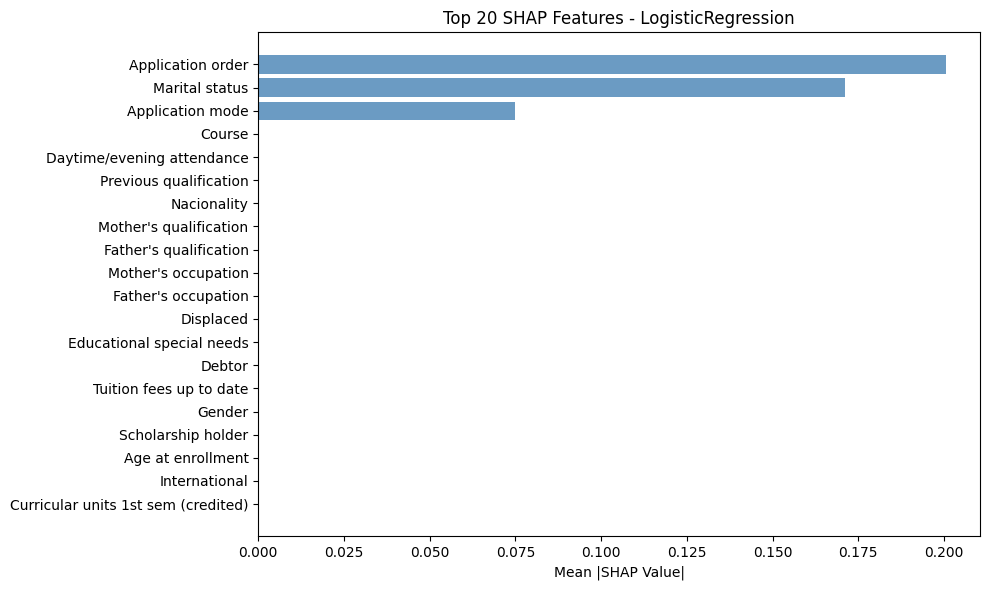

      ⚠️ Summary plot failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
    ✅ SHAP analysis completed for LogisticRegression

      ✅ LogisticRegression: Acc=0.7559, F1=0.7345
    🔹 Training RandomForest...
    🧠 Computing SHAP values for RandomForest...

    📊 SHAP Feature Importance for RandomForest:
                            feature  mean_abs_shap
                  Application order       0.015562
                     Marital status       0.013351
                   Application mode       0.007597
                             Course       0.000000
         Daytime/evening attendance       0.000000
             Previous qualification       0.000000
                        Nacionality       0.000000
             Mother's qualification       0.000000
             Father's qualification       0.000000
                Mother's occupation       0.000000
                Father's occupation       0.000000
                          Displaced 

<Figure size 1000x600 with 0 Axes>

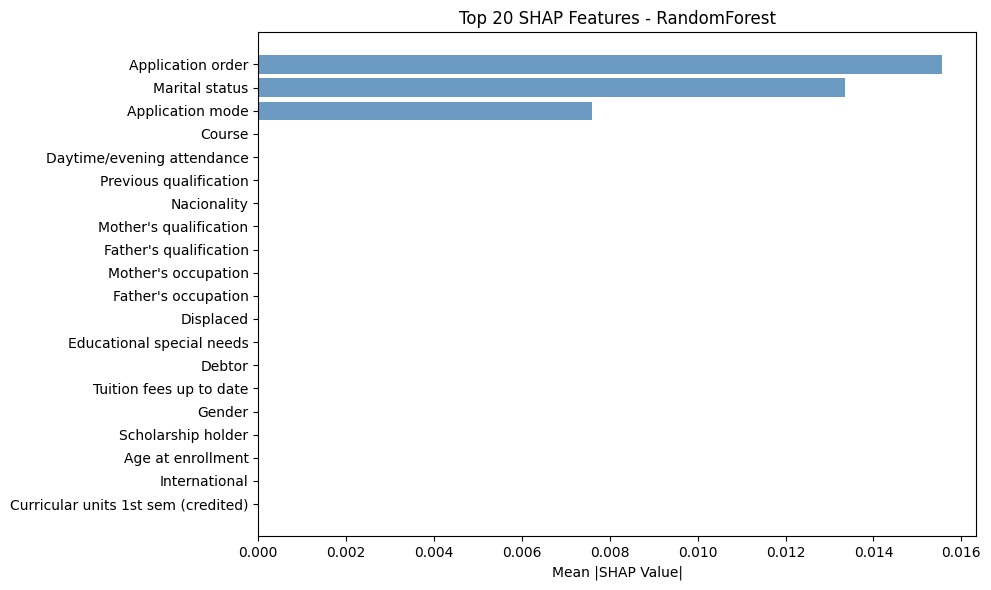

      ⚠️ Summary plot failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
    ✅ SHAP analysis completed for RandomForest

      ✅ RandomForest: Acc=0.7751, F1=0.7587
    🔹 Training XGBoost...
    🧠 Computing SHAP values for XGBoost...

    📊 SHAP Feature Importance for XGBoost:
                            feature  mean_abs_shap
                  Application order       0.107383
                     Marital status       0.098967
                   Application mode       0.062046
                             Course       0.000000
         Daytime/evening attendance       0.000000
             Previous qualification       0.000000
                        Nacionality       0.000000
             Mother's qualification       0.000000
             Father's qualification       0.000000
                Mother's occupation       0.000000
                Father's occupation       0.000000
                          Displaced       0.000000
          Ed

<Figure size 1000x600 with 0 Axes>

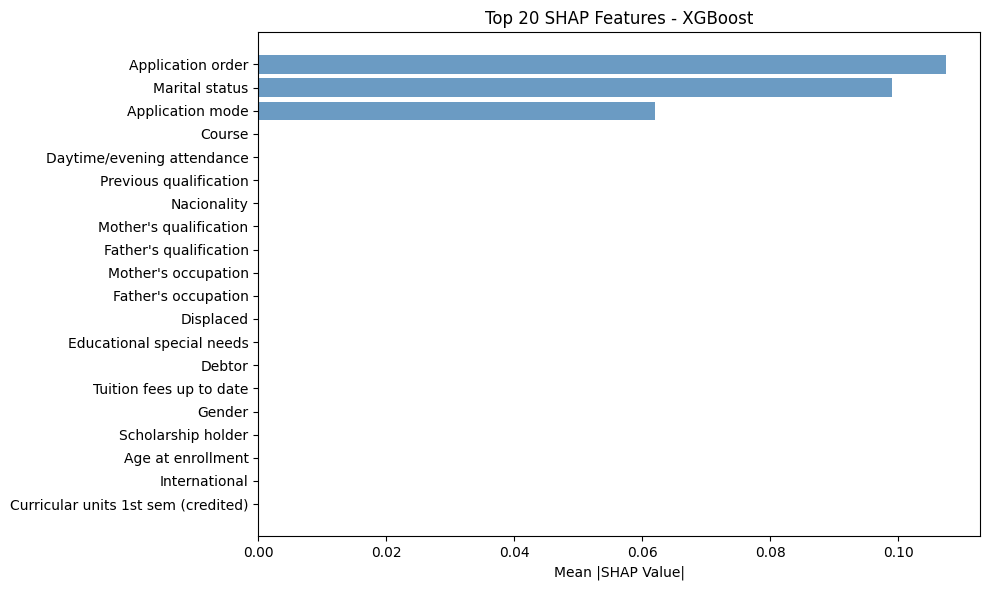

      ⚠️ Summary plot failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
    ✅ SHAP analysis completed for XGBoost

      ✅ XGBoost: Acc=0.7706, F1=0.7605
    🔹 Training LightGBM...
    🧠 Computing SHAP values for LightGBM...

    📊 SHAP Feature Importance for LightGBM:
                            feature  mean_abs_shap
                  Application order       0.128303
                     Marital status       0.111366
                   Application mode       0.081697
                             Course       0.000000
         Daytime/evening attendance       0.000000
             Previous qualification       0.000000
                        Nacionality       0.000000
             Mother's qualification       0.000000
             Father's qualification       0.000000
                Mother's occupation       0.000000
                Father's occupation       0.000000
                          Displaced       0.000000
          Education

<Figure size 1000x600 with 0 Axes>

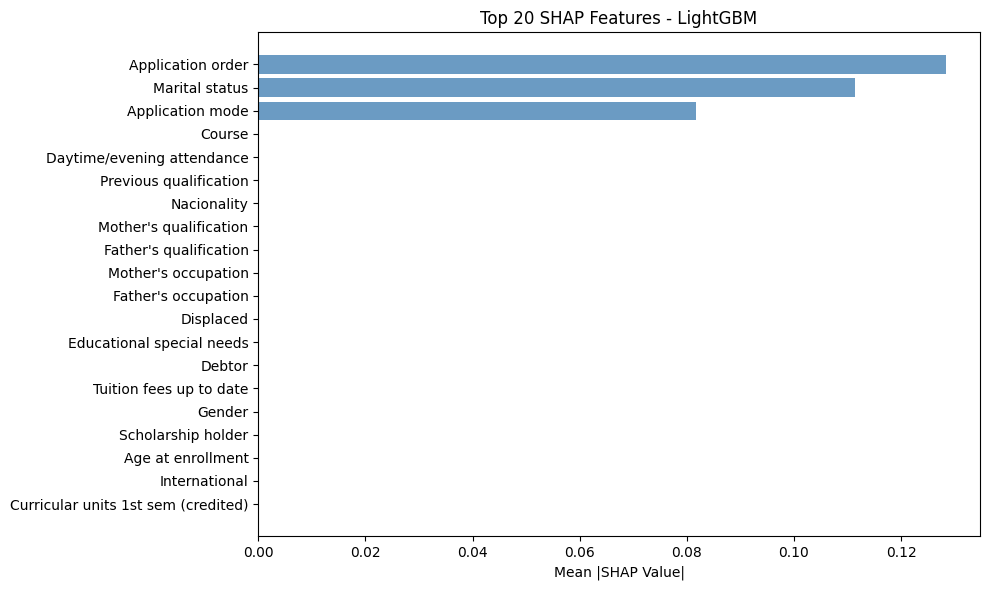

      ⚠️ Summary plot failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
    ✅ SHAP analysis completed for LightGBM

      ✅ LightGBM: Acc=0.7672, F1=0.7602

    📊 Accuracy Metrics:
             Model  Classification_Accuracy  F1_Score
LogisticRegression                 0.755932  0.734545
      RandomForest                 0.775141  0.758665
           XGBoost                 0.770621  0.760494
          LightGBM                 0.767232  0.760230

  ⚖️ Running Fairness Analysis...

    📊 Fairness Analysis Results:
             Model  GroupA_Accuracy  GroupB_Accuracy  Disparity
LogisticRegression           0.7604           0.7517     0.0087
      RandomForest           0.7742           0.7761     0.0019
           XGBoost           0.7788           0.7627     0.0161
          LightGBM           0.7857           0.7494     0.0363
  📈 Calculating Readiness Index...

    📈 Readiness Index:
             Model  Interpretability  Fairness  Scala

<Figure size 1000x600 with 0 Axes>

In [ ]:
results_dropout = comprehensive_ml_pipeline(
    dataset_path='retention/dataset.csv',
    target_column='Target',
    task_type='auto',
    use_tfidf=True
)

COMPREHENSIVE ML PIPELINE
Includes: Accuracy Metrics, SHAP Analysis, Fairness, and Readiness Index
All results displayed inline

📂 Loading dataset: college_enrollment/enrollment.csv
  ✅ Dataset loaded: 6 rows, 21 columns
  🔄 Detected enrollment-like dataset (Type column + year columns)
     Found 'Type' column and 19 year columns
     ✅ Transformed (enrollment pattern): 6 rows × 21 cols → 114 rows × 3 cols
     ✅ Created columns: Type, Year, Enrollment
  ✅ Dataset transformed from wide to long format
  ✅ Features: 2 columns
  ✅ Data Quality Score: 4.25/5.0

📊 Processing single target: Enrollment
  🔧 Preprocessing data...
    ✅ Task type: Regression
    ✅ Training: 91 samples, Test: 23 samples
  🤖 Training models...
    🔹 Training LogisticRegression...
    🧠 Computing SHAP values for LogisticRegression...


  0%|          | 0/23 [00:00<?, ?it/s]


    📊 SHAP Feature Importance for LogisticRegression:
feature  mean_abs_shap
   Type       0.513043
   Year       0.000000


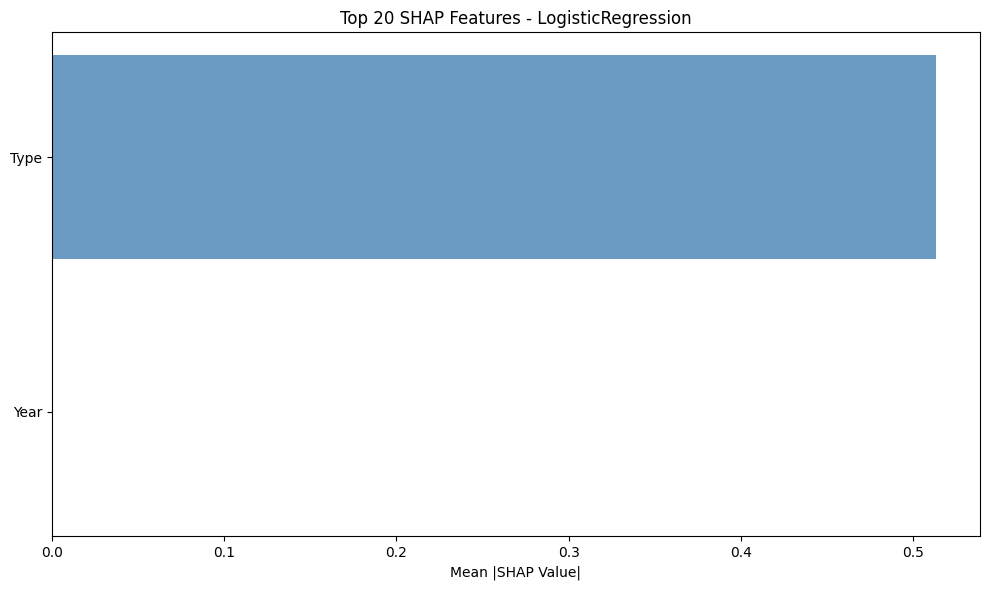

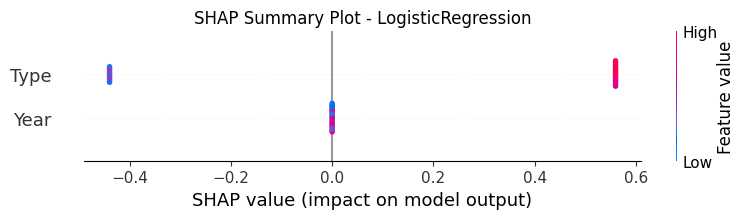

    ✅ SHAP analysis completed for LogisticRegression

      ✅ LogisticRegression: R²=0.1063, MAE=6036300.6435, RMSE=6349858.0768
    🔹 Training RandomForest...
    🧠 Computing SHAP values for RandomForest...

    📊 SHAP Feature Importance for RandomForest:
feature  mean_abs_shap
   Type   6.340792e+06
   Year   8.181756e+05


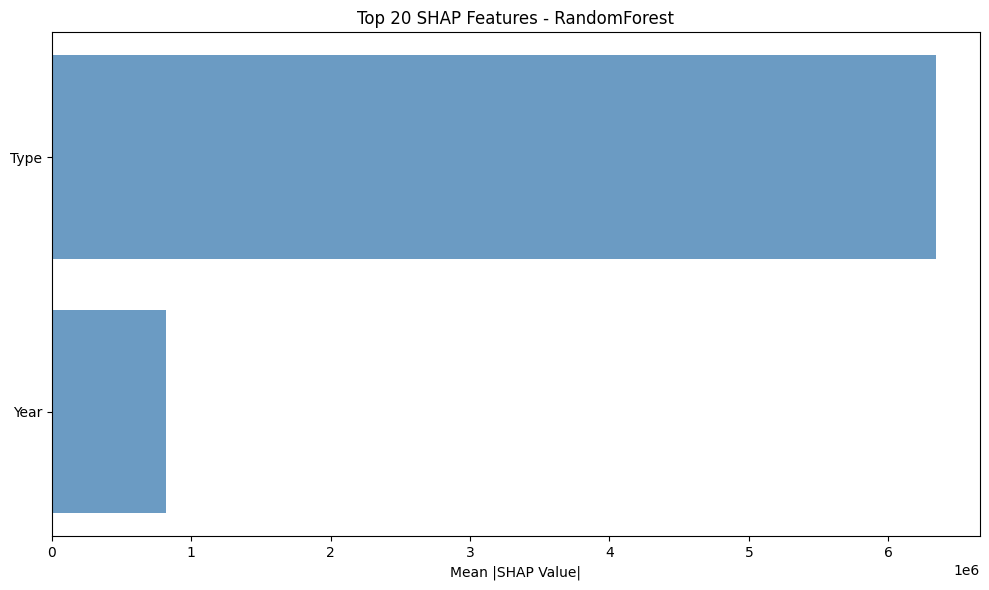

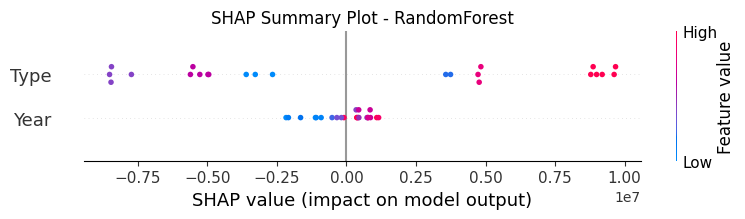

    ✅ SHAP analysis completed for RandomForest

      ✅ RandomForest: R²=0.9974, MAE=199164.8185, RMSE=341658.4400
    🔹 Training XGBoost...
    🧠 Computing SHAP values for XGBoost...

    📊 SHAP Feature Importance for XGBoost:
feature  mean_abs_shap
   Type     6379822.50
   Year      803111.75


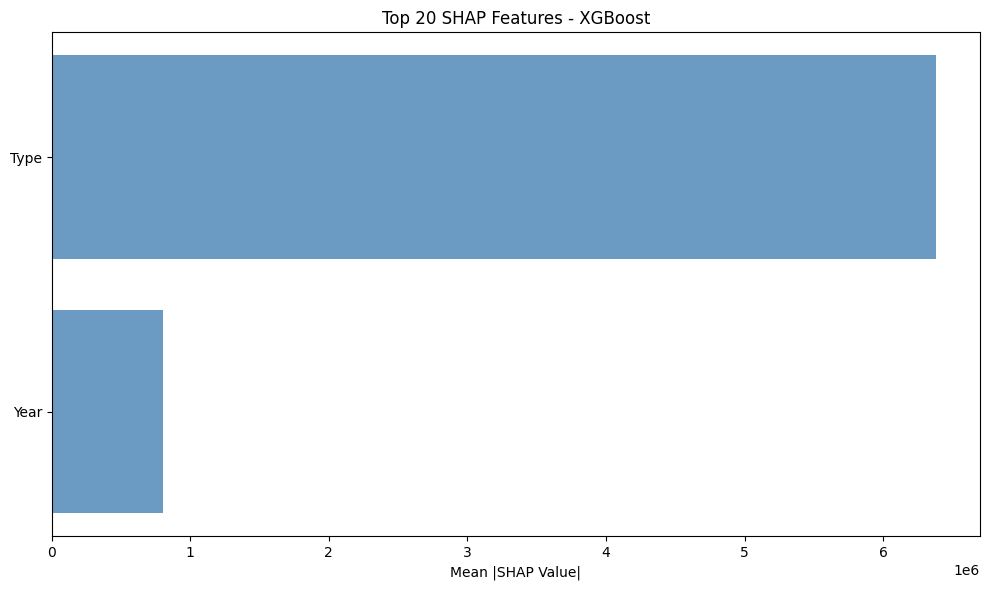

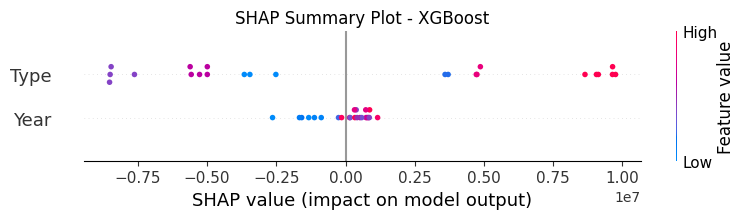

    ✅ SHAP analysis completed for XGBoost

      ✅ XGBoost: R²=0.9973, MAE=217558.7031, RMSE=348070.5650
    🔹 Training LightGBM...
    🧠 Computing SHAP values for LightGBM...

    📊 SHAP Feature Importance for LightGBM:
feature  mean_abs_shap
   Type   5.345001e+06
   Year   9.752564e+05


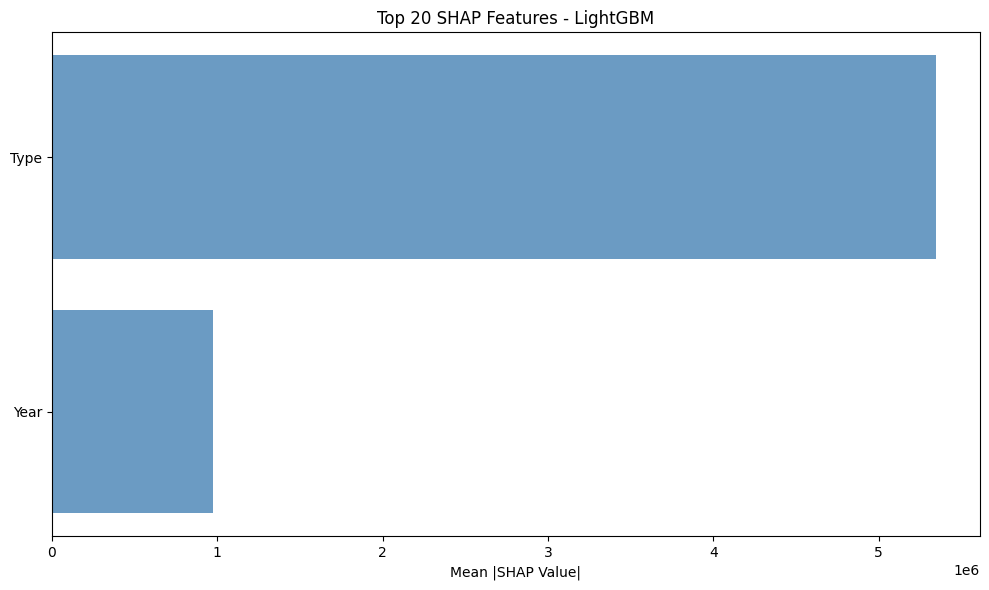

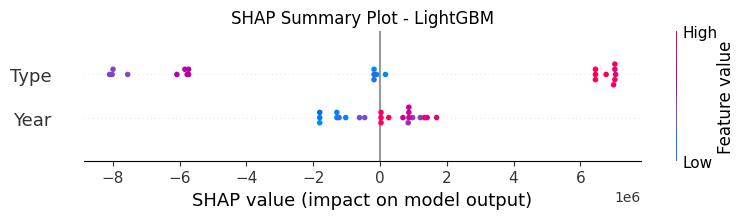

    ✅ SHAP analysis completed for LightGBM

      ✅ LightGBM: R²=0.8579, MAE=2083320.8142, RMSE=2532321.3126

    📊 Accuracy Metrics:
             Model       R2          MAE         RMSE       MAPE  Regression_Accuracy
LogisticRegression 0.106326 6.036301e+06 6.349858e+06 245.162568             0.348890
      RandomForest 0.997413 1.991648e+05 3.416584e+05   3.087738             0.978517
           XGBoost 0.997315 2.175587e+05 3.480706e+05   3.882244             0.976533
          LightGBM 0.857869 2.083321e+06 2.532321e+06  36.185467             0.775281

  ⚖️ Running Fairness Analysis...

    📊 Fairness Analysis Results:
             Model  GroupA_RMSE  GroupB_RMSE   Disparity
LogisticRegression 6437149.5914 6211633.4998 225516.0916
      RandomForest  389610.2449  249367.0344 140243.2106
           XGBoost  226764.2559  479190.6991 252426.4431
          LightGBM 2490111.2841 2596617.8727 106506.5887
  📈 Calculating Readiness Index...

    📈 Readiness Index:
             Model  Int

In [ ]:
results = comprehensive_ml_pipeline(
        dataset_path='college_enrollment/enrollment.csv',
        target_column='Enrollment',
        task_type='auto'
    )


COMPREHENSIVE ML PIPELINE
Includes: Accuracy Metrics, SHAP Analysis, Fairness, and Readiness Index
All results displayed inline

📂 Loading dataset: /content/student_performance/StudentPerformanceFactors.csv
  ✅ Dataset loaded: 6607 rows, 20 columns
  ✅ Features: 19 columns
  ✅ Data Quality Score: 3.94/5.0

📊 Processing single target: Exam_Score
  🔧 Preprocessing data...
    ✅ Task type: Regression
    ✅ Training: 5285 samples, Test: 1322 samples
  🤖 Training models...
    🔹 Training LogisticRegression...
    🧠 Computing SHAP values for LogisticRegression...


  0%|          | 0/50 [00:00<?, ?it/s]


    📊 SHAP Feature Importance for LogisticRegression:
                   feature  mean_abs_shap
                Attendance       0.308279
             Hours_Studied       0.177109
           Previous_Scores       0.071215
         Tutoring_Sessions       0.053644
      Parental_Involvement       0.038396
       Access_to_Resources       0.031479
            Peer_Influence       0.030401
        Distance_from_Home       0.022637
     Learning_Disabilities       0.020323
Extracurricular_Activities       0.018368
           Teacher_Quality       0.017543
         Physical_Activity       0.010916
           Internet_Access       0.010115
  Parental_Education_Level       0.010014
          Motivation_Level       0.007485
             Family_Income       0.005081
                    Gender       0.004722
               Sleep_Hours       0.002455
               School_Type       0.001607


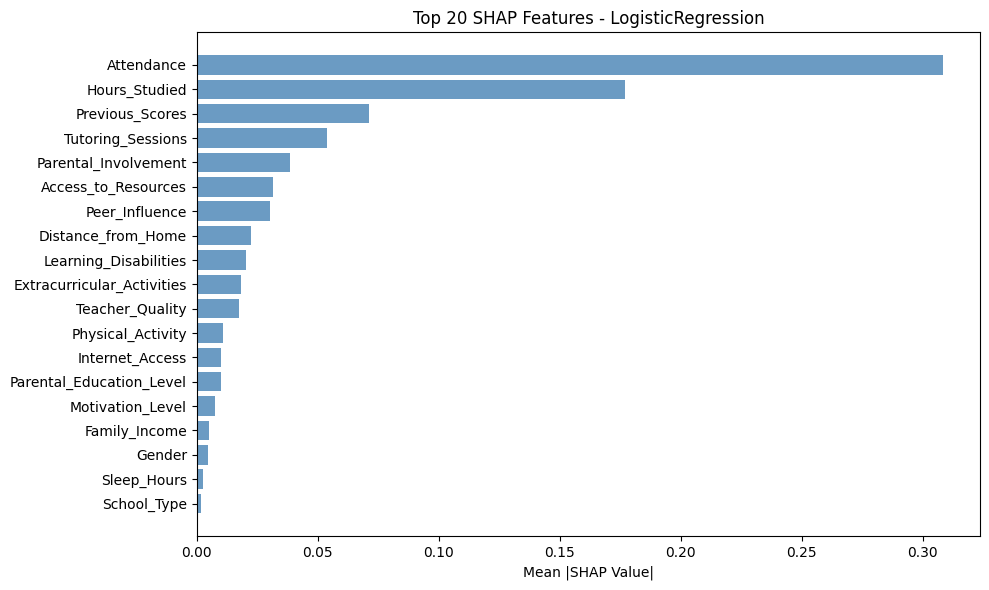

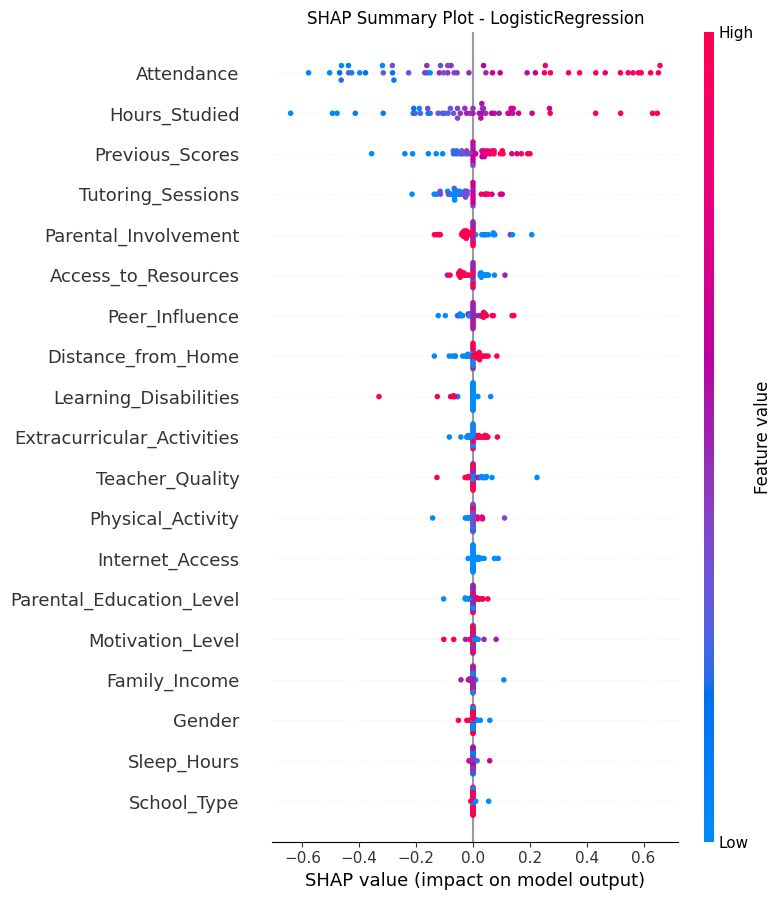

    ✅ SHAP analysis completed for LogisticRegression

      ✅ LogisticRegression: R²=-0.8251, MAE=4.3796, RMSE=5.0792
    🔹 Training RandomForest...
    🧠 Computing SHAP values for RandomForest...

    📊 SHAP Feature Importance for RandomForest:
                   feature  mean_abs_shap
                Attendance       2.199675
             Hours_Studied       1.360151
           Previous_Scores       0.591775
       Access_to_Resources       0.371769
      Parental_Involvement       0.326291
         Tutoring_Sessions       0.267526
            Peer_Influence       0.134473
             Family_Income       0.101230
  Parental_Education_Level       0.093243
        Distance_from_Home       0.087482
         Physical_Activity       0.084141
           Teacher_Quality       0.078549
          Motivation_Level       0.074866
Extracurricular_Activities       0.056521
               Sleep_Hours       0.050715
     Learning_Disabilities       0.047886
           Internet_Access       0.02823

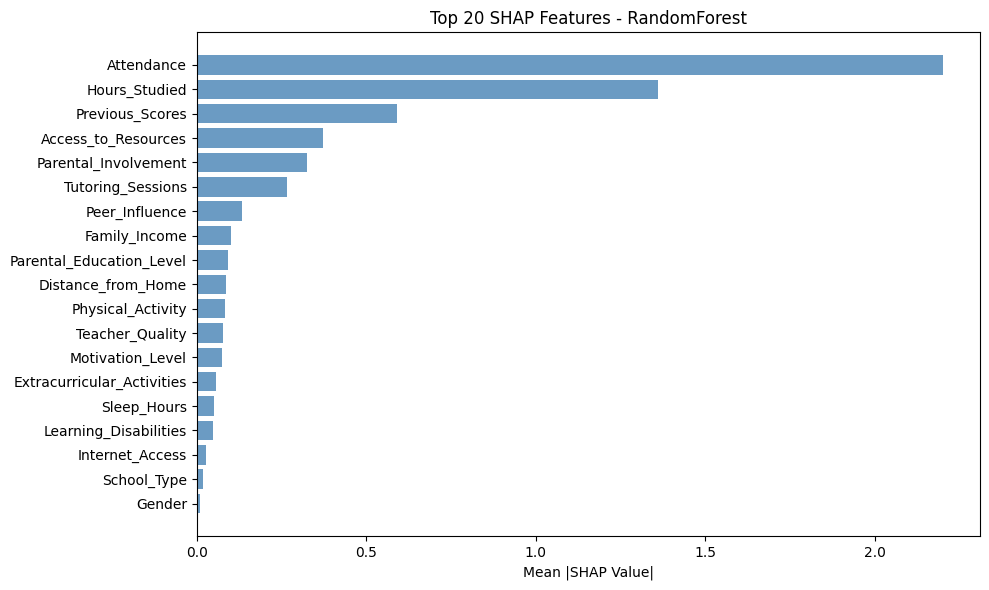

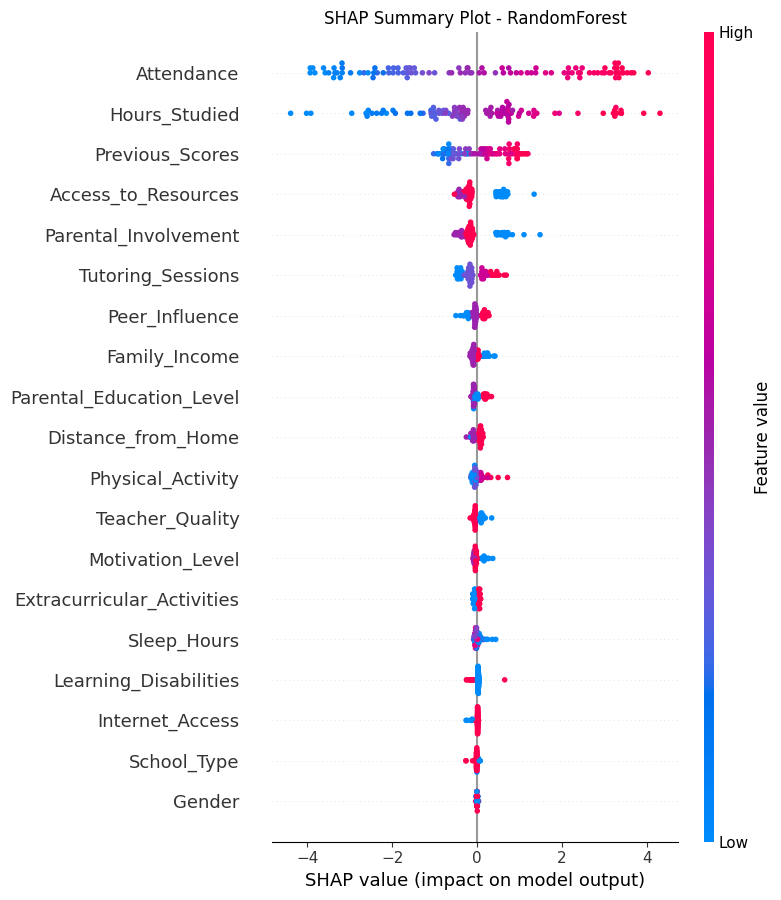

    ✅ SHAP analysis completed for RandomForest

      ✅ RandomForest: R²=0.6593, MAE=1.1187, RMSE=2.1945
    🔹 Training XGBoost...
    🧠 Computing SHAP values for XGBoost...

    📊 SHAP Feature Importance for XGBoost:
                   feature  mean_abs_shap
                Attendance       2.187799
             Hours_Studied       1.386345
           Previous_Scores       0.631743
       Access_to_Resources       0.508035
      Parental_Involvement       0.442153
         Tutoring_Sessions       0.392446
             Family_Income       0.310925
            Peer_Influence       0.294555
  Parental_Education_Level       0.279183
        Distance_from_Home       0.263832
           Teacher_Quality       0.255359
          Motivation_Level       0.241409
Extracurricular_Activities       0.235550
     Learning_Disabilities       0.158819
         Physical_Activity       0.134389
           Internet_Access       0.129094
               Sleep_Hours       0.037322
                    Gender

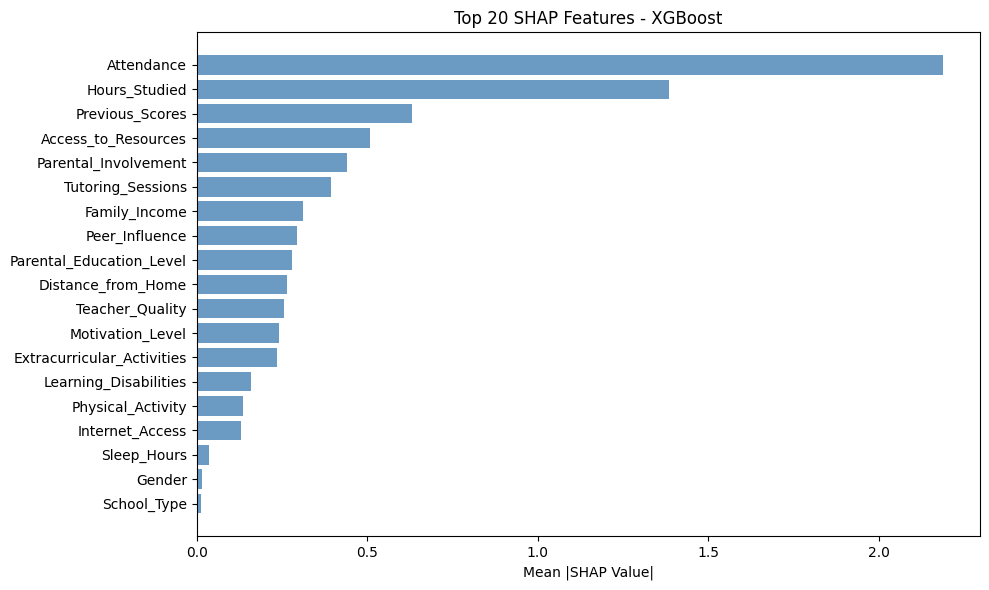

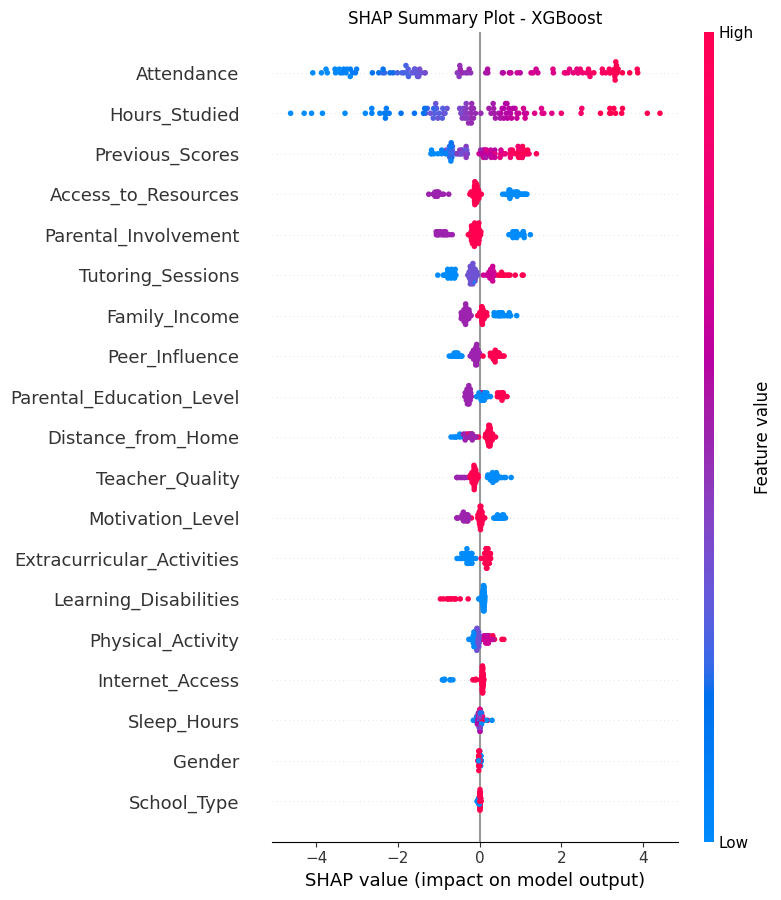

    ✅ SHAP analysis completed for XGBoost

      ✅ XGBoost: R²=0.7373, MAE=0.7280, RMSE=1.9269
    🔹 Training LightGBM...
    🧠 Computing SHAP values for LightGBM...

    📊 SHAP Feature Importance for LightGBM:
                   feature  mean_abs_shap
                Attendance       2.187468
             Hours_Studied       1.399913
           Previous_Scores       0.635668
       Access_to_Resources       0.516234
      Parental_Involvement       0.425385
         Tutoring_Sessions       0.382698
             Family_Income       0.326765
            Peer_Influence       0.294711
  Parental_Education_Level       0.281678
        Distance_from_Home       0.269453
           Teacher_Quality       0.244108
          Motivation_Level       0.241232
Extracurricular_Activities       0.240925
     Learning_Disabilities       0.164344
         Physical_Activity       0.141698
           Internet_Access       0.109207
               Sleep_Hours       0.033849
                    Gender       

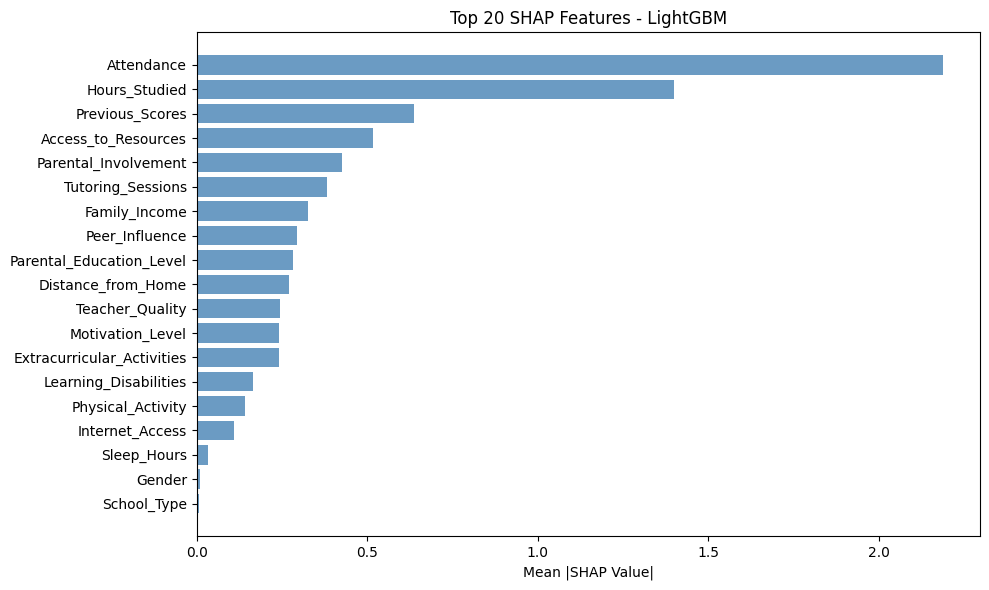

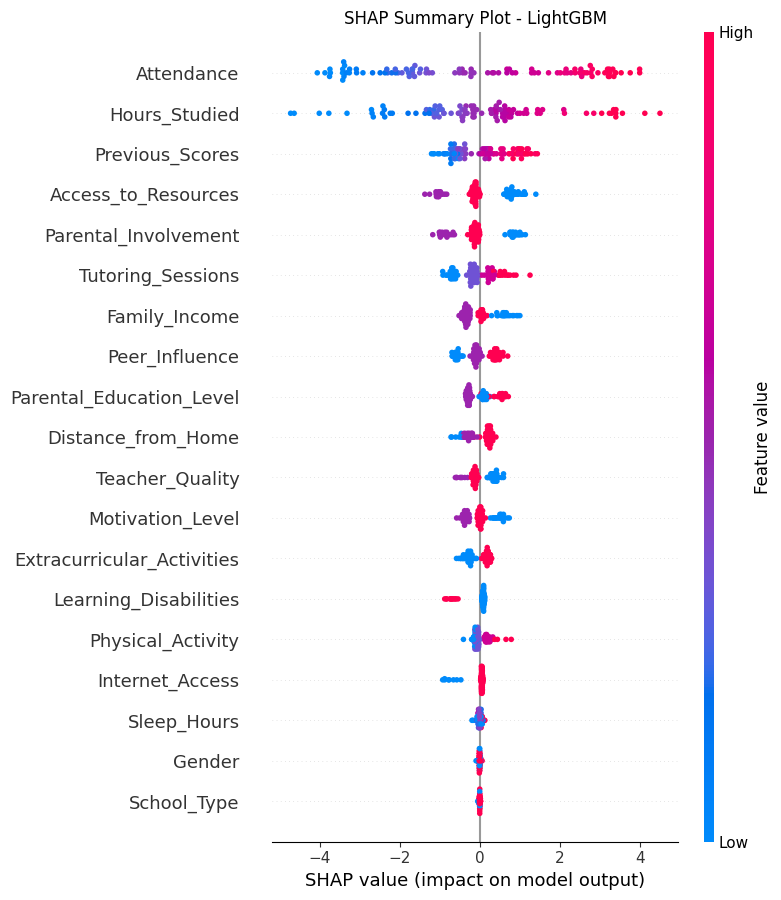

    ✅ SHAP analysis completed for LightGBM

      ✅ LightGBM: R²=0.7439, MAE=0.7314, RMSE=1.9028

    📊 Accuracy Metrics:
             Model        R2      MAE     RMSE     MAPE  Regression_Accuracy
LogisticRegression -0.825128 4.379576 5.079205 6.486119             0.934942
      RandomForest  0.659288 1.118707 2.194535 1.627060             0.983382
           XGBoost  0.737334 0.727998 1.926864 1.040516             0.989186
          LightGBM  0.743854 0.731365 1.902797 1.044620             0.989136

  ⚖️ Running Fairness Analysis...

    📊 Fairness Analysis Results:
             Model  GroupA_RMSE  GroupB_RMSE  Disparity
LogisticRegression       4.9127       5.2414     0.3287
      RandomForest       2.0754       2.3082     0.2327
           XGBoost       1.7066       2.1255     0.4189
          LightGBM       1.6791       2.1040     0.4249
  📈 Calculating Readiness Index...

    📈 Readiness Index:
             Model  Interpretability  Fairness  Scalability  Accuracy  Data_Quality  

In [ ]:
results = comprehensive_ml_pipeline(
        dataset_path='/content/student_performance/StudentPerformanceFactors.csv',
        target_column='Exam_Score',
        task_type='auto'
    )

In [ ]:
import pandas as pd
df1 = pd.read_csv('/content/education/TestData.csv')
df2 = pd.read_csv('/content/education/TrainingData.csv')
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df.to_csv('output.csv')

/tmp/ipython-input-2464018795.py:2: DtypeWarning: Columns (5,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('/content/education/TestData.csv')


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=5000, random_state=42)
for _, sample_idx in sss.split(X, y):
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]


In [ ]:
df = pd.read_csv('/content/output.csv')
df.shape

/tmp/ipython-input-3663481424.py:1: DtypeWarning: Columns (6,12,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/output.csv')


(450341, 27)

In [ ]:
df.shape
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Object_Description',
       'Program_Description', 'SubFund_Description', 'Job_Title_Description',
       'Facility_or_Department', 'Sub_Object_Description',
       'Location_Description', 'FTE', 'Function_Description', 'Position_Extra',
       'Text_4', 'Total', 'Text_2', 'Text_3', 'Fund_Description', 'Text_1',
       'Function', 'Use', 'Sharing', 'Reporting', 'Student_Type',
       'Position_Type', 'Object_Type', 'Pre_K', 'Operating_Status'],
      dtype='object')

In [ ]:
import pandas as pd

# -------------------------
# Load data
# -------------------------
# df = pd.read_csv("your_file.csv")  # uncomment and set path

# Ensure numeric Total
df["Total"] = pd.to_numeric(df["Total"], errors="coerce").fillna(0)

# Normalize empty strings
df = df.replace(r"^\s*$", pd.NA, regex=True)

# -------------------------
# FINAL AGGREGATION
# -------------------------
final_df = (
    df.groupby(
        [
            "Program_Description",
            "Function_Description",
            "Fund_Description",
            "Location_Description"  # keep or remove if you want even fewer rows
        ],
        dropna=False
    )
    .agg(
        total_budget=("Total", "sum"),
        total_fte=("FTE", "sum"),
        num_records=("Total", "count")
    )
    .reset_index()
)

# -------------------------
# OPTIONAL CLEANUPS
# -------------------------

# Replace very rare categories with "Other" (reduces sparsity)
for col in ["Program_Description", "Function_Description"]:
    top = final_df[col].value_counts().nlargest(15).index
    final_df[col] = final_df[col].where(final_df[col].isin(top), "Other")

# Re-aggregate after collapsing rare categories
final_df = (
    final_df.groupby(
        [
            "Program_Description",
            "Function_Description",
            "Fund_Description",
            "Location_Description"
        ],
        dropna=False
    )
    .agg(
        total_budget=("total_budget", "sum"),
        total_fte=("total_fte", "sum"),
        num_records=("num_records", "sum")
    )
    .reset_index()
)

# -------------------------
# Save FINAL dataset
# -------------------------
final_df.to_csv("budgetDataset.csv", index=False)

print("Final dataset saved as budgetDataset.csv")
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])


Final dataset saved as budgetDataset.csv
Rows: 2467
Columns: 7


COMPREHENSIVE ML PIPELINE
Includes: Accuracy Metrics, SHAP Analysis, Fairness, and Readiness Index
All results displayed inline

📂 Loading dataset: /content/budgetDataset.csv
  ✅ Dataset loaded: 2467 rows, 7 columns
  ✅ Features: 6 columns
  ✅ Data Quality Score: 3.55/5.0

📊 Processing single target: total_budget
  🔧 Preprocessing data...
  📝 Detected 1 text columns for TF-IDF: ['Location_Description']...
  ✅ TF-IDF: 816 features from 1 text columns
    ✅ Task type: Regression
    ✅ Training: 1973 samples, Test: 494 samples
  🤖 Training models...
    🔹 Training LogisticRegression...
    🧠 Computing SHAP values for LogisticRegression...


  0%|          | 0/50 [00:00<?, ?it/s]


    📊 SHAP Feature Importance for LogisticRegression:
               feature  mean_abs_shap
  Function_Description       0.071602
      Fund_Description       0.055559
           num_records       0.045869
   Program_Description       0.045301
                school       0.030593
                office       0.024937
     interdisciplinary       0.017130
             total_fte       0.015926
              facility       0.008955
  assoc superintendent       0.008536
superintendent schools       0.008301
          organization       0.008056
             homebound       0.007847
   information service       0.006436
               ed head       0.005957
           unallocated       0.005790
              physical       0.005317
                manual       0.004598
               science       0.004576
               english       0.004256


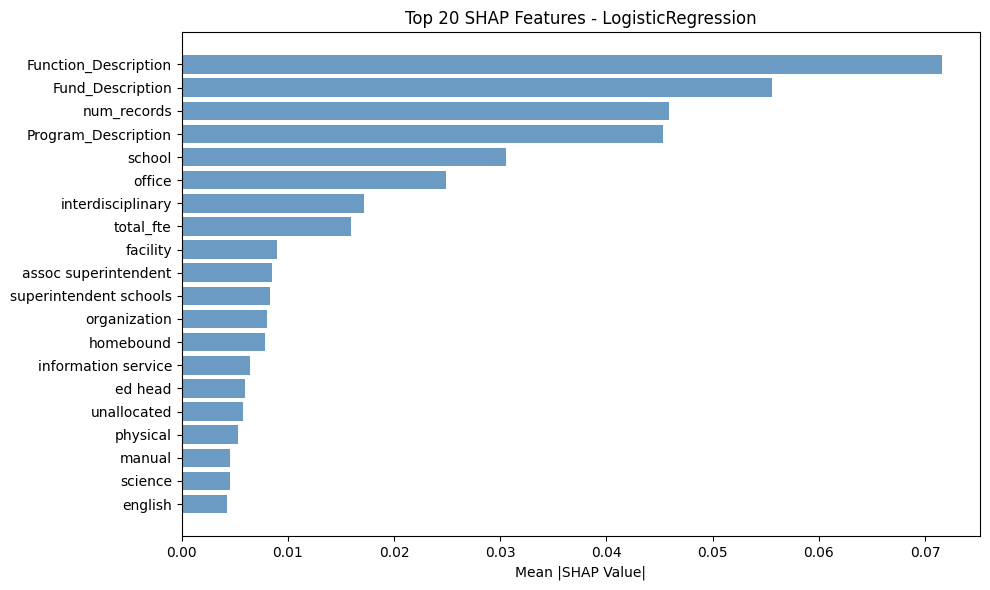

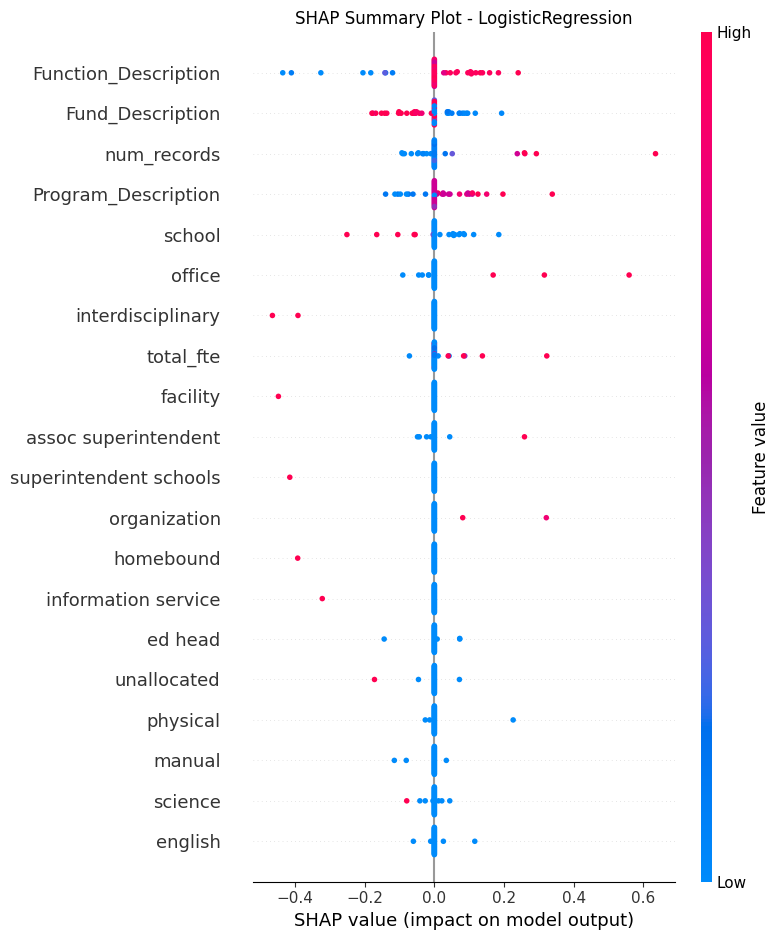

    ✅ SHAP analysis completed for LogisticRegression

      ✅ LogisticRegression: R²=-0.0206, MAE=2336349.3437, RMSE=15713059.6651
    🔹 Training RandomForest...
    🧠 Computing SHAP values for RandomForest...
    ⚠️ SHAP failed for RandomForest: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was -47586534.353043, while the model output was 64354.723423. If this difference is acceptable you can set check_additivity=False to disable this check.
    ✅ Using model feature importances as fallback

      ✅ RandomForest: R²=0.1538, MAE=2327411.2923, RMSE=14307363.1914
    🔹 Training XGBoost...
    🧠 Computing SHAP values for XGBoost...

    📊 SHAP Feature Importance for XGBoost:
  

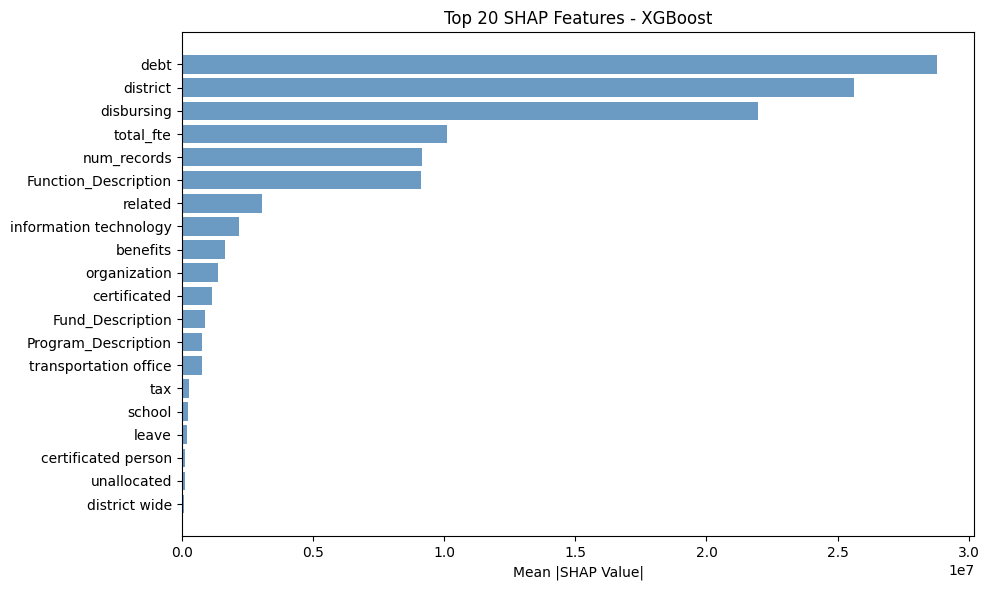

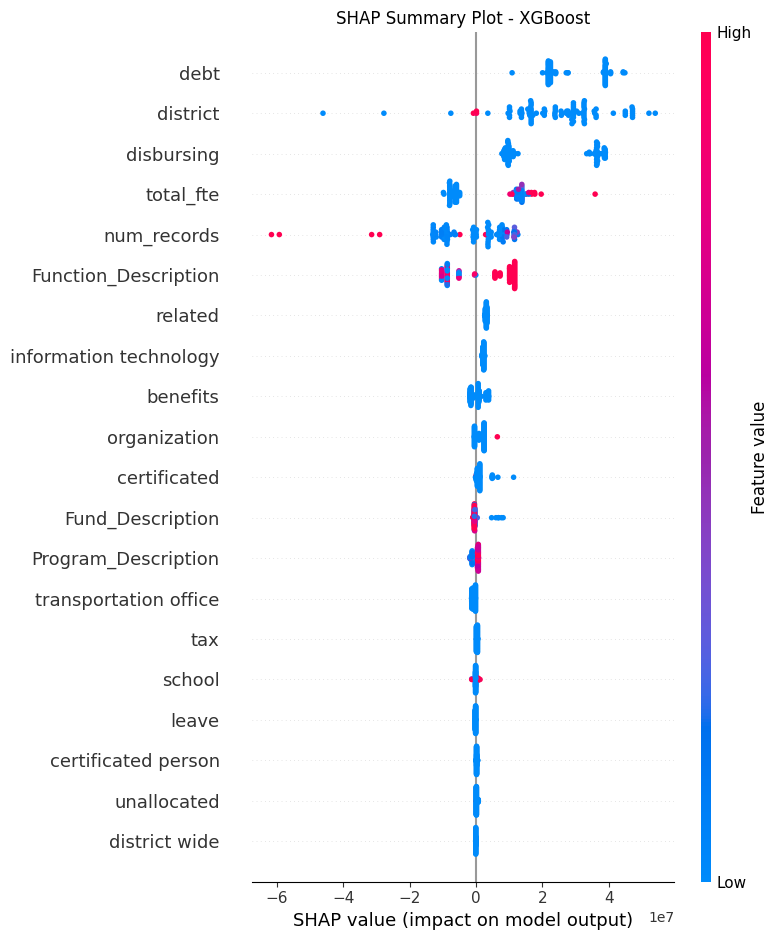

    ✅ SHAP analysis completed for XGBoost

      ✅ XGBoost: R²=0.2037, MAE=2292478.7228, RMSE=13878986.6223
    🔹 Training LightGBM...
    🧠 Computing SHAP values for LightGBM...

    📊 SHAP Feature Importance for LightGBM:
             feature  mean_abs_shap
         num_records   2.093336e+06
           total_fte   1.602989e+06
 Program_Description   1.159897e+06
    Fund_Description   1.079056e+06
Function_Description   6.879547e+05
            district   2.342363e+05
       undistributed   6.004271e+04
              school   4.682619e+04
           community   1.677420e+04
            learning   7.774573e+03
            services   2.364797e+03
  planning community   0.000000e+00
            planning   0.000000e+00
           placement   0.000000e+00
  physical education   0.000000e+00
            physical   0.000000e+00
      personnel paid   0.000000e+00
           personnel   0.000000e+00
              person   0.000000e+00
     performing arts   0.000000e+00


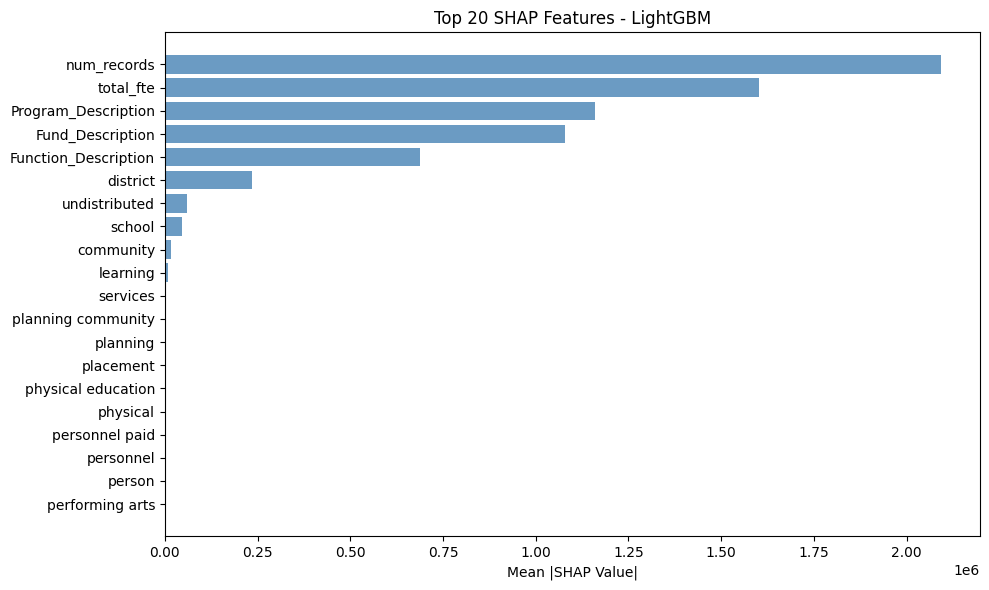

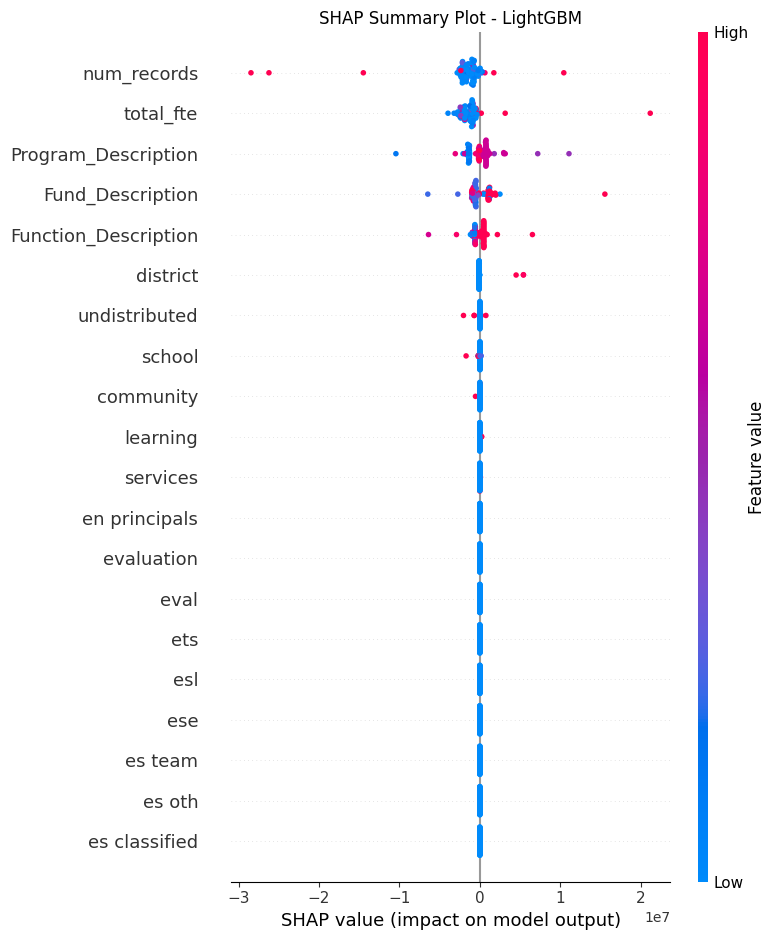

    ✅ SHAP analysis completed for LightGBM

      ✅ LightGBM: R²=0.0275, MAE=3876297.1737, RMSE=15338062.2892

    📊 Accuracy Metrics:
             Model        R2          MAE         RMSE         MAPE  Regression_Accuracy
LogisticRegression -0.020634 2.336349e+06 1.571306e+07 2.108786e+14             0.000000
      RandomForest  0.153810 2.327411e+06 1.430736e+07 1.984602e+15             0.000087
           XGBoost  0.203723 2.292479e+06 1.387899e+07 2.080225e+15             0.015094
          LightGBM  0.027500 3.876297e+06 1.533806e+07 2.563332e+15             0.000000

  ⚖️ Running Fairness Analysis...

    📊 Fairness Analysis Results:
             Model  GroupA_RMSE  GroupB_RMSE    Disparity
LogisticRegression 9.401057e+06 1.991691e+07 1.051585e+07
      RandomForest 8.413275e+06 1.819991e+07 9.786637e+06
           XGBoost 8.667618e+06 1.742552e+07 8.757898e+06
          LightGBM 1.162925e+07 1.815930e+07 6.530041e+06
  📈 Calculating Readiness Index...

    📈 Readiness Index:
  

In [ ]:
results = comprehensive_ml_pipeline(
        dataset_path='/content/budgetDataset.csv',
        target_column='total_budget',
        task_type='auto'
    )

In [ ]:
dify = pd.read_csv('/content/budgetDataset.csv')
dify.tail()

,Program_Description,Function_Description,Fund_Description,Location_Description,total_budget,total_fte,num_records
2462,Undistributed,School Leadership,General Operating Fund,Undistributed,1.161592e+06,0.00,24
2463,Undistributed,School Leadership,Locally Funded Special Revenue Funds,Unallocated,9.069340e+03,0.00,2
2464,Undistributed,School Leadership,Lower Strands Prj.,School,6.037518e+03,0.00,4
2465,Undistributed,School Leadership,Student Activity Account,School,1.975956e+03,0.06,1
2466,Undistributed,School Leadership,Title Iv Part B Century Community Learning Ce,School,6.006100e+02,0.00,1


,Dataset Name,Task,Rows,Columns,df.shape,Target Variable,% Missing Values,# Numerical Features,# Text Features,# Label Features,Numerical Columns,Text Columns,Label Columns,Missing Values per Column
0,Student Performance Factors,Regression/Classification,6607,20,"(6607, 20)",Final Grade,0.18,7,0,0,"[Hours_Studied, Attendance, Sleep_Hours, Previ...",[],[],"{'Hours_Studied': 0, 'Attendance': 0, 'Parenta..."
1,College Enrollment US,Regression,6,21,"(6, 21)",Enrollment,0.00,20,0,0,"[Unnamed: 0, 2003, 2004, 2005, 2006, 2007, 200...",[],[],"{'Unnamed: 0': 0, 'Type': 0, '2003': 0, '2004'..."
2,World University Rankings,Regression,16713,14,"(16713, 14)",Rank,0.33,9,0,0,"[Rank, Students to Staff Ratio, Overall Score,...",[],[],"{'Rank': 0, 'Name': 0, 'Country': 0, 'Student ..."
3,Student Retention Predictors,Classification,4424,35,"(4424, 35)",Retention,0.00,34,0,0,"[Marital status, Application mode, Application...",[],[],"{'Marital status': 0, 'Application mode': 0, '..."
4,Budget Prediction,Regression,2467,7,"(2467, 7)",Total Budget,5.40,3,0,0,"[total_budget, total_fte, num_records]",[],[],"{'Program_Description': 0, 'Function_Descripti..."


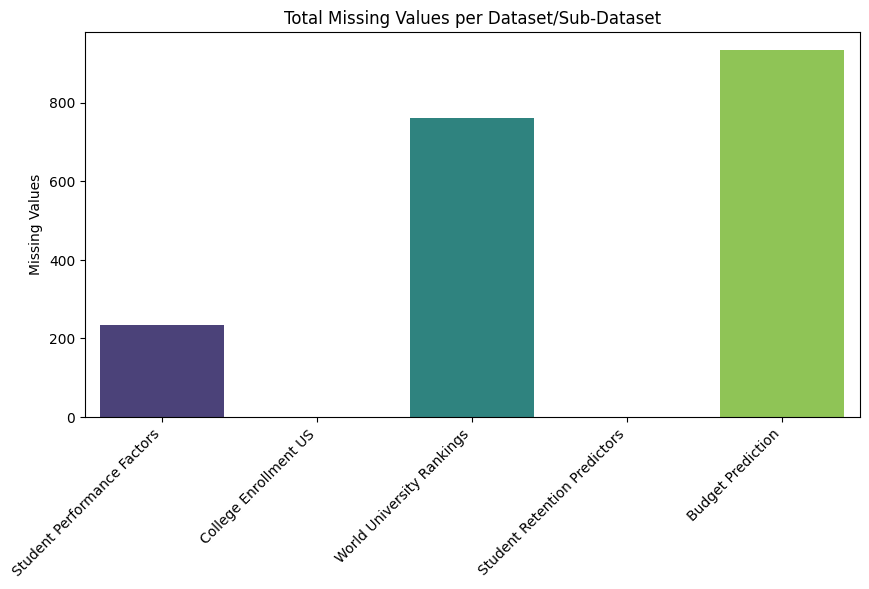

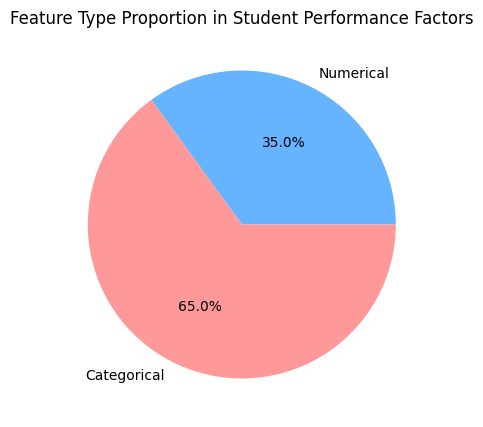

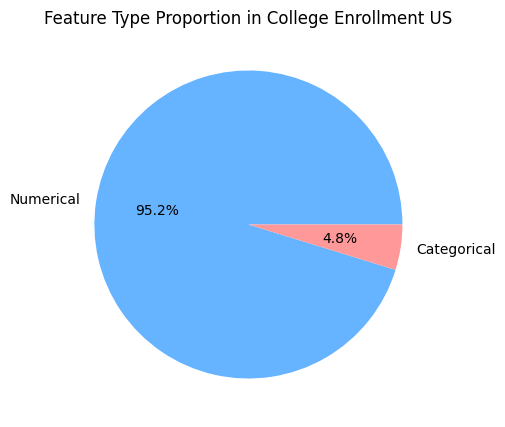

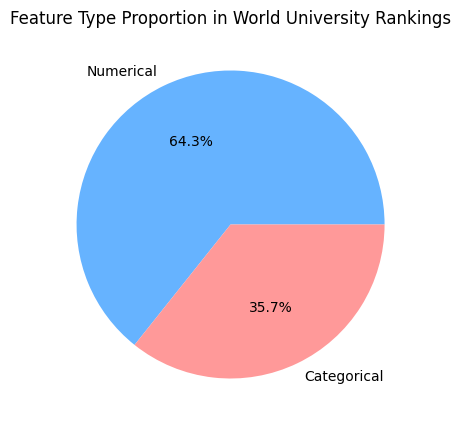

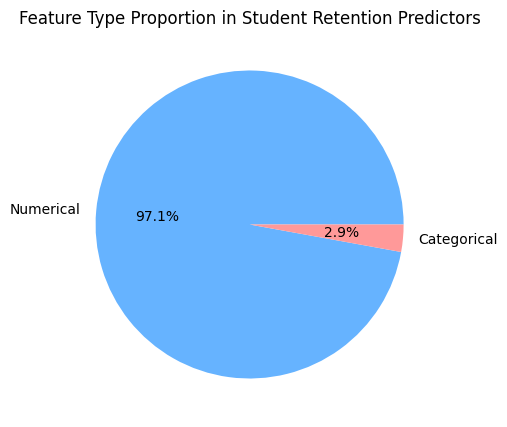

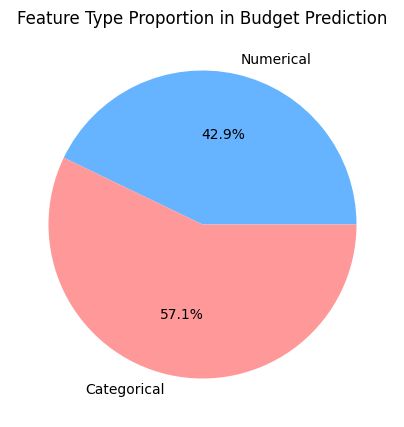

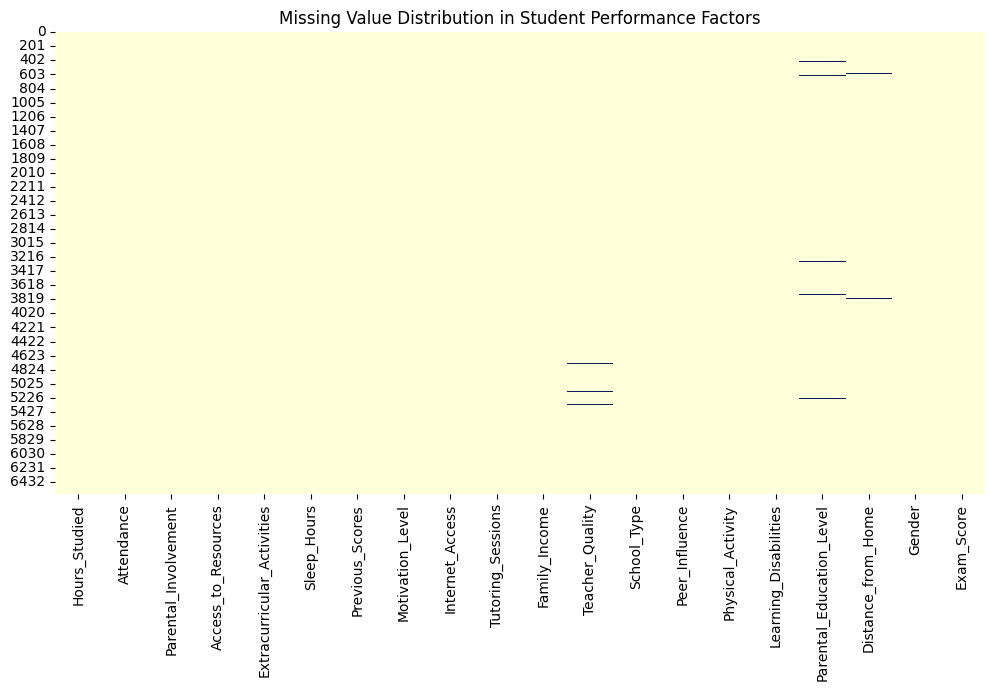

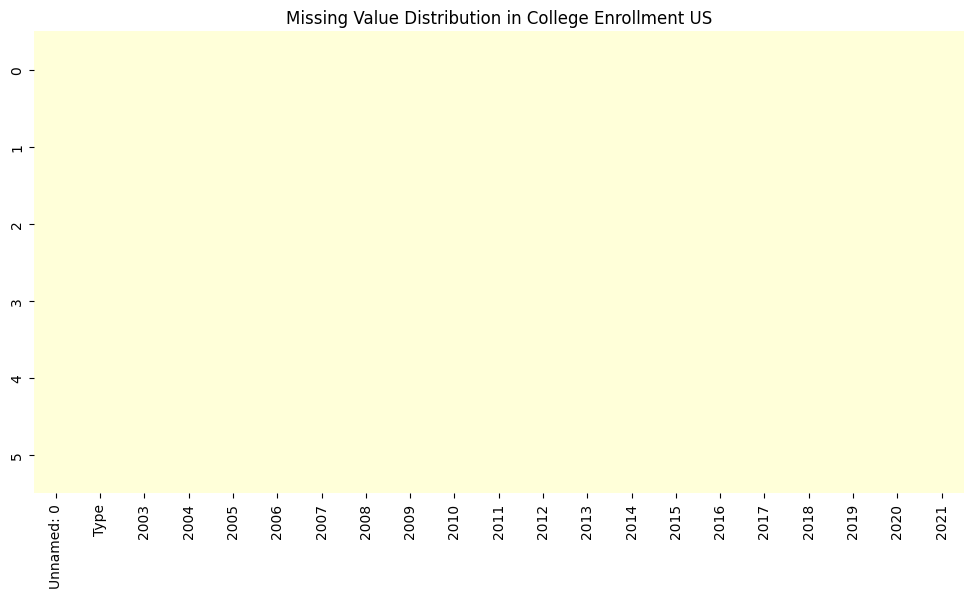

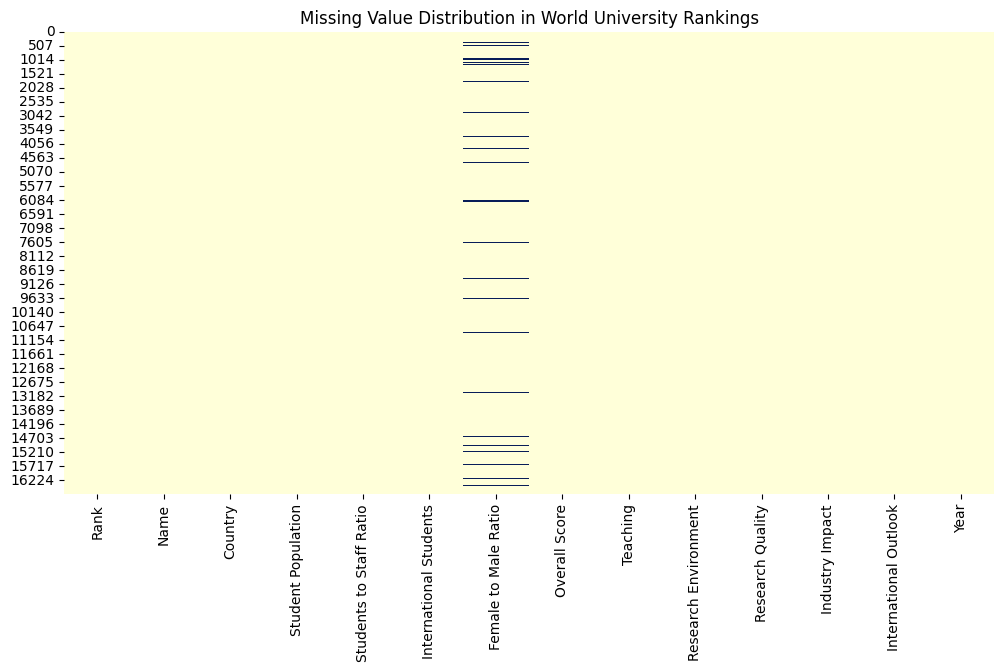

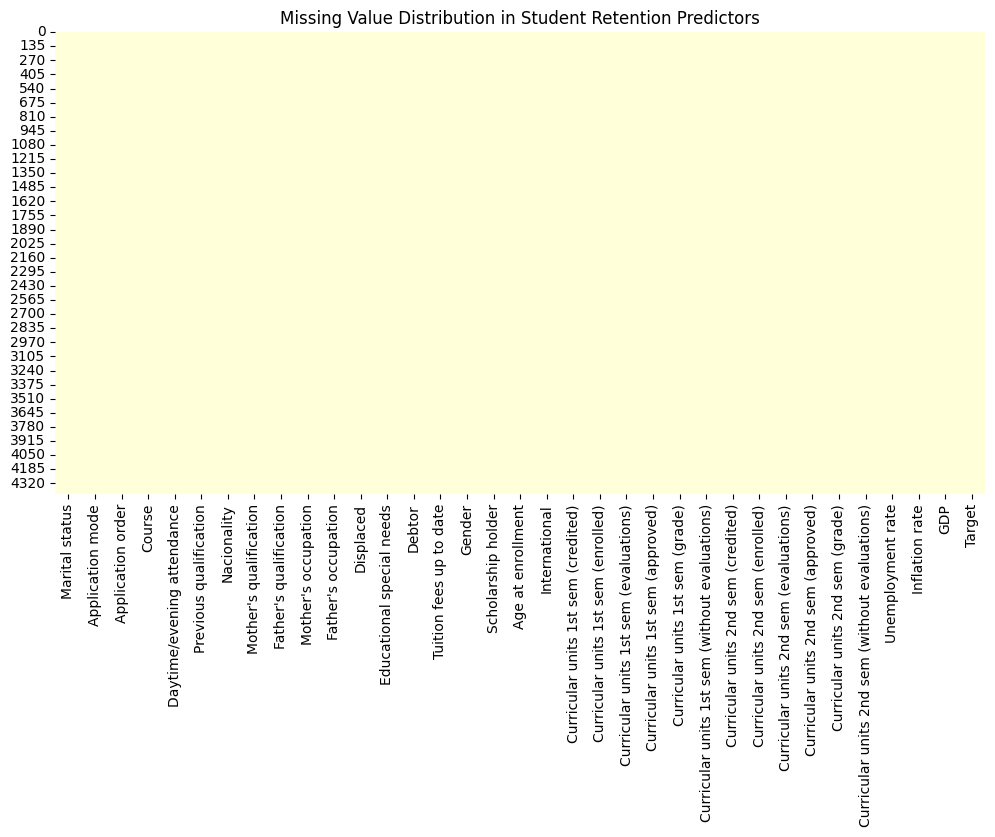

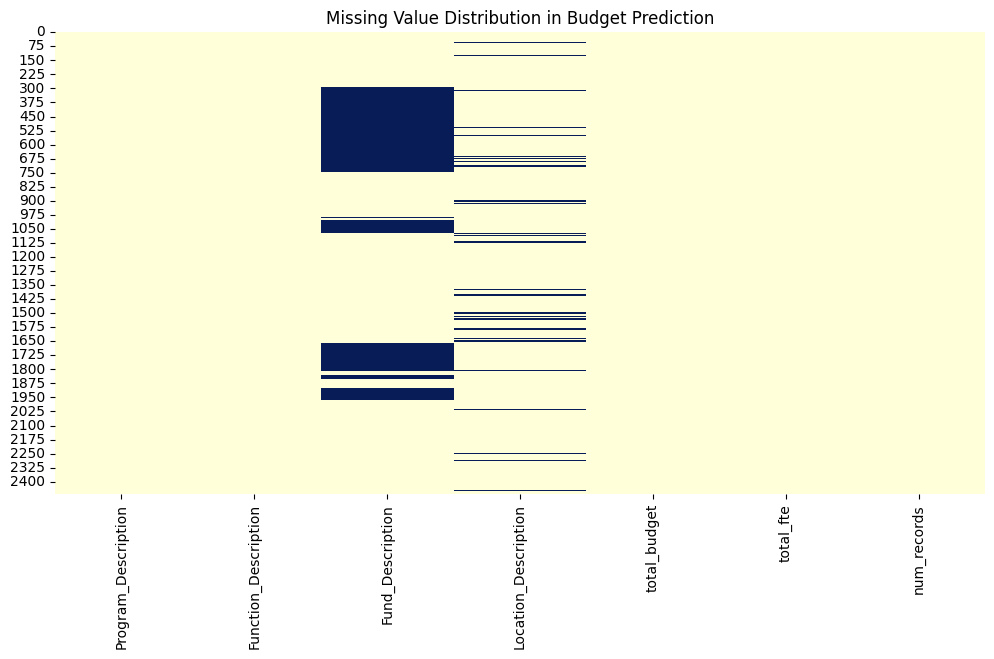

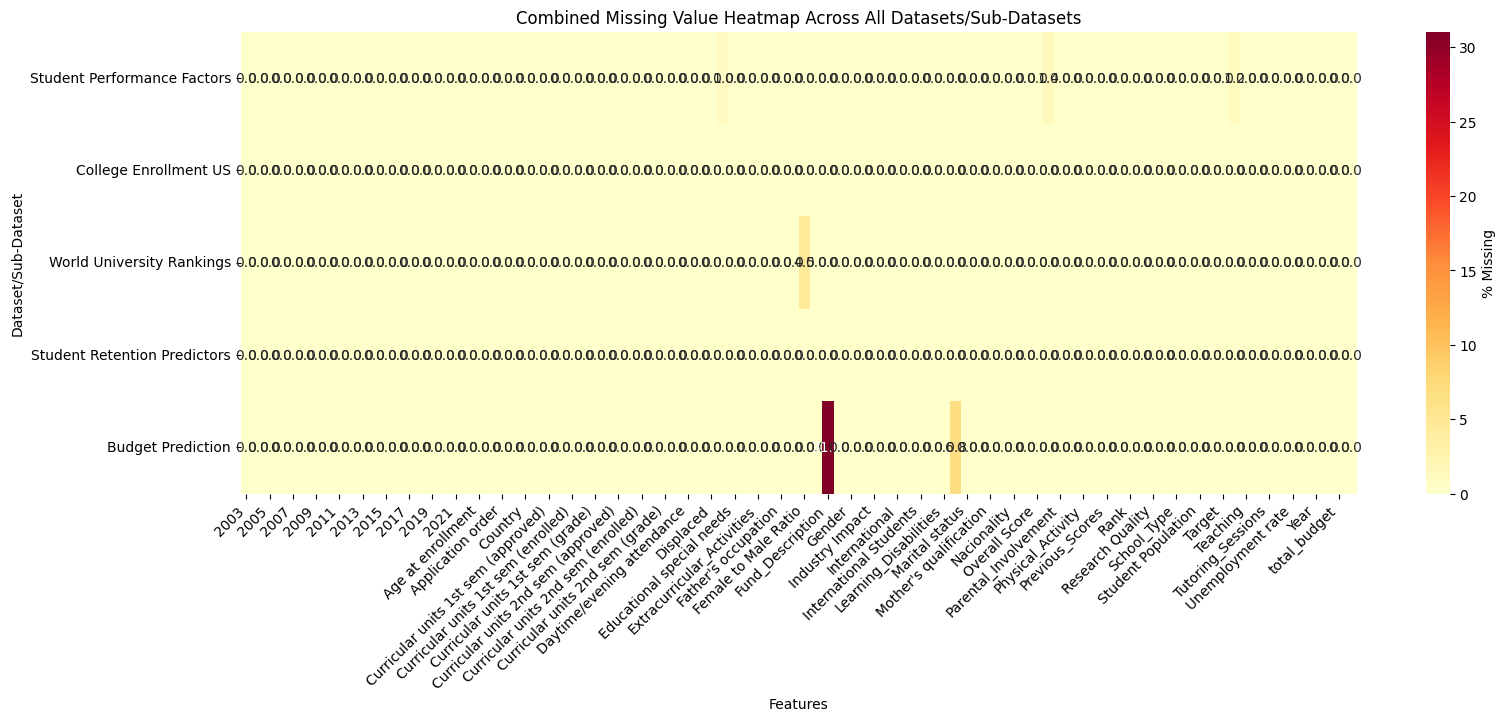

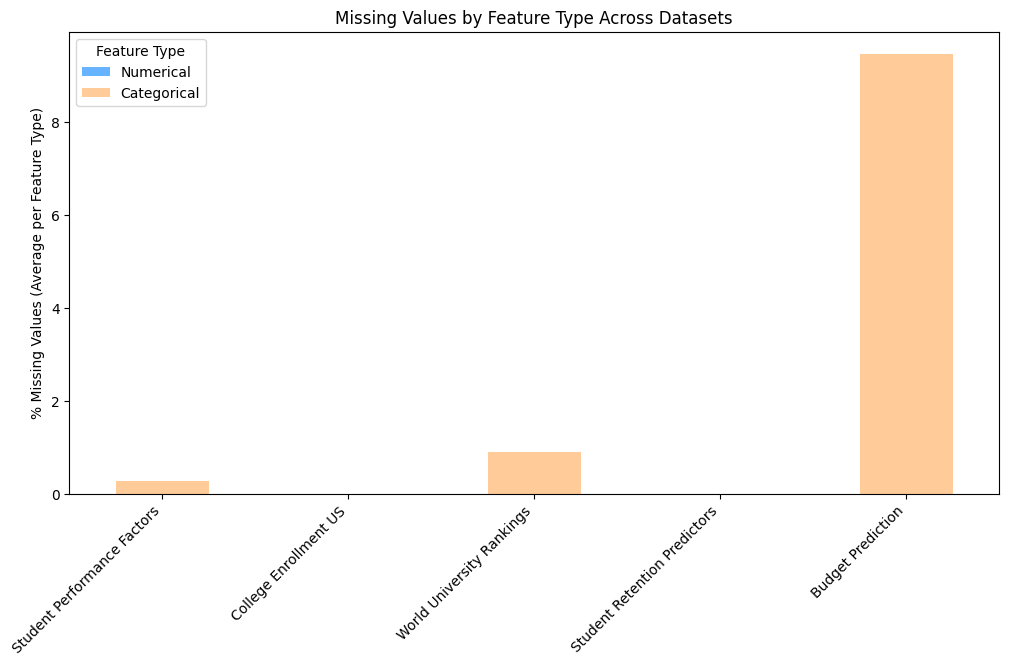

In [ ]:
# ====================== IMPORTS ======================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# ====================== DATASET PATHS ======================
datasets = {
    "Student Performance Factors": "/content/student_performance/StudentPerformanceFactors.csv",
    "College Enrollment US": "/content/college_enrollment/enrollment.csv",
    "World University Rankings": "/content/university_rankings/THE World University Rankings 2016-2026.csv",
    "Student Retention Predictors": "/content/retention/dataset.csv",
    # DrivenData BoxPlots - train & test
    "Budget Prediction": "/content/budgetDataset.csv",
    #"BoxPlots Education - Test": "/content/education/TestData.csv"
}

# ====================== LOAD DATASETS ======================
dfs = {}
for name, file in datasets.items():
    if file.endswith(".zip"):
        with zipfile.ZipFile(file) as z:
            z.extractall()
            extracted_file = z.namelist()[0]
            dfs[name] = pd.read_csv(extracted_file)
    else:
        dfs[name] = pd.read_csv(file)

# ====================== COMBINE BOXPLOTS TRAIN & TEST ======================
# boxplots_train = dfs.pop("BoxPlots Education - Train")
# boxplots_test = dfs.pop("BoxPlots Education - Test")

# # Add source column to keep track
# boxplots_train["Source"] = "Train"
# boxplots_test["Source"] = "Test"

# # Concatenate
# boxplots_combined = pd.concat([boxplots_train, boxplots_test], ignore_index=True)
# dfs["BoxPlots Education - Combined"] = boxplots_combined

# ====================== TARGET / TASK ======================
targets_tasks = {
    "Student Performance Factors": ("Final Grade", "Regression/Classification"),
    "College Enrollment US": ("Enrollment", "Regression"),
    "World University Rankings": ("Rank", "Regression"),
    "Student Retention Predictors": ("Retention", "Classification"),
    "Budget Prediction": ("Total Budget", "Regression")
}

# ====================== BOXPLOTS COLUMN CATEGORIZATION ======================
# boxplots_num_cols = ['FTE', 'Total']
# boxplots_text_cols = [
#     'Facility_or_Department', 'Function_Description', 'Fund_Description',
#     'Job_Title_Description', 'Location_Description', 'Object_Description',
#     'Position_Extra', 'Program_Description', 'SubFund_Description',
#     'Sub_Object_Description', 'Text_1', 'Text_2', 'Text_3', 'Text_4'
# ]
# def get_boxplots_label_cols(df):
#     possible_labels = [
#         'Function', 'Object_Type', 'Operating_Status', 'Position_Type',
#         'Pre_K', 'Reporting', 'Sharing', 'Student_Type', 'Use'
#     ]
#     return [col for col in possible_labels if col in df.columns]

# ====================== SUMMARY TABLE ======================
summary = []

for name, df in dfs.items():
    if "BoxPlots Education - Combined" in name:
        num_features = [col for col in boxplots_num_cols if col in df.columns]
        text_features = [col for col in boxplots_text_cols if col in df.columns]
        label_features = get_boxplots_label_cols(df)
        n_num, n_text, n_label = len(num_features), len(text_features), len(label_features)
        total_missing_pct = round(df.isnull().mean().sum() * 100 / len(df.columns), 2)
    else:
        num_features = df.select_dtypes(include=['number']).columns.tolist()
        cat_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
        text_features, label_features = [], []
        n_num, n_text, n_label = len(num_features), 0, 0
        total_missing_pct = round(df.isnull().mean().sum() * 100 / len(df.columns), 2)

    summary.append({
        "Dataset Name": name,
        "Task": targets_tasks[name][1],
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "df.shape": df.shape,
        "Target Variable": targets_tasks[name][0],
        "% Missing Values": total_missing_pct,
        "# Numerical Features": n_num,
        "# Text Features": n_text,
        "# Label Features": n_label,
        "Numerical Columns": num_features,
        "Text Columns": text_features,
        "Label Columns": label_features,
        "Missing Values per Column": df.isnull().sum().to_dict()
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

# ====================== BAR CHART: TOTAL MISSING VALUES ======================
missing_totals = [df.isnull().sum().sum() for df in dfs.values()]
plt.figure(figsize=(10,5))
sns.barplot(x=list(dfs.keys()), y=missing_totals, palette="viridis")
plt.title("Total Missing Values per Dataset/Sub-Dataset")
plt.ylabel("Missing Values")
plt.xticks(rotation=45, ha="right")
plt.show()

# ====================== PIE CHART: FEATURE TYPE PROPORTION ======================
for name, df in dfs.items():
    if "BoxPlots Education - Combined" in name:
        num_count = len([col for col in boxplots_num_cols if col in df.columns])
        text_count = len([col for col in boxplots_text_cols if col in df.columns])
        label_count = len(get_boxplots_label_cols(df))
        sizes = [num_count, text_count, label_count]
        labels = ['Numerical', 'Text', 'Label']
        colors = ['#66b3ff','#ffcc99','#99ff99']
    else:
        num_count = len(df.select_dtypes(include=['number']).columns)
        cat_count = len(df.select_dtypes(include=['object', 'category']).columns)
        sizes = [num_count, cat_count]
        labels = ['Numerical', 'Categorical']
        colors = ['#66b3ff','#ff9999']

    plt.figure(figsize=(5,5))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
    plt.title(f'Feature Type Proportion in {name}')
    plt.show()

# ====================== HEATMAP: MISSING VALUE DISTRIBUTION PER DATASET ======================
for name, df in dfs.items():
    plt.figure(figsize=(12,6))
    sns.heatmap(df.isnull(), cbar=False, cmap="YlGnBu")
    plt.title(f'Missing Value Distribution in {name}')
    plt.show()

# ====================== COMBINED MISSING VALUE HEATMAP ======================
combined_missing = {}
for name, df in dfs.items():
    combined_missing[name] = df.isnull().mean() * 100

combined_missing_df = pd.DataFrame(combined_missing).T.fillna(0)
plt.figure(figsize=(18,6))
sns.heatmap(combined_missing_df, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={'label': '% Missing'})
plt.title("Combined Missing Value Heatmap Across All Datasets/Sub-Datasets")
plt.ylabel("Dataset/Sub-Dataset")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.show()

# ====================== STACKED BAR CHART: MISSING BY FEATURE TYPE ======================
missing_summary = {}

for name, df in dfs.items():
    if "BoxPlots Education - Combined" in name:
        num_features = [col for col in boxplots_num_cols if col in df.columns]
        text_features = [col for col in boxplots_text_cols if col in df.columns]
        label_features = get_boxplots_label_cols(df)

        missing_summary[name] = {
            "Numerical": df[num_features].isnull().mean().mean() * 100 if num_features else 0,
            "Text": df[text_features].isnull().mean().mean() * 100 if text_features else 0,
            "Label": df[label_features].isnull().mean().mean() * 100 if label_features else 0
        }
    else:
        num_features = df.select_dtypes(include=['number']).columns.tolist()
        cat_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

        missing_summary[name] = {
            "Numerical": df[num_features].isnull().mean().mean() * 100 if num_features else 0,
            "Categorical": df[cat_features].isnull().mean().mean() * 100 if cat_features else 0
        }

missing_summary_df = pd.DataFrame(missing_summary).T.fillna(0)

# Plot stacked bar
missing_summary_df.plot(kind='bar', stacked=True, figsize=(12,6),
                        color=['#66b3ff','#ffcc99','#99ff99'])
plt.ylabel('% Missing Values (Average per Feature Type)')
plt.title('Missing Values by Feature Type Across Datasets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Feature Type')
plt.show()
